In [ ]:
# Cell 47: Generalized Dimensions D0, D1, D2 for every InSAR pixel
#
# Run the full 1D WTMM pipeline on every pixel (masked by velocity),
# compute generalized dimensions D0/D1/D2, and produce 3 spatial maps.
#
# Parameters: n_oct=2, n_voice=10, a_min=1.0, wavelet='g2', expo=-1.0
# q_list=[0,1,2], regression range: log2_a 0.0 to 1.9

import time as time_mod

# ── Step 1: Velocity map and mask ──────────────────────────────────────────────
print("Step 1: Computing velocity map...")

n_dates, ny, nx = cum_data.shape

# Vectorized linear regression: vel = slope of cum_data vs days
# cum_data shape: (197, 1052, 475), days shape: (197,)
days_centered = days - days.mean()
days_var = np.sum(days_centered**2)

# Reshape for broadcasting: (197,1,1) * (197,ny,nx) -> sum over axis 0
cum_flat = cum_data.reshape(n_dates, -1)  # (197, ny*nx)

# Handle NaN: use nanmean/nansum
cum_mean = np.nanmean(cum_flat, axis=0, keepdims=True)  # (1, ny*nx)
cum_centered = cum_flat - cum_mean  # (197, ny*nx)

# Mask out NaN positions for proper regression
valid_mask_flat = ~np.isnan(cum_flat)  # (197, ny*nx)

# For each pixel: vel = sum(days_centered * cum_centered) / sum(days_centered^2)
# but only over non-NaN times
days_c_2d = days_centered[:, np.newaxis]  # (197,1)
numerator = np.nansum(days_c_2d * cum_centered, axis=0)  # (ny*nx,)
denominator = np.sum(valid_mask_flat * (days_c_2d**2), axis=0)  # (ny*nx,)
denominator[denominator == 0] = np.nan

vel_flat = numerator / denominator * 365.25  # mm/yr
vel_map = vel_flat.reshape(ny, nx)

# Count valid time steps per pixel
n_valid = valid_mask_flat.sum(axis=0).reshape(ny, nx)

# Mask: |vel| > threshold AND enough valid data (at least 50% of dates)
vel_threshold = 5.0  # mm/yr
min_valid_dates = n_dates // 2
pixel_mask = (np.abs(vel_map) > vel_threshold) & (n_valid >= min_valid_dates)
n_pixels = pixel_mask.sum()

print(f"  Velocity range: [{np.nanmin(vel_map):.1f}, {np.nanmax(vel_map):.1f}] mm/yr")
print(f"  Threshold: |vel| > {vel_threshold} mm/yr, min dates: {min_valid_dates}")
print(f"  Masked pixels: {n_pixels} / {ny*nx} ({100*n_pixels/(ny*nx):.1f}%)")

# Show velocity map
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(vel_map, cmap='RdBu_r', vmin=-50, vmax=50, aspect='auto')
ax.set_title(f'LOS Velocity (mm/yr) — {n_pixels} pixels above threshold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax, label='mm/yr')
# Mark pixA and pixB
ax.plot(362, 1031, 'k^', ms=10, label='Pixel A (1031,362)')
ax.plot(291, 224, 'ks', ms=10, label='Pixel B (224,291)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# ── Step 2: WTMM pipeline on every masked pixel ───────────────────────────────
print("\nStep 2: Running WTMM pipeline on masked pixels...")

n_oct_m = 2
n_voice_m = 10
a_min_m = 1.0
wavelet_m = 'g2'
expo_m = -1.0
q_list_m = [0, 1, 2]
log2_a_min_m = 0.0
log2_a_max_m = 1.9

# Output arrays (NaN = no data)
D0_map = np.full((ny, nx), np.nan)
D1_map = np.full((ny, nx), np.nan)
D2_map = np.full((ny, nx), np.nan)

ys, xs = np.where(pixel_mask)
t_start = time_mod.time()
n_fail = 0

for idx in range(len(ys)):
    y, x = ys[idx], xs[idx]
    
    if idx > 0 and idx % 500 == 0:
        elapsed = time_mod.time() - t_start
        rate = idx / elapsed
        eta = (len(ys) - idx) / rate
        print(f"  {idx}/{len(ys)} pixels ({100*idx/len(ys):.0f}%), "
              f"{elapsed:.0f}s elapsed, ~{eta:.0f}s remaining, {n_fail} failed")
    
    try:
        # Extract time series and interpolate to uniform grid
        raw_ts = cum_data[:, y, x].astype(np.float64)
        valid = ~np.isnan(raw_ts)
        if valid.sum() < min_valid_dates:
            continue
        
        sig = np.interp(t_uniform, days[valid], raw_ts[valid]).astype(np.float64)
        
        # 1. CWT
        coeffs_m, scales_m, vr_m = cwtd(sig, a_min=a_min_m, n_oct=n_oct_m,
                                          n_voice=n_voice_m, wavelet_name=wavelet_m,
                                          expo=expo_m, border='mirror')
        
        # 2. Extrema detection
        ea_m, eo_m, ei_m = compute_extrep(coeffs_m, scales_m, n_oct=n_oct_m,
                                            n_voice=n_voice_m, a_min=a_min_m,
                                            valid_ranges=vr_m)
        
        # 3. Chain linking
        cl_m, fl_m = chain_all(ea_m, eo_m, n_oct=n_oct_m, n_voice=n_voice_m)
        
        # 4. Prune
        chain_delete_all(ea_m, eo_m, ei_m, cl_m, fl_m,
                         n_oct=n_oct_m, n_voice=n_voice_m)
        
        # 5. Chain max
        chain_max_wrapper(eo_m, cl_m, n_oct=n_oct_m, n_voice=n_voice_m,
                          a_min=a_min_m, expo=1.0)
        
        # 6. Partition function
        pf_m = compute_partition_function(eo_m, n_oct=n_oct_m, n_voice=n_voice_m,
                                           a_min=a_min_m, q_list=q_list_m)
        
        # 7. Spectra → D0, D1, D2
        sp_m = compute_spectra(pf_m, log2_a_min=log2_a_min_m,
                               log2_a_max=log2_a_max_m)
        
        iq0 = np.argmin(np.abs(np.array(sp_m['q_list']) - 0))
        iq1 = np.argmin(np.abs(np.array(sp_m['q_list']) - 1))
        iq2 = np.argmin(np.abs(np.array(sp_m['q_list']) - 2))
        
        D0_map[y, x] = sp_m['D_q'][iq0]
        D1_map[y, x] = sp_m['D_q'][iq1]
        D2_map[y, x] = sp_m['D_q'][iq2]
    
    except Exception:
        n_fail += 1
        continue

elapsed_total = time_mod.time() - t_start
print(f"\nDone: {len(ys)} pixels in {elapsed_total:.0f}s "
      f"({elapsed_total/max(len(ys),1)*1000:.1f} ms/pixel), {n_fail} failed")

# Print pixA/pixB values for verification
print(f"\nPixel A (1031,362): D0={D0_map[1031,362]:.3f}, "
      f"D1={D1_map[1031,362]:.3f}, D2={D2_map[1031,362]:.3f}")
print(f"Pixel B (224,291):  D0={D0_map[224,291]:.3f}, "
      f"D1={D1_map[224,291]:.3f}, D2={D2_map[224,291]:.3f}")

# ── Step 3: Spatial maps of D0, D1, D2 ────────────────────────────────────────
print("\nStep 3: Plotting spatial maps...")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['$D_0$ (Capacity)', '$D_1$ (Information)', '$D_2$ (Correlation)']
data = [D0_map, D1_map, D2_map]

for ax, d, title in zip(axes, data, titles):
    valid_vals = d[~np.isnan(d)]
    if len(valid_vals) > 0:
        vlo, vhi = np.percentile(valid_vals, [2, 98])
    else:
        vlo, vhi = 0, 1
    im = ax.imshow(d, cmap='viridis', vmin=vlo, vmax=vhi, aspect='auto')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.colorbar(im, ax=ax)
    # Mark pixA and pixB
    ax.plot(362, 1031, 'r^', ms=8, label='Pix A')
    ax.plot(291, 224, 'rs', ms=8, label='Pix B')
    ax.legend(loc='upper right', fontsize=7)

plt.suptitle('Generalized Dimensions from 1D WTMM — InSAR pixels', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
for name, d in zip(['D0', 'D1', 'D2'], data):
    v = d[~np.isnan(d)]
    if len(v) > 0:
        print(f"  {name}: mean={v.mean():.3f}, std={v.std():.3f}, "
              f"range=[{v.min():.3f}, {v.max():.3f}]")


In [ ]:
# [CELL 0]
# LastWave-style plotting utilities — imported from wtmm package

import numpy as np
import matplotlib.pyplot as plt
from wtmm.colormaps import lastwave_colormap, lastwave_grey_colormap, lastwave_b2r_colormap, scalogram_lastwave

# Register colormaps globally so they can be used by name
_lw_cmap = lastwave_colormap(256)
_lw_grey = lastwave_grey_colormap(256)
_lw_b2r = lastwave_b2r_colormap(256)
try:
    plt.colormaps.register(_lw_cmap)
    plt.colormaps.register(_lw_grey)
    plt.colormaps.register(_lw_b2r)
except ValueError:
    pass  # already registered

print("LastWave plotting utilities loaded:")
print("  Colormaps:  'lastwave', 'lastwave_grey', 'lastwave_b2r'")
print("  Functions:  scalogram_lastwave(cwt_matrix, scales, ...)")
print(f"              norm_mode='lglobal' (default) | 'global' | 'signedglobal'")
print(f"  Helpers:    lastwave_colormap(n), lastwave_grey_colormap(n), lastwave_b2r_colormap(n)")

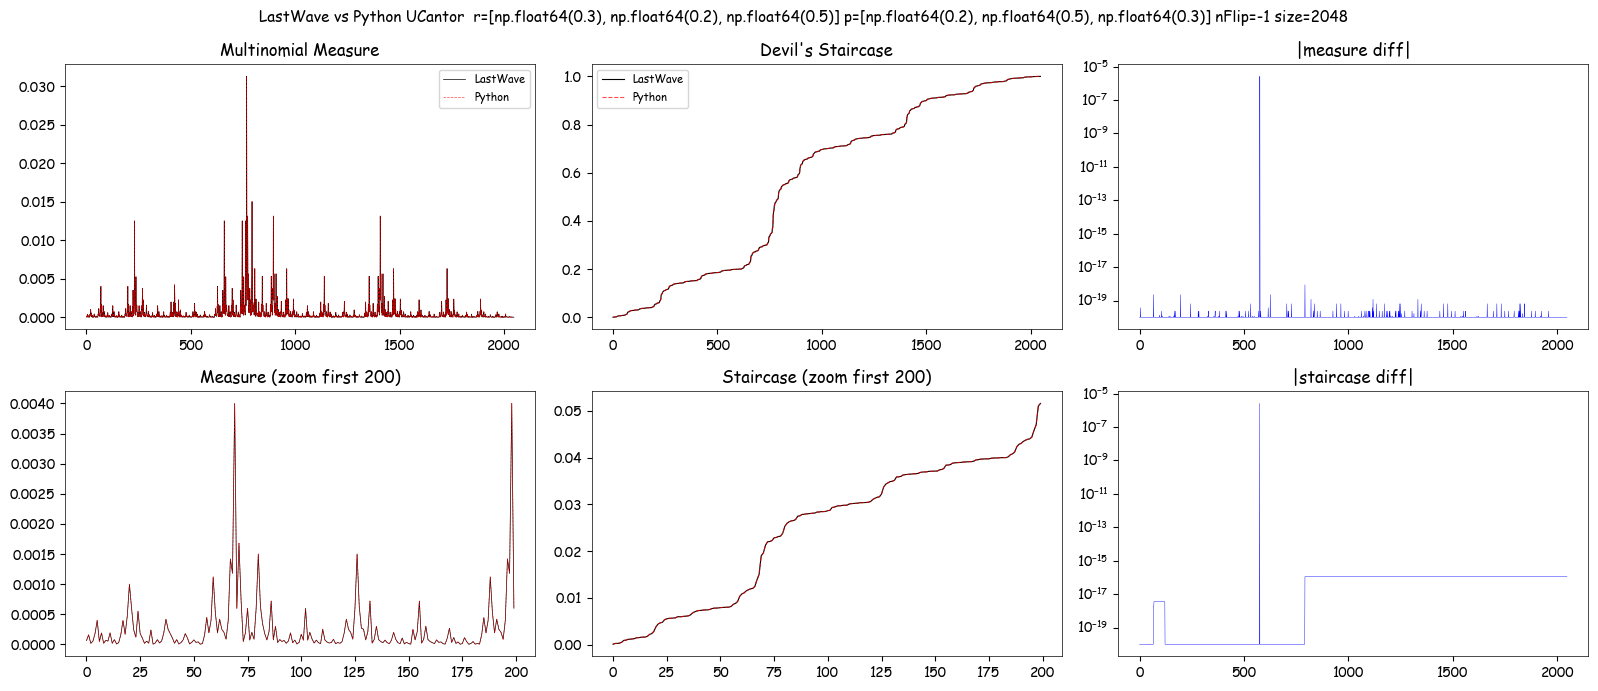

Max |measure diff|:   2.59e-06
Max |staircase diff|: 2.59e-06
Staircase range LW:   [0.000064, 1.000000]
Staircase range Py:   [0.000064, 1.000000]


In [ ]:
# [CELL 1] LastWave ground truth — Step 1: Inhomogeneous devil's staircase (LastWave vs Python)
import ctypes, ctypes.util, numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Force reload the dylib (kernel may cache old version)
_lw_path = './liblastwave_wrapper.dylib'
try:
    ctypes.cdll.LoadLibrary(_lw_path)
except:
    pass
lib = ctypes.CDLL(_lw_path)

lib.lw_init.restype = ctypes.c_int
lib.lw_ucantor.restype = ctypes.c_int
lib.lw_ucantor.argtypes = [ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.POINTER(ctypes.c_double),
                            ctypes.c_int, ctypes.c_int,
                            ctypes.POINTER(ctypes.c_double)]
lib.lw_cleanup.restype = None
lib.lw_get_error.restype = ctypes.c_char_p
lib.lw_eval_wavelet.restype = ctypes.c_int
lib.lw_get_wavelet_domain.restype = ctypes.c_int

c_double_p = ctypes.POINTER(ctypes.c_double)

ret = lib.lw_init()
assert ret == 0, f"lw_init failed: {lib.lw_get_error()}"

# ── DemoWTMM1DDevilStair parameters ──
SIZE = 2048
r = np.array([0.3, 0.2, 0.5], dtype=np.float64)
p = np.array([0.2, 0.5, 0.3], dtype=np.float64)
nFlip = -1  # no flip (matches C_UCantor doing nFlip-- from 0)

# ── LastWave UCantor ──
lw_measure = np.zeros(SIZE, dtype=np.float64)
ret = lib.lw_ucantor(SIZE, r.ctypes.data_as(c_double_p),
                      p.ctypes.data_as(c_double_p), 3, nFlip,
                      lw_measure.ctypes.data_as(c_double_p))
assert ret == 0, f"lw_ucantor failed: {lib.lw_get_error()}"
lw_staircase = np.cumsum(lw_measure)

# ── Python UCantor (matches LastWave's C arithmetic exactly) ──
def ucantor(size, r, p, nFlip=-1):
    dx = 1.0 / size
    signal = np.zeros(size)
    r = list(r)
    p = list(p)
    n = len(r)
    # Iterative DFS matching C's recursive UCantor exactly:
    #   l accumulates across siblings: l += (right-left)*r[i]
    #   ISig: (int)(left / dx)    (since x0=0)
    #   termination: fabs(right-left) <= dx
    stack = [(0.0, 1.0, 1.0)]  # (left, right, proba)
    while stack:
        left, right, proba = stack.pop()
        if abs(right - left) <= dx:
            i = int(left / dx)
            if i < 0: i = 0
            elif i >= size: i = size - 1
            signal[i] += proba
            continue
        # Accumulate l across siblings, matching C
        span = right - left
        l = left
        for i in range(n):
            child_proba = proba * p[i]
            if i == nFlip:
                stack.append((l + span * r[i], l, child_proba))
            else:
                stack.append((l, l + span * r[i], child_proba))
            l += span * r[i]
    return signal

py_measure = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)
py_staircase = np.cumsum(py_measure)

# ── Compare ──
measure_diff = np.abs(lw_measure - py_measure)
stair_diff = np.abs(lw_staircase - py_staircase)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

axes[0, 0].plot(lw_measure, 'k-', lw=0.5, label='LastWave')
axes[0, 0].plot(py_measure, 'r--', lw=0.5, alpha=0.7, label='Python')
axes[0, 0].set_title('Multinomial Measure')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(lw_staircase, 'k-', lw=0.8, label='LastWave')
axes[0, 1].plot(py_staircase, 'r--', lw=0.8, alpha=0.7, label='Python')
axes[0, 1].set_title("Devil's Staircase")
axes[0, 1].legend(fontsize=8)

axes[0, 2].semilogy(measure_diff + 1e-20, 'b-', lw=0.3)
axes[0, 2].set_title('|measure diff|')

axes[1, 0].plot(lw_measure[:200], 'k-', lw=0.5)
axes[1, 0].plot(py_measure[:200], 'r--', lw=0.5, alpha=0.7)
axes[1, 0].set_title('Measure (zoom first 200)')

axes[1, 1].plot(lw_staircase[:200], 'k-', lw=0.8)
axes[1, 1].plot(py_staircase[:200], 'r--', lw=0.8, alpha=0.7)
axes[1, 1].set_title('Staircase (zoom first 200)')

axes[1, 2].semilogy(stair_diff + 1e-20, 'b-', lw=0.3)
axes[1, 2].set_title('|staircase diff|')

plt.suptitle(f'LastWave vs Python UCantor  r={list(r)} p={list(p)} nFlip={nFlip} size={SIZE}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Max |measure diff|:   {measure_diff.max():.2e}')
print(f'Max |staircase diff|: {stair_diff.max():.2e}')
print(f'Staircase range LW:   [{lw_staircase.min():.6f}, {lw_staircase.max():.6f}]')
print(f'Staircase range Py:   [{py_staircase.min():.6f}, {py_staircase.max():.6f}]')

Start octave 1.........
Start octave 2.........
Start octave 3.........
Start octave 4.........
Start octave 5.........


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_32774/595811681.py:82: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()


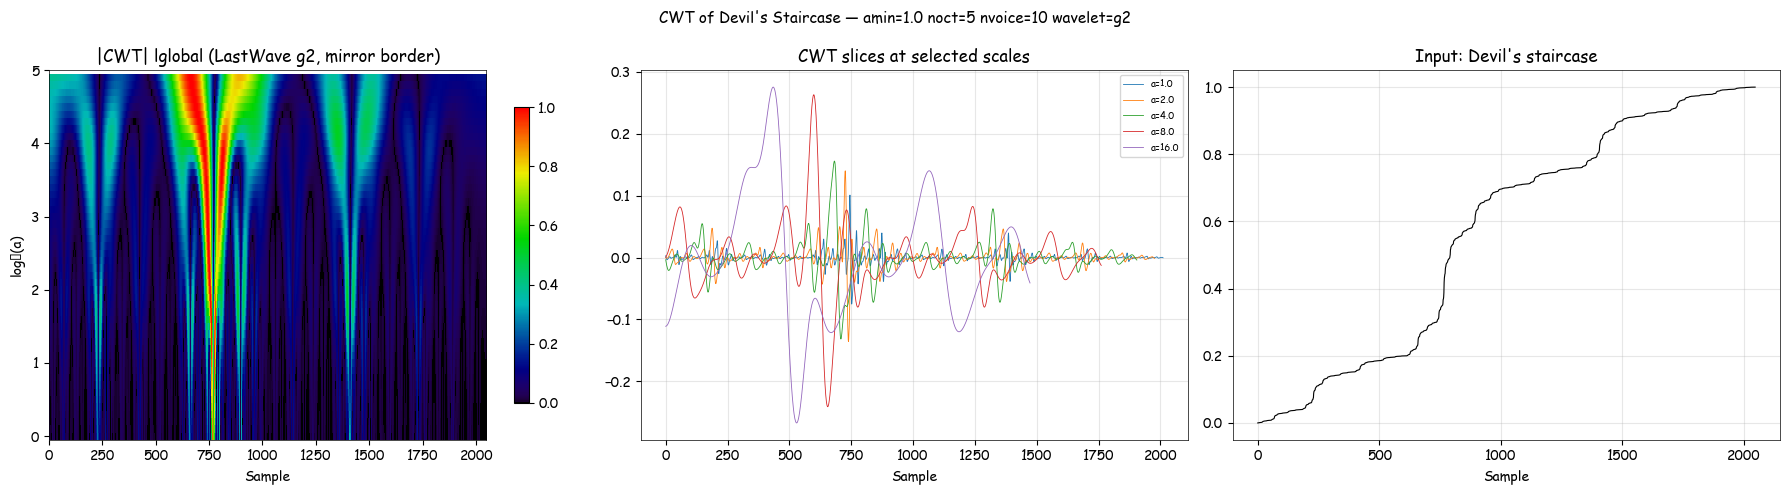

Scales: 50 total, range [1.00, 29.86]
  scale  0 (a=   1.00): valid range [18, 2029]
  scale 10 (a=   2.00): valid range [35, 2012]
  scale 20 (a=   4.00): valid range [71, 1976]
  scale 30 (a=   8.00): valid range [143, 1904]
  scale 40 (a=  16.00): valid range [287, 1760]


In [ ]:
# [CELL 2]
# LastWave ground truth — Step 2: CWT of inhomogeneous Cantor measure via LastWave
#
# DemoWTMM1DDevilStair params: amin=1.0, omax=5, nvoice=10, wavelet='g2', border='mir'
# The input is the devil's staircase (integrated measure) from cell 0.

# ── CWT setup ──
lib.lw_cwtd.restype = ctypes.c_int
lib.lw_cwtd.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # signal_in
    ctypes.c_int,                      # size
    ctypes.c_double,                   # a_min
    ctypes.c_int,                      # n_oct
    ctypes.c_int,                      # n_voice
    ctypes.c_char_p,                   # wavelet_name
    ctypes.c_double,                   # expo
    ctypes.c_int,                      # border_type
    ctypes.POINTER(ctypes.c_double),   # coeffs_out
    ctypes.POINTER(ctypes.c_int),      # firstp_out
    ctypes.POINTER(ctypes.c_int),      # lastp_out
]

a_min   = 1.0
n_oct   = 5
n_voice = 10
wavelet = b'g2'
expo    = -1.0
border  = 1       # CV_MIRROR (enum: CV_PERIODIC=0, CV_MIRROR=1, CV_PADDING=2, CV_0_PADDING=3)

n_scales = n_oct * n_voice
coeffs  = np.zeros(n_scales * SIZE, dtype=np.float64)
firstp  = np.zeros(n_scales, dtype=np.int32)
lastp   = np.zeros(n_scales, dtype=np.int32)

# CWT of the devil's staircase (= cumsum of measure), matching the demo's "0w = prim(0w)"
ret = lib.lw_cwtd(
    lw_staircase.ctypes.data_as(c_double_p), SIZE,
    ctypes.c_double(a_min), n_oct, n_voice,
    wavelet, ctypes.c_double(expo), border,
    coeffs.ctypes.data_as(c_double_p),
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f"lw_cwtd failed: {lib.lw_get_error()}"

cwt = coeffs.reshape(n_scales, SIZE)

# ── Scale axis ──
factor = 2.0 ** (1.0 / n_voice)
scales = a_min * factor ** np.arange(n_scales)
log2_scales = np.log2(scales)

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Scalogram (LastWave lglobal normalization — per-scale-line, no log)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('|CWT| lglobal (LastWave g2, mirror border)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# CWT at a few selected scales
sel = [0, n_voice, 2*n_voice, 3*n_voice, 4*n_voice]
for s in sel:
    fp, lp = firstp[s], lastp[s]
    axes[1].plot(cwt[s, fp:lp+1], lw=0.6, label=f'a={scales[s]:.1f}')
axes[1].set_title('CWT slices at selected scales')
axes[1].set_xlabel('Sample')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Devil's staircase for reference
axes[2].plot(lw_staircase, 'k-', lw=0.8)
axes[2].set_title("Input: Devil's staircase")
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"CWT of Devil's Staircase — amin={a_min} noct={n_oct} nvoice={n_voice} wavelet=g2", fontsize=11)
plt.tight_layout()
plt.show()

# ── Valid range info ──
print(f'Scales: {n_scales} total, range [{scales[0]:.2f}, {scales[-1]:.2f}]')
for s in sel:
    print(f'  scale {s:2d} (a={scales[s]:7.2f}): valid range [{firstp[s]}, {lastp[s]}]')

Total extrema found: 3645
Extracted 3645 extrema across 50 scales


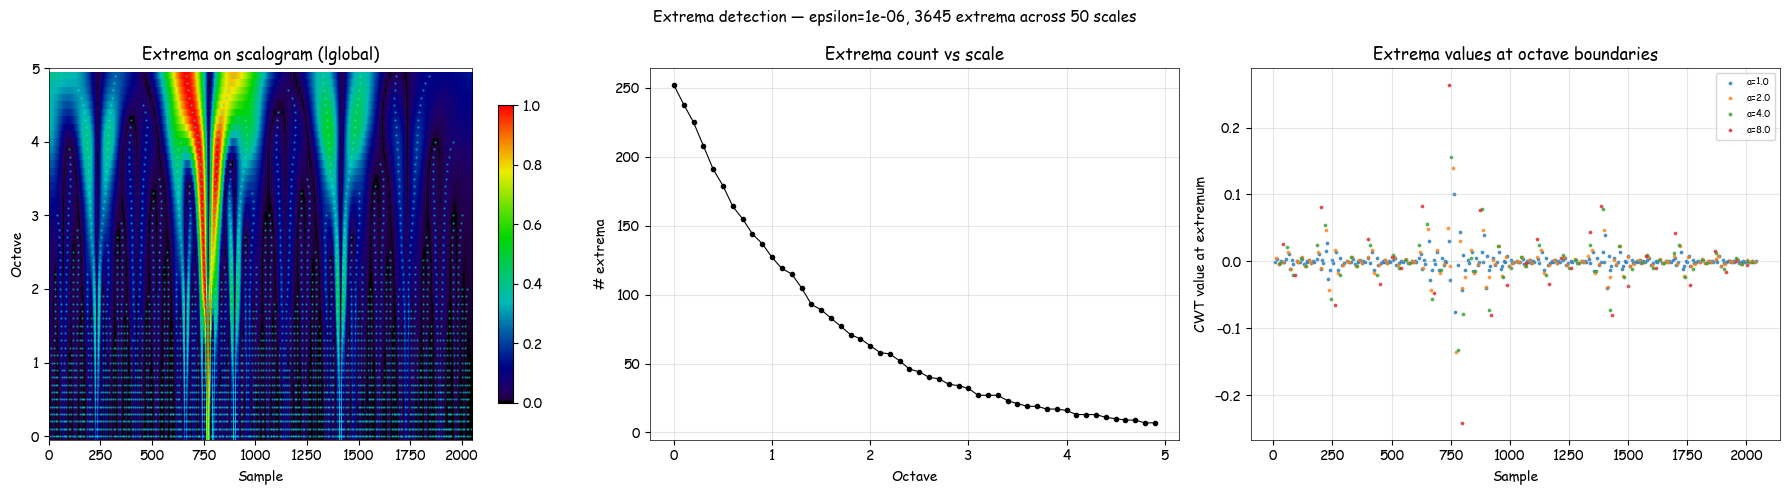


   Scale   Octave  # ext
--------------------------
    1.00    0.000    252
    2.00    1.000    127
    4.00    2.000     63
    8.00    3.000     32
   16.00    4.000     16


In [ ]:
# [CELL 3]
# LastWave ground truth — Step 3: Extrema detection on CWT
#
# DemoWTMM1DDevilStair does:
#   extrema w          (default epsilon=1e-6, interpolated)
#   chainmax w.extrep 1
#
# lw_compute_extrema runs ComputeExtrep on the global wtrans from the previous CWT.
# Then we extract extrema positions & values at each scale for visualization.

# ── Declare function signatures ──
lib.lw_compute_extrema.restype = ctypes.c_int
lib.lw_compute_extrema.argtypes = [ctypes.c_double]

lib.lw_get_extrema_count.restype = ctypes.c_int
lib.lw_get_extrema_count.argtypes = [ctypes.c_int, ctypes.c_int]

lib.lw_get_extrema_at_scale.restype = ctypes.c_int
lib.lw_get_extrema_at_scale.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.c_int,
]

lib.lw_get_n_oct.restype = ctypes.c_int
lib.lw_get_n_voice.restype = ctypes.c_int

# ── Compute extrema ──
epsilon = 1e-6  # LastWave default
nb_ext = lib.lw_compute_extrema(ctypes.c_double(epsilon))
assert nb_ext >= 0, f"lw_compute_extrema failed: {lib.lw_get_error()}"
print(f"Total extrema found: {nb_ext}")

# ── Extract extrema at every scale ──
ext_data = {}  # (octave, voice) -> (positions, values)
total = 0
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count <= 0:
            continue
        pos = np.zeros(count, dtype=np.float64)
        val = np.zeros(count, dtype=np.float64)
        got = lib.lw_get_extrema_at_scale(
            o, v,
            pos.ctypes.data_as(c_double_p),
            val.ctypes.data_as(c_double_p),
            count,
        )
        ext_data[(o, v)] = (pos[:got], val[:got])
        total += got

print(f"Extracted {total} extrema across {len(ext_data)} scales")

# ── Plot: extrema overlaid on scalogram ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel 1: scalogram with extrema scatter (LastWave lglobal)
im = scalogram_lastwave(cwt, scales=scales, ax=axes[0],
                        norm_mode='lglobal')
# Overlay extrema
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    log2_a = log2_scales[scale_idx]
    axes[0].scatter(pos, np.full_like(pos, log2_a), s=0.3, c='cyan', alpha=0.5)
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Octave')
axes[0].set_yticks(range(0, n_oct + 1))
axes[0].set_title('Extrema on scalogram (lglobal)')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Panel 2: extrema count vs scale
ext_counts = np.zeros(n_scales, dtype=int)
for (o, v), (pos, val) in ext_data.items():
    scale_idx = (o - 1) * n_voice + v
    ext_counts[scale_idx] = len(pos)
axes[1].plot(log2_scales, ext_counts, 'k.-', lw=0.8)
axes[1].set_xlabel('Octave')
axes[1].set_ylabel('# extrema')
axes[1].set_title('Extrema count vs scale')
axes[1].grid(True, alpha=0.3)

# Panel 3: extrema at a few selected scales
sel_scales = [(1, 0), (2, 0), (3, 0), (4, 0)]
for (o, v) in sel_scales:
    if (o, v) in ext_data:
        pos, val = ext_data[(o, v)]
        scale_idx = (o - 1) * n_voice + v
        axes[2].scatter(pos, val, s=3, label=f'a={scales[scale_idx]:.1f}', alpha=0.7)
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('CWT value at extremum')
axes[2].set_title('Extrema values at octave boundaries')
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Extrema detection — epsilon={epsilon}, {total} extrema across {n_scales} scales', fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ──
print(f"\n{'Scale':>8} {'Octave':>8} {'# ext':>6}")
print('-' * 26)
for s in range(0, n_scales, n_voice):
    o = s // n_voice + 1
    v = s % n_voice
    c = ext_counts[s]
    print(f'{scales[s]:8.2f} {log2_scales[s]:8.3f} {c:6d}')

ChainDelete removed 0 unchained extrema
Chains remaining: 252
Extracted 252 chains, lengths: min=1, max=50, median=11


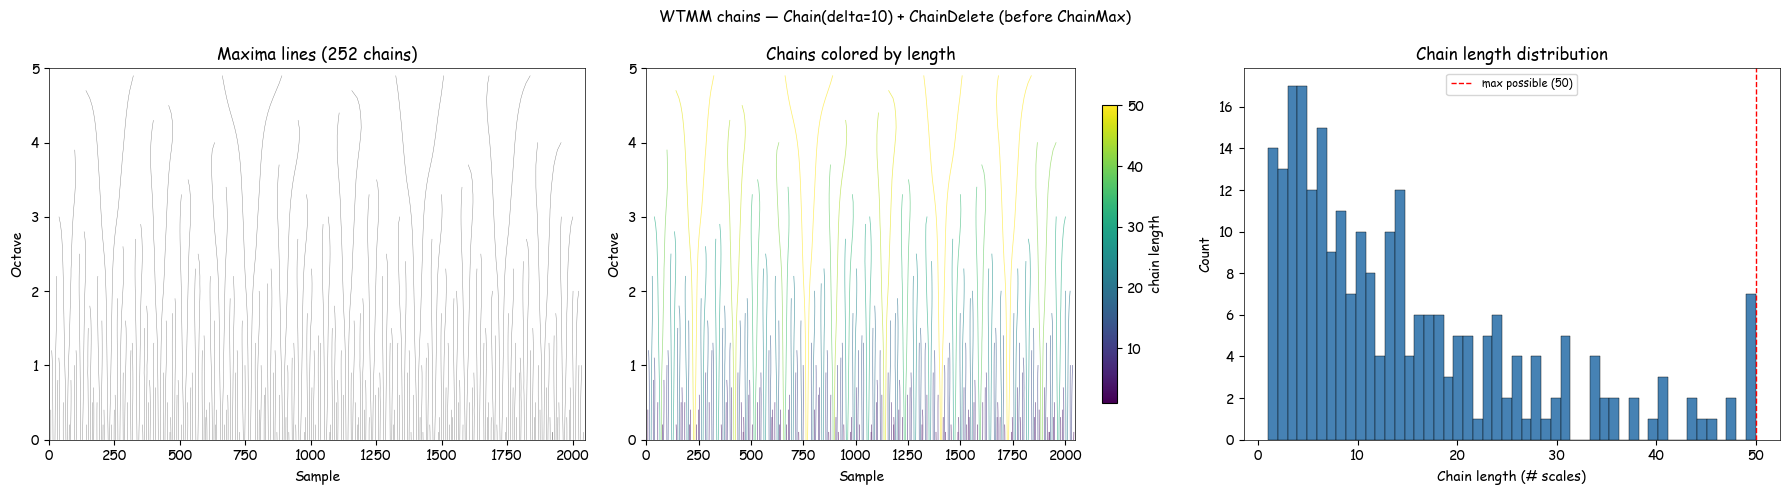

In [ ]:
# [CELL 4]
# LastWave ground truth — Step 3: Chain + ChainDelete + plot maxima lines
#
# Chain() builds linked lists via coarser/finer pointers.
# ChainDelete() prunes extrema not part of any chain.
# ChainMax is deferred to a later cell so we can compare before/after.

# ── Declare signatures ──
lib.lw_chain.restype = ctypes.c_int
lib.lw_chain.argtypes = [ctypes.c_double]

lib.lw_chain_delete.restype = ctypes.c_int
lib.lw_chain_delete.argtypes = []

lib.lw_chain_max.restype = ctypes.c_int
lib.lw_chain_max.argtypes = [ctypes.c_double]

lib.lw_get_num_chains.restype = ctypes.c_int
lib.lw_get_num_chains.argtypes = []

lib.lw_get_chain.restype = ctypes.c_int
lib.lw_get_chain.argtypes = [
    ctypes.c_int,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int), ctypes.c_int,
]

def extract_chains():
    """Extract all chains from the current extrep."""
    nc = lib.lw_get_num_chains()
    max_len = n_scales + 1
    result = []
    for ci in range(nc):
        abs_buf = np.zeros(max_len, dtype=np.float64)
        ord_buf = np.zeros(max_len, dtype=np.float64)
        scl_buf = np.zeros(max_len, dtype=np.int32)
        length = lib.lw_get_chain(
            ci,
            abs_buf.ctypes.data_as(c_double_p),
            ord_buf.ctypes.data_as(c_double_p),
            scl_buf.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
            max_len,
        )
        if length > 0:
            result.append({
                'x': abs_buf[:length].copy(),
                'val': ord_buf[:length].copy(),
                'scale_idx': scl_buf[:length].copy(),
                'log2_a': np.log2(a_min) + scl_buf[:length] / n_voice,
            })
    return result

# ── Build chains ──
ret = lib.lw_chain(ctypes.c_double(10.0))   # delta=10 (default)
assert ret == 0, f"lw_chain failed: {lib.lw_get_error()}"

deleted = lib.lw_chain_delete()
print(f"ChainDelete removed {deleted} unchained extrema")

n_chains = lib.lw_get_num_chains()
print(f"Chains remaining: {n_chains}")

# ── Extract BEFORE chainmax ──
chains = extract_chains()

print(f"Extracted {len(chains)} chains, lengths: min={min(len(c['x']) for c in chains)}, "
      f"max={max(len(c['x']) for c in chains)}, "
      f"median={np.median([len(c['x']) for c in chains]):.0f}")

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes[:2]:
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, n_oct)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Octave')
    ax.set_yticks(range(0, n_oct + 1))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

for ch in chains:
    axes[0].plot(ch['x'], ch['log2_a'], 'k-', lw=0.3, alpha=0.5)
axes[0].set_title(f'Maxima lines ({len(chains)} chains)')

lengths = np.array([len(c['x']) for c in chains])
norm = plt.Normalize(lengths.min(), lengths.max())
cmap = plt.cm.viridis
for ch in chains:
    color = cmap(norm(len(ch['x'])))
    axes[1].plot(ch['x'], ch['log2_a'], '-', color=color, lw=0.5, alpha=0.7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=axes[1], label='chain length', shrink=0.8)
axes[1].set_title('Chains colored by length')

axes[2].hist(lengths, bins=50, color='steelblue', edgecolor='k', lw=0.3)
axes[2].set_xlabel('Chain length (# scales)')
axes[2].set_ylabel('Count')
axes[2].set_title('Chain length distribution')
axes[2].axvline(n_scales, color='r', ls='--', lw=1, label=f'max possible ({n_scales})')
axes[2].legend(fontsize=8)

plt.suptitle(f"WTMM chains — Chain(delta=10) + ChainDelete (before ChainMax)", fontsize=11)
plt.tight_layout()
plt.show()

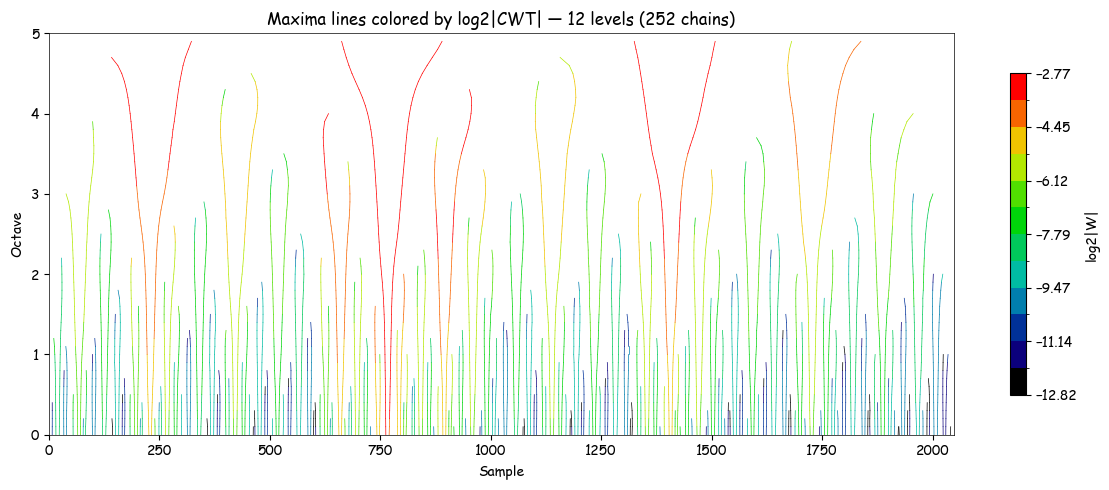

In [ ]:
# [CELL 5]
# Chains colored by log2|ordinate| (lastwave colormap, discretized)
N_COLORS = 12  # ← change this to set number of discrete color bins

fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains])
vmin, vmax = np.percentile(all_log2_vals, [2, 98])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W|', shrink=0.8)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines colored by log2|CWT| — {N_COLORS} levels ({len(chains)} chains)')
plt.tight_layout(); plt.show()

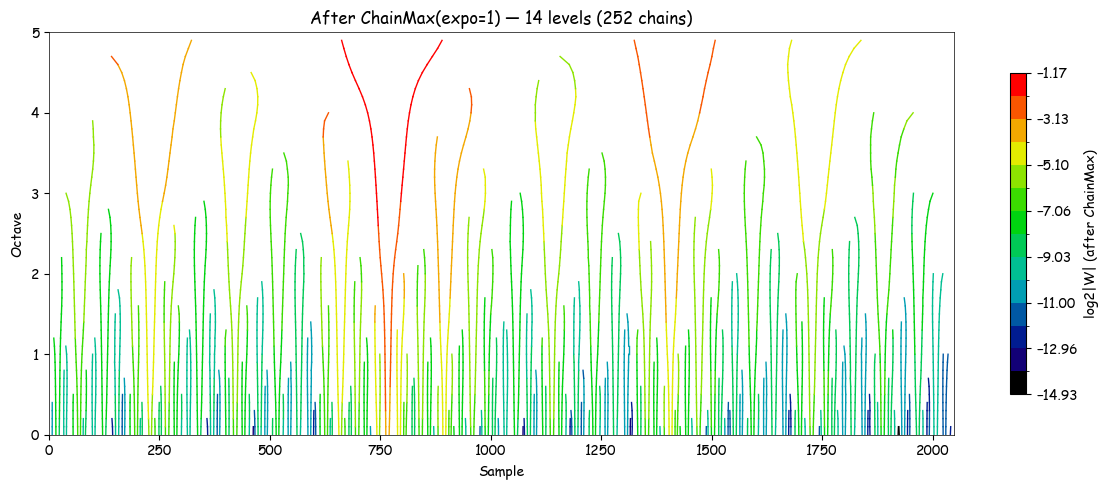

In [ ]:
# [CELL 6]
# Chains after ChainMax(expo=1) — colored by log2|ordinate| (lastwave colormap)
# ChainMax replaces each ordinate with the scale-adaptive max along the chain.
# Compare with cell 4 to see the difference.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f"lw_chain_max failed: {lib.lw_get_error()}"

chains_cm = extract_chains()

fig, ax = plt.subplots(figsize=(12, 5))
all_log2_vals = np.concatenate([np.log2(np.abs(ch['val']) + 1e-300) for ch in chains_cm])
vmin, vmax = np.percentile(all_log2_vals, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)
for ch in chains_cm:
    log2_v = np.log2(np.abs(ch['val']) + 1e-300)
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(log2_v[j])), lw=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2|W| (after ChainMax)', shrink=0.8)

# Tight margins: bottom and sides flush, keep top gap
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — {N_COLORS} levels ({len(chains_cm)} chains)')

# Thin frames
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'  # reset after

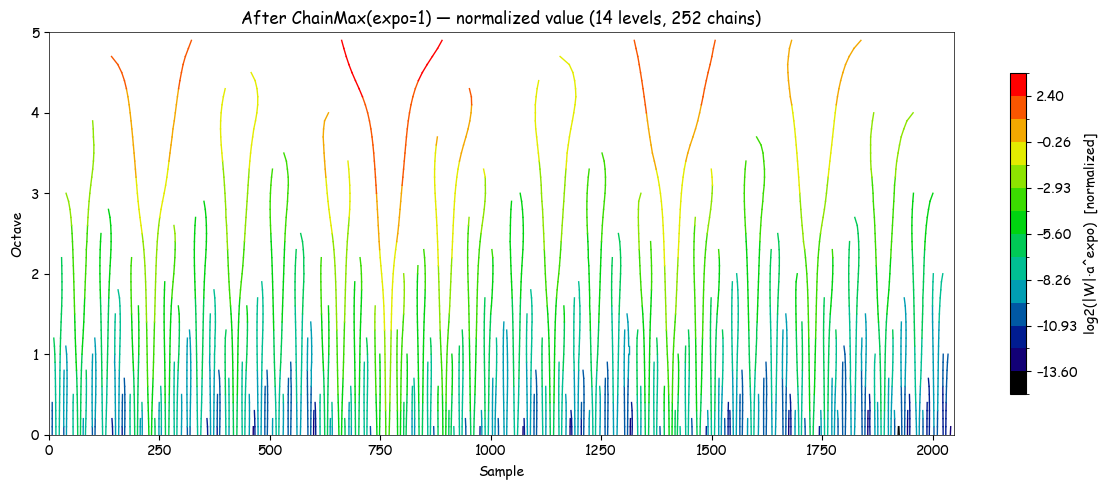

In [ ]:
# [CELL 7]
# Chains after ChainMax(expo=1) — colored by NORMALIZED value log2(|W|·a^expo)
# ChainMax guarantees monotonicity of the normalized value |W|·a^expo along each chain
# (non-increasing from fine→coarse). If ChainMax worked, each chain should appear
# as a single color or transition smoothly from warm (fine) to cool (coarse).

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

N_COLORS = 14
expo = 1.0

fig, ax = plt.subplots(figsize=(12, 5))

# Compute normalized values: |ordinate| * a^expo = |ordinate| * a_min * 2^(expo * scale_idx / n_voice)
all_norm_vals = []
for ch in chains_cm:
    norm_val = np.log2(np.abs(ch['val']) + 1e-300) + expo * ch['scale_idx'] / n_voice + np.log2(a_min)
    all_norm_vals.append(norm_val)

all_norm_concat = np.concatenate(all_norm_vals)
vmin, vmax = np.percentile(all_norm_concat, [0, 100])
boundaries = np.linspace(vmin, vmax, N_COLORS + 1)
norm = plt.matplotlib.colors.BoundaryNorm(boundaries, N_COLORS)
cmap = lastwave_colormap(N_COLORS)

for ch, nv in zip(chains_cm, all_norm_vals):
    for j in range(len(ch['x']) - 1):
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=cmap(norm(nv[j])), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='log2(|W|·a^expo)  [normalized]', shrink=0.8)

ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_yticklabels([str(i) for i in range(0, n_oct + 1)])
ax.set_title(f'After ChainMax(expo=1) — normalized value ({N_COLORS} levels, {len(chains_cm)} chains)')

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

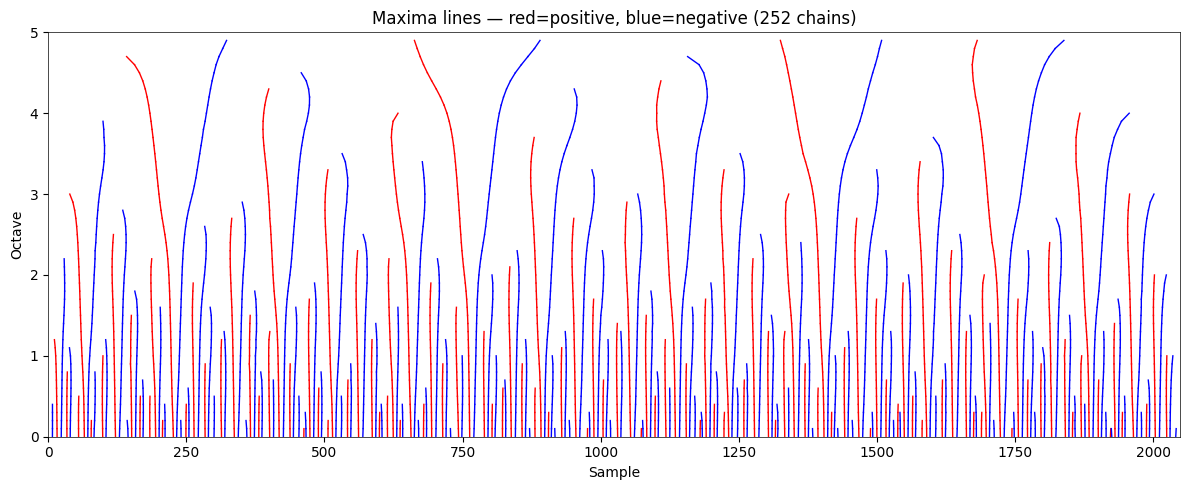

In [ ]:
# [CELL 8]
# Chains colored by sign: positive (red) / negative (blue)
fig, ax = plt.subplots(figsize=(12, 5))
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
for ch in chains:
    sign = np.sign(ch['val'])
    for j in range(len(ch['x']) - 1):
        c = 'red' if sign[j] > 0 else 'blue'
        ax.plot(ch['x'][j:j+2], ch['log2_a'][j:j+2], '-', color=c, lw=1, alpha=1)
ax.set_xlim(0, SIZE)
ax.set_ylim(0, n_oct)
ax.set_xlabel('Sample')
ax.set_ylabel('Octave')
ax.set_yticks(range(0, n_oct + 1))
ax.set_title(f'Maxima lines — red=positive, blue=negative ({len(chains)} chains)')
plt.tight_layout(); plt.show()

PF computed: 50 scales done, pf_size=50, n_q=12
Spectra computed via LastWave LineFitSig over [1.0, 4.0]


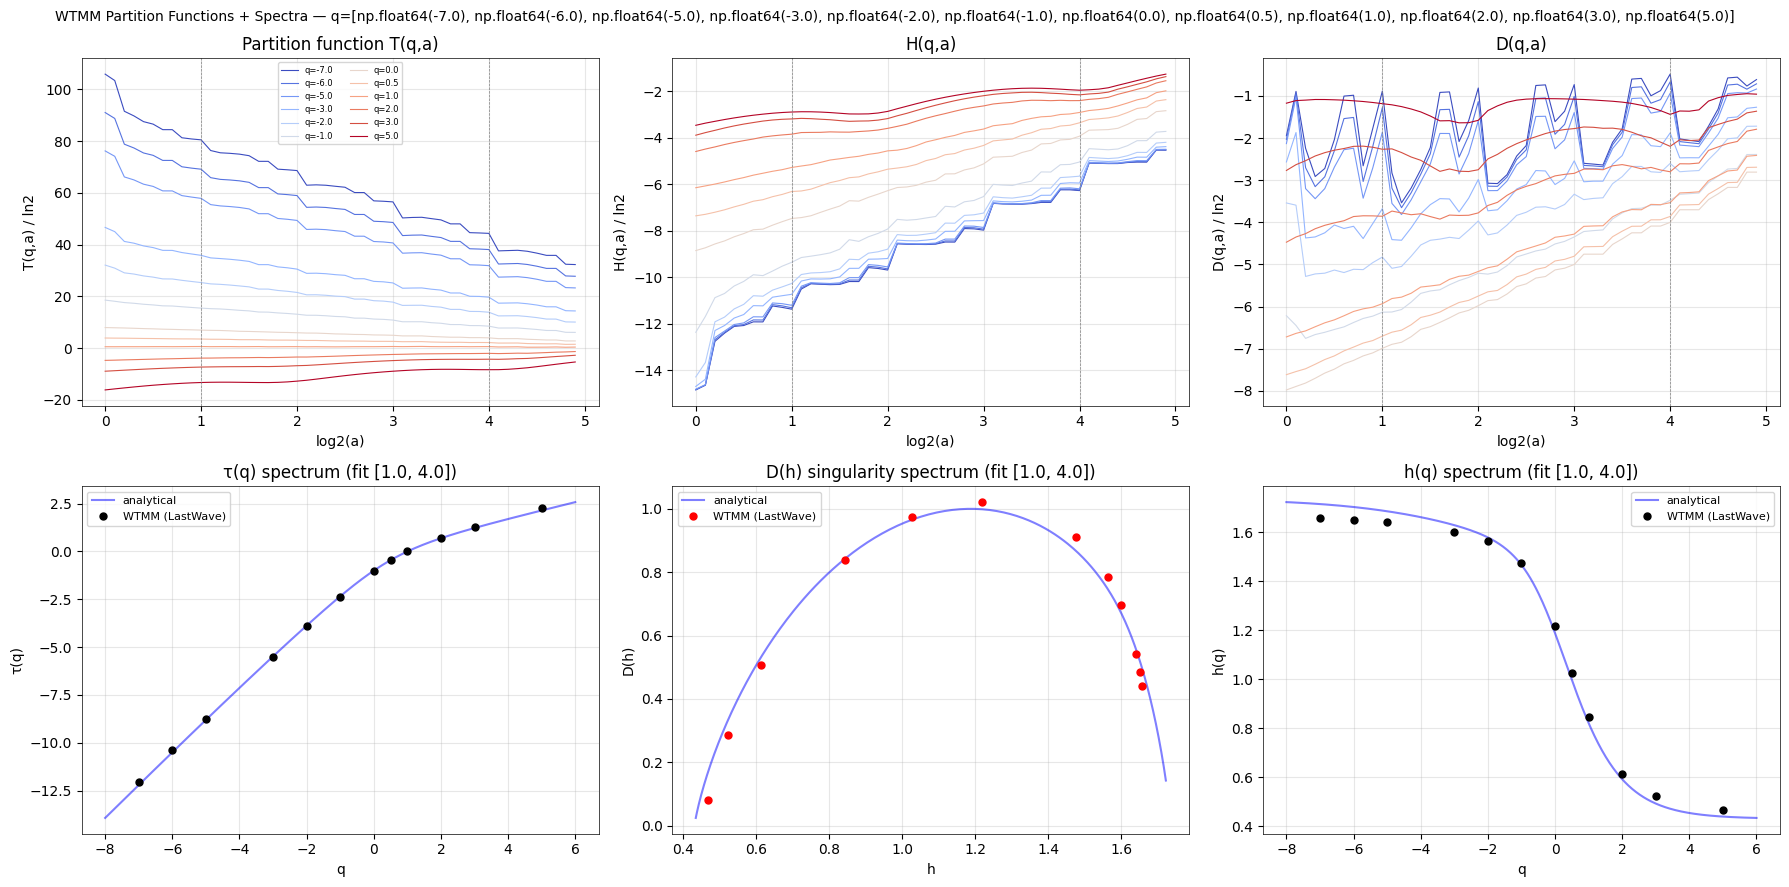


     q     tau(q)       ±σ       h(q)       ±σ       D(q)       ±σ
--------------------------------------------------------------------
  -7.0   -12.0466   0.2719     1.6581   0.0600     0.4395   0.1773
  -6.0   -10.3916   0.2159     1.6512   0.0574     0.4843   0.1563
  -5.0    -8.7454   0.1638     1.6405   0.0532     0.5431   0.1282
  -3.0    -5.4995   0.0786     1.6007   0.0388     0.6975   0.0576
  -2.0    -3.9151   0.0476     1.5648   0.0308     0.7856   0.0289
  -1.0    -2.3863   0.0235     1.4762   0.0239     0.9101   0.0128
   0.0    -1.0212   0.0094     1.2175   0.0127     1.0212   0.0094
   0.5    -0.4597   0.0071     1.0261   0.0095     0.9728   0.0094
   1.0     0.0066   0.0076     0.8444   0.0122     0.8377   0.0114
   2.0     0.7202   0.0239     0.6142   0.0280     0.5082   0.0344
   3.0     1.2812   0.0558     0.5220   0.0356     0.2849   0.0527
   5.0     2.2566   0.1230     0.4674   0.0310     0.0804   0.0360


In [ ]:
# [CELL 9]
# LastWave ground truth — Step 4: Partition functions + tau(q) + D(h) singularity spectrum
#
# DemoWTMM1DDevilStair:
#   qlist = {-7 -6 -5 -3 -2 -1 0 0.5 1 2 3 5}
#   pft = [pf wtmm w.extrep qlist]
#   disp {0w [tauqSpectrum pf 1 4] [singSpectrum pf 1 4]}
#
# tauqSpectrum/singSpectrum do linear regression of T(q,a), H(q,a), D(q,a)
# vs log2(a) over [log2aMin, log2aMax] = [1, 4].
# PF access functions return natural log; convert to log2 by dividing by ln(2).

# ── Declare signatures ──
lib.lw_compute_pf.restype = ctypes.c_int
lib.lw_compute_pf.argtypes = [ctypes.POINTER(ctypes.c_double), ctypes.c_int]

lib.lw_get_pf_size.restype = ctypes.c_int
lib.lw_get_pf_size.argtypes = []

lib.lw_get_pf_tq.restype = ctypes.c_int
lib.lw_get_pf_tq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_hq.restype = ctypes.c_int
lib.lw_get_pf_hq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

lib.lw_get_pf_dq.restype = ctypes.c_int
lib.lw_get_pf_dq.argtypes = [ctypes.c_int, ctypes.c_int, ctypes.POINTER(ctypes.c_double)]

# ── Compute partition functions ──
q_list = np.array([-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5], dtype=np.float64)
n_q = len(q_list)

n_scales_done = lib.lw_compute_pf(q_list.ctypes.data_as(c_double_p), n_q)
assert n_scales_done > 0, f"lw_compute_pf failed: {lib.lw_get_error()}"

pf_size = lib.lw_get_pf_size()
print(f"PF computed: {n_scales_done} scales done, pf_size={pf_size}, n_q={n_q}")

# ── Extract T(q,a), H(q,a), D(q,a) for all q ──
# Mode: PFEXTENSIVE=0, PFINTENSIVE=1
# PF x-axis: x0 = log2(a_min), dx = 1/n_voice
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
ln2 = np.log(2.0)

tq_all = {}  # q -> T(q,a) array in log2 units
hq_all = {}  # q -> H(q,a)
dq_all = {}  # q -> D(q,a)

for iq, q in enumerate(q_list):
    buf = np.zeros(pf_size, dtype=np.float64)

    ret = lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    tq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_hq(iq, 0, buf.ctypes.data_as(c_double_p))
    hq_all[q] = buf.copy() / ln2 if ret > 0 else None

    ret = lib.lw_get_pf_dq(iq, 0, buf.ctypes.data_as(c_double_p))
    dq_all[q] = buf.copy() / ln2 if ret > 0 else None

# ── Spectra via LastWave's own LineFitSig (replicates singSpectrum/tauqSpectrum) ──
log2a_min_fit, log2a_max_fit = 1.0, 4.0

lib.lw_compute_tauq_spectrum.restype = ctypes.c_int
lib.lw_compute_tauq_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]
lib.lw_compute_sing_spectrum.restype = ctypes.c_int
lib.lw_compute_sing_spectrum.argtypes = [
    ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_double,
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double), ctypes.POINTER(ctypes.c_double),
]

tau_q = np.zeros(n_q, dtype=np.float64)
tau_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_tauq_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    tau_q.ctypes.data_as(c_double_p), tau_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_tauq_spectrum failed: {lib.lw_get_error()}"

h_q = np.zeros(n_q, dtype=np.float64)
h_sigma = np.zeros(n_q, dtype=np.float64)
d_q = np.zeros(n_q, dtype=np.float64)
d_sigma = np.zeros(n_q, dtype=np.float64)
ret = lib.lw_compute_sing_spectrum(
    n_q, 0,  # mode=PFEXTENSIVE
    ctypes.c_double(log2a_min_fit), ctypes.c_double(log2a_max_fit),
    h_q.ctypes.data_as(c_double_p), h_sigma.ctypes.data_as(c_double_p),
    d_q.ctypes.data_as(c_double_p), d_sigma.ctypes.data_as(c_double_p),
)
assert ret == 0, f"lw_compute_sing_spectrum failed: {lib.lw_get_error()}"

print(f"Spectra computed via LastWave LineFitSig over [{log2a_min_fit}, {log2a_max_fit}]")


# ── Analytical tau(q) and D(h) for the inhomogeneous Cantor measure ──
# For a multinomial measure with parts (r_i, p_i), tau(q) satisfies:
#   sum_i  p_i^q * r_i^(-tau) = 1
# Solved numerically for each q. Then h(q) = tau'(q) and D(h) = q*h - tau.
from scipy.optimize import brentq

r_cantor = np.array([0.3, 0.2, 0.5])
p_cantor = np.array([0.2, 0.5, 0.3])

def tau_equation(tau, q, r, p):
    """sum_i p_i^q * r_i^(-tau) - 1 = 0"""
    return np.sum(p**q * r**(-tau)) - 1.0

q_fine = np.linspace(-8, 6, 500)
tau_analytical = np.zeros_like(q_fine)
for i, q in enumerate(q_fine):
    tau_analytical[i] = brentq(tau_equation, -20, 20, args=(q, r_cantor, p_cantor))

# h(q) = d(tau)/dq via finite differences
h_analytical = np.gradient(tau_analytical, q_fine)
# D(h) = q*h - tau  (Legendre transform)
d_analytical = q_fine * h_analytical - tau_analytical

# ── Plot ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# Panel (0,0): T(q,a) vs log2(a) for selected q
colors_q = plt.cm.coolwarm(np.linspace(0, 1, n_q))
for iq, q in enumerate(q_list):
    if tq_all[q] is not None:
        axes[0, 0].plot(log2_a_pf, tq_all[q], '-', color=colors_q[iq], lw=0.8, label=f'q={q}')
axes[0, 0].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 0].set_xlabel('log2(a)')
axes[0, 0].set_ylabel('T(q,a) / ln2')
axes[0, 0].set_title('Partition function T(q,a)')
axes[0, 0].legend(fontsize=6, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# Panel (0,1): H(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if hq_all[q] is not None:
        axes[0, 1].plot(log2_a_pf, hq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 1].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 1].set_xlabel('log2(a)')
axes[0, 1].set_ylabel('H(q,a) / ln2')
axes[0, 1].set_title('H(q,a)')
axes[0, 1].grid(True, alpha=0.3)

# Panel (0,2): D(q,a) vs log2(a)
for iq, q in enumerate(q_list):
    if dq_all[q] is not None:
        axes[0, 2].plot(log2_a_pf, dq_all[q], '-', color=colors_q[iq], lw=0.8)
axes[0, 2].axvline(log2a_min_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].axvline(log2a_max_fit, color='gray', ls='--', lw=0.5)
axes[0, 2].set_xlabel('log2(a)')
axes[0, 2].set_ylabel('D(q,a) / ln2')
axes[0, 2].set_title('D(q,a)')
axes[0, 2].grid(True, alpha=0.3)

# Panel (1,0): tau(q) spectrum
axes[1, 0].plot(q_fine, tau_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 0].plot(q_list, tau_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 0].set_xlabel('q')
axes[1, 0].set_ylabel('\u03c4(q)')
axes[1, 0].set_title(f'\u03c4(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Panel (1,1): D(h) singularity spectrum
axes[1, 1].plot(h_analytical, d_analytical, 'b-', lw=1.5, alpha=0.5, label='analytical')
sort_idx = np.argsort(h_q)
axes[1, 1].plot(h_q[sort_idx], d_q[sort_idx], 'ro', markersize=5, label='WTMM (LastWave)')
axes[1, 1].set_xlabel('h')
axes[1, 1].set_ylabel('D(h)')
axes[1, 1].set_title(f'D(h) singularity spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

# Panel (1,2): h(q) vs q
h_analytical_q = np.gradient(tau_analytical, q_fine)
axes[1, 2].plot(q_fine, h_analytical_q, 'b-', lw=1.5, alpha=0.5, label='analytical')
axes[1, 2].plot(q_list, h_q, 'ko', markersize=5, label='WTMM (LastWave)')
axes[1, 2].set_xlabel('q')
axes[1, 2].set_ylabel('h(q)')
axes[1, 2].set_title(f'h(q) spectrum (fit [{log2a_min_fit}, {log2a_max_fit}])')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"WTMM Partition Functions + Spectra — q={list(q_list)}", fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary ──
print(f"\n{'q':>6} {'tau(q)':>10} {'±σ':>8} {'h(q)':>10} {'±σ':>8} {'D(q)':>10} {'±σ':>8}")
print('-' * 68)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {tau_sigma[iq]:8.4f} {h_q[iq]:10.4f} {h_sigma[iq]:8.4f} {d_q[iq]:10.4f} {d_sigma[iq]:8.4f}')

# Faithful WTMM Implementation with GPU Acceleration

A Python reimplementation of LastWave's WTMM (Wavelet Transform Modulus Maxima) algorithm
for multifractal analysis. Faithfully matches LastWave's `CWtd()`, `extrema`, `chain`,
`chainmax`, and `pf wtmm` pipeline.

**GPU**: PyTorch MPS on Apple Silicon M2 Max

In [ ]:
# Cell 10: Imports and device setup
#
# Fix duplicate libomp crash (torch + numba both link OpenMP on macOS)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange
from numba.typed import List as NumbaList

torch.set_default_dtype(torch.float64)
print(f'PyTorch {torch.__version__}, device: CPU, dtype: float64')


PyTorch 2.10.0, device: CPU, dtype: float64


In [ ]:
# Cell 11: Gaussian derivative wavelets — imported from wtmm package

from wtmm.wavelets import WAVELETS, wavelet_direct, wavelet_support

# Quick test: plot g2 at scale a=1
x_test = np.linspace(-20, 20, 1000)
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
for i, name in enumerate(['g0', 'g1', 'g2', 'g3', 'g4']):
    axes[i].plot(x_test, wavelet_direct(x_test, 1.0, name))
    axes[i].set_title(name)
    axes[i].axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: CWT engine — imported from wtmm package

from wtmm.cwt import cwtd, cwtd_batched

print('CWT engine imported from wtmm.cwt. Use cwtd() for faithful per-scale, cwtd_batched() for optimized.')

In [ ]:
# Cell 13: Devil's staircase test signal — imported from wtmm package

from wtmm.signals import ucantor, tau_equation

# Generate devil's staircase: ucantor then prim (cumulative sum)
# DemoWTMM1DDevilStair: ucantor 0w size 0.3 0.2 0.2 0.5 0.5 0.3
# Command parsing: signal size r0 p0 r1 p1 r2 p2
# So r = [0.3, 0.2, 0.5], p = [0.2, 0.5, 0.3]
# nFlip defaults to 0, but C_UCantor does nFlip-- so nFlip = -1 (no flip)

SIZE = 2048
cantor_measure, dx = ucantor(SIZE, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], nFlip=-1)

# prim = cumulative sum (matching LastWave's prim())
devil_staircase = np.cumsum(cantor_measure)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
for spine in ax1.spines.values(): spine.set_linewidth(0.5)
for spine in ax2.spines.values(): spine.set_linewidth(0.5)
t_axis = np.arange(SIZE) * dx
ax1.plot(t_axis, cantor_measure)
ax1.set_title('Non-uniform Cantor measure')
ax2.plot(t_axis, devil_staircase)
ax2.set_title("Devil\'s staircase (integrated Cantor)")
plt.tight_layout()
plt.show()

print(f'Signal size: {SIZE}, dx: {dx}')
print(f'Staircase range: [{devil_staircase.min():.4f}, {devil_staircase.max():.4f}]')

Sawtooth: 10000 samples, 10.0s, period=0.3s, ramp=95%


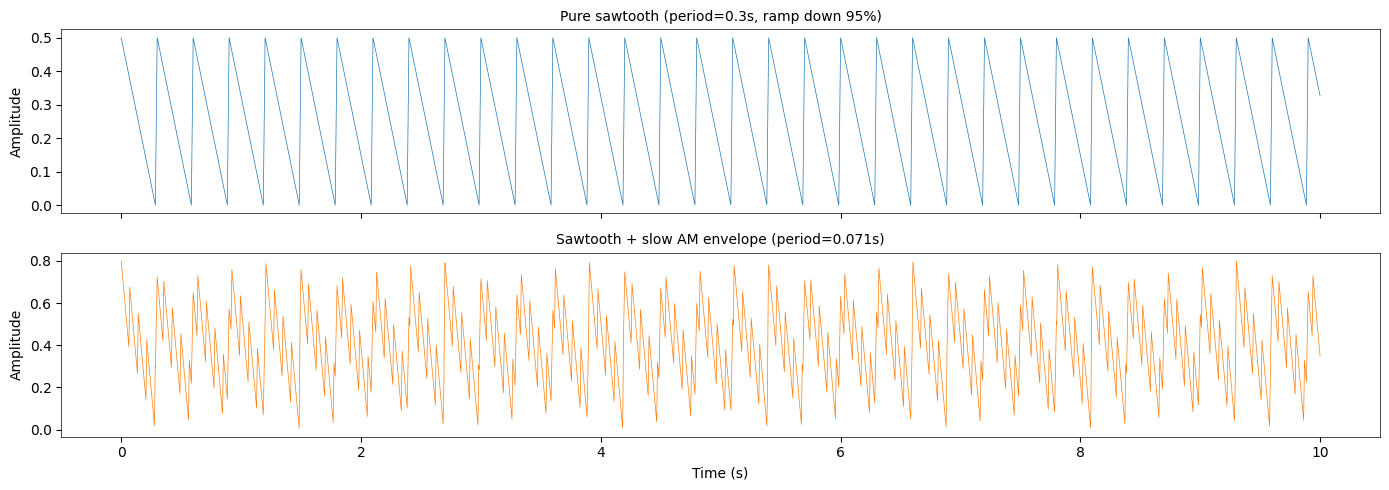

In [ ]:
# ══════════════════════════════════════════════════════════════
# HHT on a synthetic sawtooth: slow ramp down, sharp spike up
# ══════════════════════════════════════════════════════════════
# This tests how EMD + Hilbert-Huang handles sharp singularities
# analogous to creepmeter slip events (slow accumulation + sudden release).
import emd
from scipy import ndimage

# ── 1. Build piecewise-linear sawtooth ──
saw_sr = 1000.0          # samples/sec (arbitrary, just for clean numbers)
saw_duration = 10.0       # seconds total
saw_period = 0.3          # period of one tooth (seconds)
ramp_frac = 0.95          # fraction of period spent ramping down
amplitude = .5

t_saw = np.arange(0, saw_duration, 1.0 / saw_sr)
n_saw = len(t_saw)

# Phase within each tooth [0, 1)
phase = (t_saw % saw_period) / saw_period

# Ramp down for ramp_frac of the period, then spike up
saw = np.where(phase < ramp_frac,
               amplitude * (1.0 - phase / ramp_frac),       # linear ramp down
               amplitude * (phase - ramp_frac) / (1.0 - ramp_frac))  # sharp rise back

# Add a second slower sawtooth as AM envelope (period = 2s)
slow_period = .071
slow_phase = (t_saw % slow_period) / slow_period
slow_env = 0.3 * np.where(slow_phase < 0.9,
                           1.0 - slow_phase / 0.9,
                           (slow_phase - 0.9) / 0.1)
saw_modulated = saw + slow_env

print(f'Sawtooth: {n_saw} samples, {saw_duration}s, period={saw_period}s, ramp={ramp_frac*100:.0f}%')

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
for ax in axes:
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
axes[0].plot(t_saw, saw, lw=0.5)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Pure sawtooth (period={saw_period}s, ramp down {ramp_frac*100:.0f}%)', fontsize=10)
axes[1].plot(t_saw, saw_modulated, lw=0.5, color='tab:orange')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Sawtooth + slow AM envelope (period={slow_period}s)', fontsize=10)
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


CWT computed in 0.427s
Coefficients shape: (50, 10000), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (18, 9981), coarsest: (537, 9462)


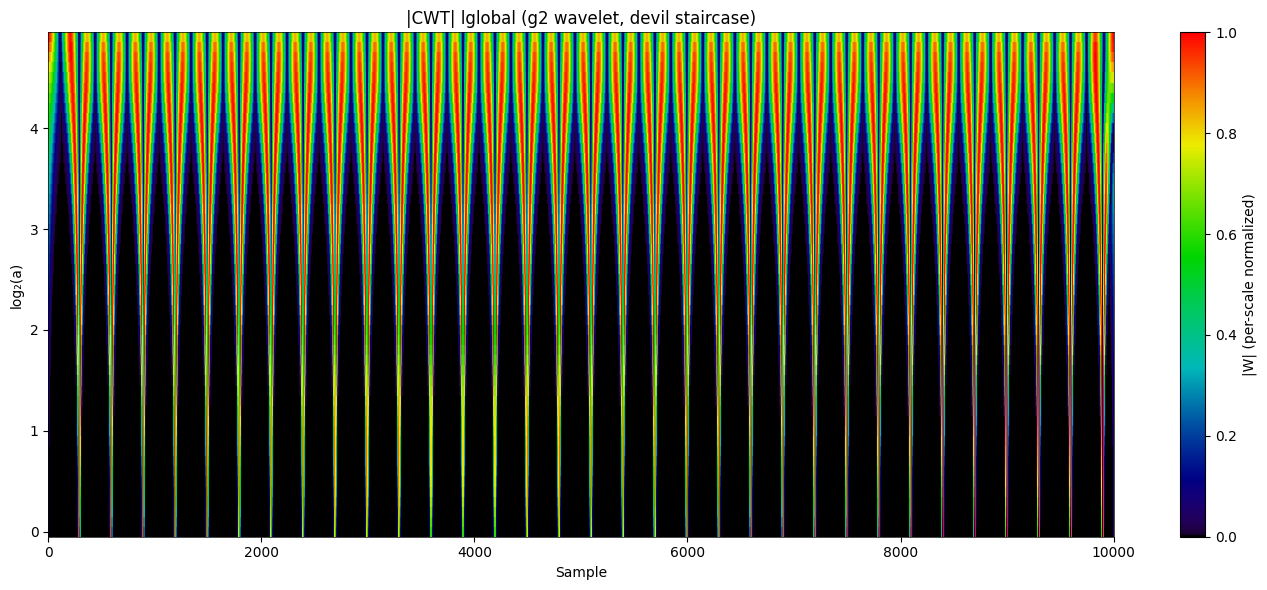

In [ ]:
# Cell 14: CWT + visualization on devil's staircase
# DemoWTMM1DDevilStair: cwtd w 1.0 5 10 'g2' -b 'mir'
# Default expo = -1

t0 = time.time()
coeffs, scales, valid_ranges = cwtd(saw, a_min=1.0, n_oct=5, n_voice=10,
                                     wavelet_name='g2', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs.shape}, Scales: {len(scales)} ({scales[0]:.2f} to {scales[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges[0]}, coarsest: {valid_ranges[-1]}')

# Plot scalogram — LastWave lglobal normalization (no log)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
im = scalogram_lastwave(coeffs, scales=scales, ax=ax,
                        norm_mode='lglobal')
ax.set_title('|CWT| lglobal (g2 wavelet, devil staircase)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 15: Extrema detection — imported from wtmm package

from wtmm.extrema import compute_extlis_numba, compute_extrep

# Compute extrema representation
dx_signal = 1.0 / SIZE
t0 = time.time()
# Warm up Numba
_ = compute_extlis_numba(coeffs[0], dx_signal, 0.0, 1e-6,
                          valid_ranges[0][0], valid_ranges[0][1])
t_warmup = time.time()
print(f'Numba warmup: {t_warmup - t0:.3f}s')

extrep_abs, extrep_ord, extrep_idx = compute_extrep(
    coeffs, scales, n_oct=5, n_voice=10, a_min=1.0,
    valid_ranges=valid_ranges, dx=dx_signal, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t_warmup:.3f}s')
for sidx in [0, 10, 20, 30, 40, 49]:
    print(f'  Scale {sidx} (a={scales[sidx]:.2f}): {len(extrep_abs[sidx])} extrema')

In [ ]:
# Cell 16: Chaining — imported from wtmm package

from wtmm.chains import chain_all, chain_delete_all, chain_max_wrapper, trace_chains, save_chain_state

# Run full chaining pipeline
t0 = time.time()
coarser_links, finer_links = chain_all(extrep_abs, extrep_ord, n_oct=5, n_voice=10)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs, pre_del_ord, pre_del_cl = save_chain_state(extrep_abs, extrep_ord, coarser_links)
pre_del_chains = trace_chains(pre_del_abs, pre_del_ord, pre_del_cl, scales, 5 * 10)

nb_del = chain_delete_all(extrep_abs, extrep_ord, extrep_idx,
                           coarser_links, finer_links, n_oct=5, n_voice=10)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

# ChainMax with expo=1
chain_max_wrapper(extrep_ord, coarser_links, n_oct=5, n_voice=10, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')
print(f'Total chaining: {t1 - t0:.3f}s')

remaining = sum(len(a) for a in extrep_abs)
print(f'Remaining extrema: {remaining}')

Pre-deletion chains: 66
Surviving chains: 66
Deleted chains: 0


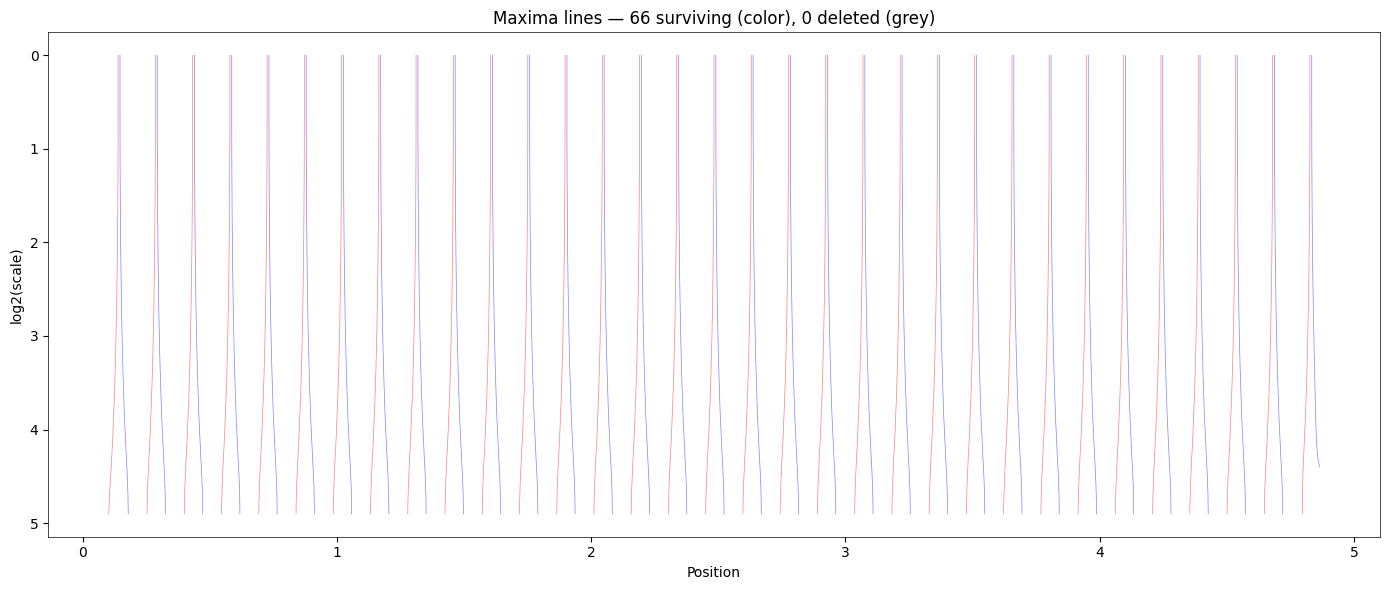

In [ ]:
# Cell 17: Extrema representation and maxima lines visualization

# Surviving chains (after deletion)
post_del_chains = trace_chains(extrep_abs, extrep_ord, coarser_links, scales, 5 * 10)

# Find which pre-deletion chains were deleted (not present in post-deletion)
# Build set of surviving chain start positions for fast lookup
surviving_starts = set()
for pos, sv, sign, *_rest in post_del_chains:
    surviving_starts.add((pos[0], sign))

deleted_chains = []
for pos, sv, sign, *_rest in pre_del_chains:
    if (pos[0], sign) not in surviving_starts:
        deleted_chains.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains)}')
print(f'Surviving chains: {len(post_del_chains)}')
print(f'Deleted chains: {len(deleted_chains)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

# Draw deleted chains first (background, grey)
for pos, sv, sign, *_rest in deleted_chains:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

# Draw surviving chains on top
for pos, sv, sign, *_rest in post_del_chains:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — {len(post_del_chains)} surviving (color), {len(deleted_chains)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Partition function — imported from wtmm package

from wtmm.partition import compute_partition_function, pf_get_T, pf_get_H, pf_get_D

q_list = [-7, -6, -5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf = compute_partition_function(extrep_ord, n_oct=5, n_voice=10, a_min=1.0, q_list=q_list)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf["index_max"]}')
print(f'Extrema per scale (sample): {pf["n_ext"][:5]}...{pf["n_ext"][-5:]}')

# Plot T(q,a) = log2(Z(q,a)) vs log2(a) — this is what LastWave's "pf get t" returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_a = pf['log2_a']
valid = slice(0, pf['index_max'] + 1)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_list)))

# T(q,a)
ax = axes[0]
for i, q in enumerate(pf['q_list']):
    y = pf_get_T(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a)
ax = axes[1]
for i, q in enumerate(pf['q_list']):
    y = pf_get_H(pf, i)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a)
ax = axes[2]
for i, q in enumerate(pf['q_list']):
    y = pf_get_D(pf, i, q)[valid]
    ax.plot(log2_a[valid], y, 'o-', color=colors[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')


In [ ]:
# Cell 19: tau(q), h(q), D(h) spectrum — imported from wtmm package

from wtmm.spectra import compute_spectra, theoretical_devil_staircase

spectra = compute_spectra(pf, log2_a_min=1.0, log2_a_max=4.0)

# Theoretical values — use expo=-1 to match our CWT normalization
q_fine = np.linspace(-7, 5, 200)
tau_theory, h_theory, D_theory = theoretical_devil_staircase(
    q_fine, r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

tau_theory_q, h_theory_q, D_theory_q = theoretical_devil_staircase(
    spectra['q_list'], r=[0.3, 0.2, 0.5], p=[0.2, 0.5, 0.3], expo=-1.0)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# 1. tau(q)
ax = axes[0]
ax.plot(q_fine, tau_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. h(q) comparison
ax = axes[1]
ax.plot(q_fine, h_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['q_list'], spectra['h_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) = slope of H(q,a) vs log2(a)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. D(h) singularity spectrum
ax = axes[2]
ax.plot(h_theory, D_theory, 'k-', label='Theory', linewidth=1)
ax.plot(spectra['h_q'], spectra['D_q'], 'ro', markersize=6, label='WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

# Print comparison
print(f'\nTheoretical: expo={-1.0}, so tau_WTMM = tau_measure (integration + 1/a cancel)')
print(f'h range: [{h_theory_q.min():.3f}, {h_theory_q.max():.3f}]')
print('\nq\t tau_WTMM\t tau_theory\t diff\t\t h_WTMM\t\t h_theory')
for i, q in enumerate(spectra['q_list']):
    print(f'{q:5.1f}\t {spectra["tau_q"][i]:8.4f}\t {tau_theory_q[i]:8.4f}\t {spectra["tau_q"][i]-tau_theory_q[i]:+.4f}'
          f'\t {spectra["h_q"][i]:8.4f}\t {h_theory_q[i]:8.4f}')

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_49707/2992841337.py:81: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  plt.tight_layout()
/Users/amasaryk/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


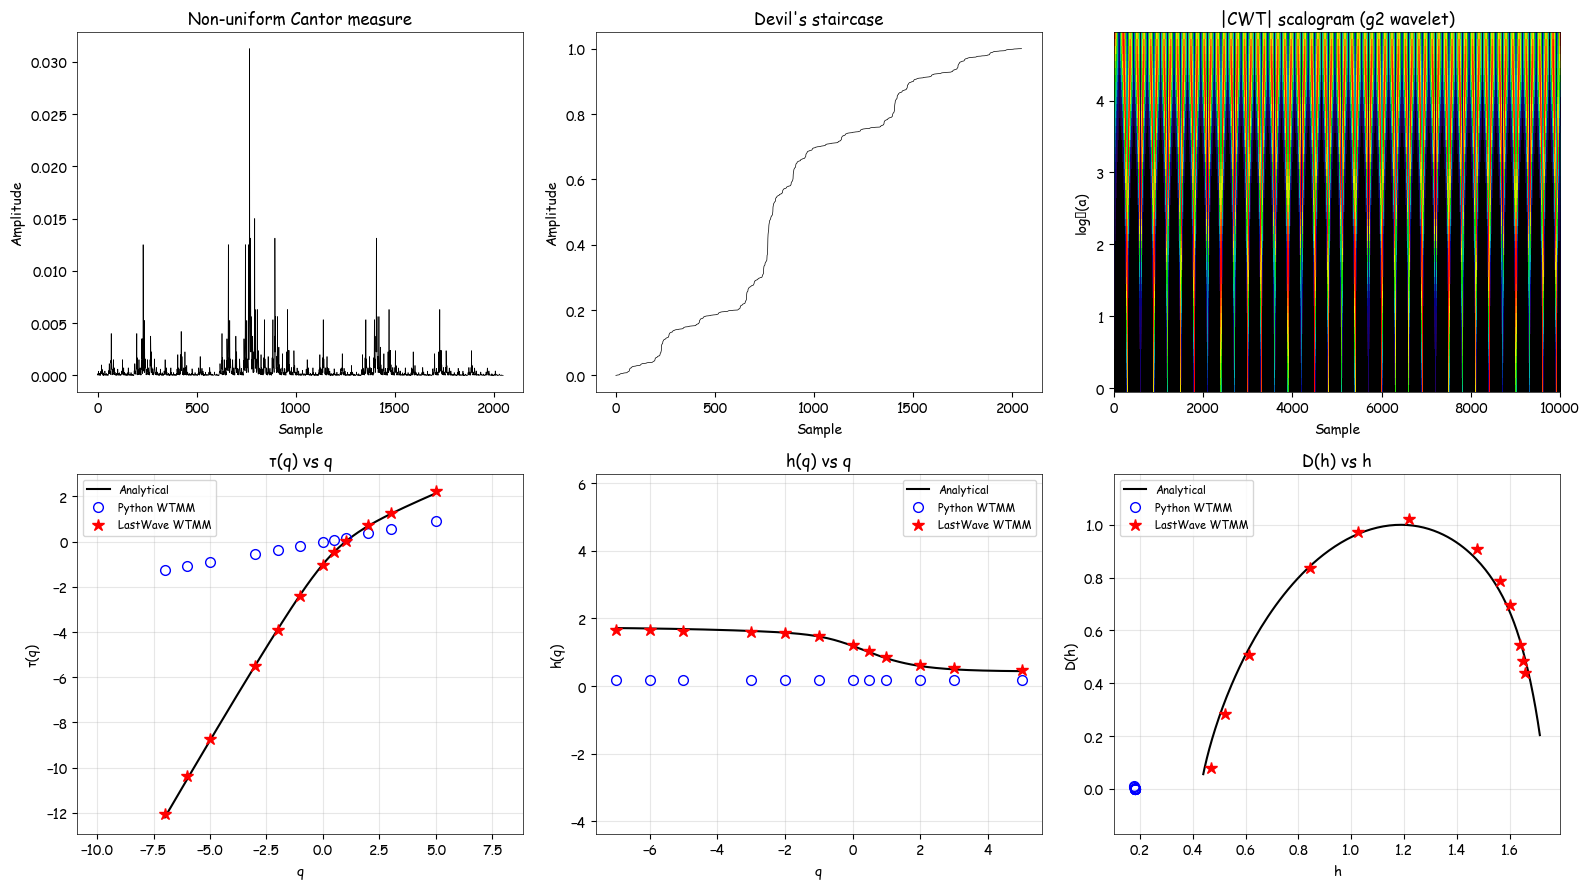

In [ ]:
# CELL 20
# Three-way comparison: LastWave WTMM vs Python WTMM vs Analytical
#
# Top row: signals and scalogram
# Bottom row: tau(q), h(q), D(h) spectra with equal aspect

import matplotlib as mpl

# Comic Sans styling
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Thin spines on all axes
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# ── Top row: signals + scalogram ──

# (0,0): Cantor measure
ax = axes[0, 0]
ax.plot(cantor_measure, 'k-', lw=0.5)
ax.set_title('Non-uniform Cantor measure')
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,1): Devil's staircase
ax = axes[0, 1]
ax.plot(devil_staircase, 'k-', lw=0.5)
ax.set_title("Devil's staircase")
ax.set_xlabel('Sample')
ax.set_ylabel('Amplitude')

# (0,2): Scalogram
ax = axes[0, 2]
scalogram_lastwave(coeffs, scales=scales, ax=ax, norm_mode='lglobal')
ax.set_title('|CWT| scalogram (g2 wavelet)')

# ── Bottom row: three-way spectra (equal aspect) ──

# (1,0): tau(q) vs q
ax = axes[1, 0]
ax.plot(q_fine, tau_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,1): h(q) vs q
ax = axes[1, 1]
ax.plot(q_fine, h_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(q_list, h_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# (1,2): D(h) vs h
ax = axes[1, 2]
ax.plot(h_theory, D_theory, 'k-', lw=1.5, label='Analytical')
ax.plot(spectra['h_q'], spectra['D_q'], 'bo', fillstyle='none',
        markersize=7, label='Python WTMM')
ax.plot(h_q, d_q, 'r*', markersize=9, label='LastWave WTMM')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

# Reset font
mpl.rcParams['font.family'] = 'sans-serif'

Total extrema: LW=3645, Python=3295
Count mismatches at scales: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]
  Scale 0: LW=252, Py=66
  Scale 1: LW=238, Py=66
  Scale 2: LW=225, Py=66
  Scale 3: LW=208, Py=66
  Scale 4: LW=191, Py=66
  Scale 5: LW=179, Py=66
  Scale 6: LW=164, Py=66
  Scale 7: LW=155, Py=66
  Scale 8: LW=144, Py=66
  Scale 9: LW=137, Py=66
  Scale 10: LW=127, Py=66
  Scale 11: LW=119, Py=66
  Scale 12: LW=115, Py=66
  Scale 13: LW=105, Py=66
  Scale 14: LW=93, Py=66
  Scale 15: LW=89, Py=66
  Scale 16: LW=83, Py=66
  Scale 17: LW=77, Py=66
  Scale 18: LW=71, Py=66
  Scale 19: LW=68, Py=66
  Scale 20: LW=63, Py=66
  Scale 21: LW=58, Py=66
  Scale 22: LW=57, Py=66
  Scale 23: LW=52, Py=66
  Scale 24: LW=46, Py=66
  Scale 25: LW=44, Py=66
  Scale 26: LW=40, Py=66
  Scale 27: LW=39, Py=66
  Scale 28: LW=35, Py=66
  Scale 29: LW=34, Py=66
  Scale 30: LW=32, Py=66
  S

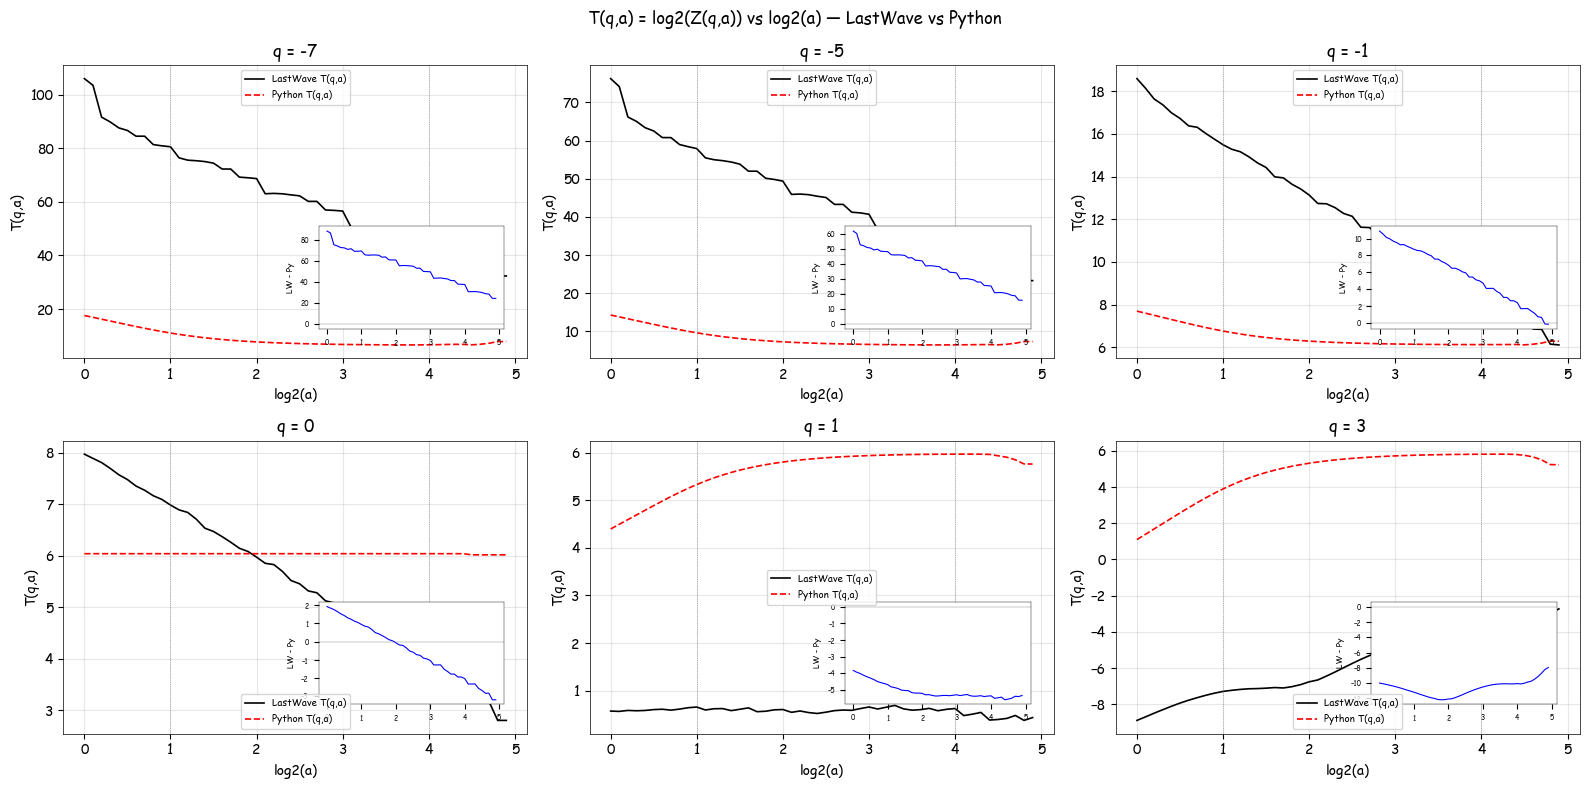

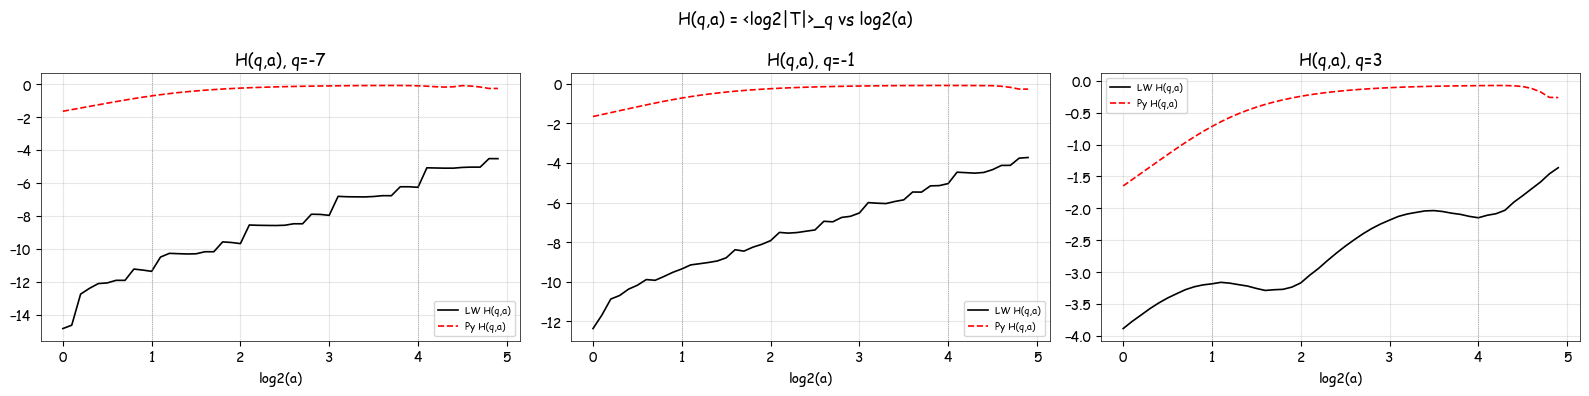

In [ ]:
# CELL 21
# Extrema + Partition function comparison: LastWave vs Python
#
# 1. Extrema counts and ordinate values at each scale
# 2. T(q,a), H(q,a), D(q,a) at every scale for all q values
# 3. Plots of T(q,a) vs log2(a) for selected q values

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# ═══ Part 1: Extrema comparison ═══
lw_ext_post = {}
lw_counts = np.zeros(n_scales, dtype=int)
py_counts = np.zeros(n_scales, dtype=int)

for o in range(1, n_oct + 1):
    for v in range(n_voice):
        scale_idx = (o - 1) * n_voice + v
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v,
                pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p),
                count)
            lw_ext_post[scale_idx] = (pos[:got], val[:got])
            lw_counts[scale_idx] = got
        else:
            lw_ext_post[scale_idx] = (np.array([]), np.array([]))
        py_counts[scale_idx] = len(extrep_ord[scale_idx])

print(f'Total extrema: LW={lw_counts.sum()}, Python={py_counts.sum()}')
mismatches = np.where(lw_counts != py_counts)[0]
if len(mismatches):
    print(f'Count mismatches at scales: {mismatches}')
    for s in mismatches:
        print(f'  Scale {s}: LW={lw_counts[s]}, Py={py_counts[s]}')

# ═══ Part 2: T(q,a), H(q,a), D(q,a) comparison ═══
ln2 = np.log(2.0)

# Extract all LW partition function curves
lw_T = {}  # q_idx -> array over scales
lw_H = {}
lw_D = {}
for iq in range(len(q_list)):
    buf = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_tq(iq, 0, buf.ctypes.data_as(c_double_p))
    lw_T[iq] = buf.copy() / ln2

    buf2 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_hq(iq, 0, buf2.ctypes.data_as(c_double_p))
    lw_H[iq] = buf2.copy() / ln2

    buf3 = np.zeros(pf_size, dtype=np.float64)
    lib.lw_get_pf_dq(iq, 0, buf3.ctypes.data_as(c_double_p))
    lw_D[iq] = buf3.copy() / ln2

# Python partition function curves
py_T = {}
py_H = {}
py_D = {}
for iq in range(len(q_list)):
    py_T[iq] = pf_get_T(pf, iq, 'extensive')
    py_H[iq] = pf_get_H(pf, iq, 'extensive')
    py_D[iq] = pf_get_D(pf, iq, q_list[iq], 'extensive')

# ═══ Part 3: Summary table — max |diff| for each q ═══
log2_a_pf = np.log2(a_min) + np.arange(pf_size) / n_voice
n_compare = min(pf_size, n_scales)

print(f'\n{"q":>5} {"max|dT|":>12} {"max|dH|":>12} {"max|dD|":>12}  {"worst scale":>12}')
print('-' * 60)
for iq, q in enumerate(q_list):
    dT = np.abs(lw_T[iq][:n_compare] - py_T[iq][:n_compare])
    dH = np.abs(lw_H[iq][:n_compare] - py_H[iq][:n_compare])
    dD = np.abs(lw_D[iq][:n_compare] - py_D[iq][:n_compare])
    # ignore NaN
    dT = np.where(np.isfinite(dT), dT, 0)
    dH = np.where(np.isfinite(dH), dH, 0)
    dD = np.where(np.isfinite(dD), dD, 0)
    worst = np.argmax(dT)
    print(f'{q:5.1f} {dT.max():12.6f} {dH.max():12.6f} {dD.max():12.6f}  {worst:5d} (log2a={log2_a_pf[worst]:.1f})')

# ═══ Part 4: Plots — T(q,a) vs log2(a) for selected q values ═══
sel_q = [-7, -5, -1, 0, 1, 3]
sel_iq = [list(q_list).index(q) for q in sel_q]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax in axes.flatten():
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for idx, (ax, iq) in enumerate(zip(axes.flatten(), sel_iq)):
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_T[iq][:n_compare], 'k-', lw=1.2, label='LastWave T(q,a)')
    ax.plot(x, py_T[iq][:n_compare], 'r--', lw=1.2, label='Python T(q,a)')

    # Show fit range
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)

    ax.set_xlabel('log2(a)')
    ax.set_ylabel('T(q,a)')
    ax.set_title(f'q = {q}')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Inset: difference
    inset = ax.inset_axes([0.55, 0.1, 0.4, 0.35])
    diff = lw_T[iq][:n_compare] - py_T[iq][:n_compare]
    inset.plot(x, diff, 'b-', lw=0.8)
    inset.set_ylabel('LW - Py', fontsize=6)
    inset.tick_params(labelsize=5)
    inset.axhline(0, color='gray', ls='-', lw=0.3)
    for sp in inset.spines.values(): sp.set_linewidth(0.3)

plt.suptitle('T(q,a) = log2(Z(q,a)) vs log2(a) — LastWave vs Python', fontsize=12)
plt.tight_layout()
plt.show()

# ═══ Part 5: H(q,a) comparison for extreme q ═══
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for ax in axes2: 
    for spine in ax.spines.values(): spine.set_linewidth(0.5)

for ax, iq in zip(axes2, [0, 5, 10]):  # q=-7, q=-1, q=3
    q = q_list[iq]
    x = log2_a_pf[:n_compare]
    ax.plot(x, lw_H[iq][:n_compare], 'k-', lw=1.2, label='LW H(q,a)')
    ax.plot(x, py_H[iq][:n_compare], 'r--', lw=1.2, label='Py H(q,a)')
    ax.axvline(1.0, color='gray', ls=':', lw=0.5)
    ax.axvline(4.0, color='gray', ls=':', lw=0.5)
    ax.set_title(f'H(q,a), q={q}')
    ax.set_xlabel('log2(a)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('H(q,a) = <log2|T|>_q vs log2(a)', fontsize=12)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


LW valid ranges: 50 scales, e.g. finest=(18, 2029), coarsest=(537, 1510)
Total extrema: 3645
Extrema on LW CWT: 0.015s
Chaining: 0.000s
Delete: 0.001s, deleted 0 chains
ChainMax: 0.001s
Remaining extrema (LW CWT): 3645
PF computed in 0.002s, up to scale index 49
Spectra computed for 12 q values

Extrema count comparison (after chain processing):
  Python CWT extrema total: 3295
  LW CWT extrema total:     3645
  Mismatched scales (50):
    Scale 0 (a=1.00): PyCWT=66, LWCWT=252
    Scale 1 (a=1.07): PyCWT=66, LWCWT=238
    Scale 2 (a=1.15): PyCWT=66, LWCWT=225
    Scale 3 (a=1.23): PyCWT=66, LWCWT=208
    Scale 4 (a=1.32): PyCWT=66, LWCWT=191
    Scale 5 (a=1.41): PyCWT=66, LWCWT=179
    Scale 6 (a=1.52): PyCWT=66, LWCWT=164
    Scale 7 (a=1.62): PyCWT=66, LWCWT=155
    Scale 8 (a=1.74): PyCWT=66, LWCWT=144
    Scale 9 (a=1.87): PyCWT=66, LWCWT=137

     q     tau_LW  tau_PyCWT  tau_LWCWT       h_LW    h_PyCWT    h_LWCWT       D_LW    D_PyCWT    D_LWCWT
---------------------------------

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_49707/3616245384.py:135: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Comic Sans MS.
  plt.tight_layout()


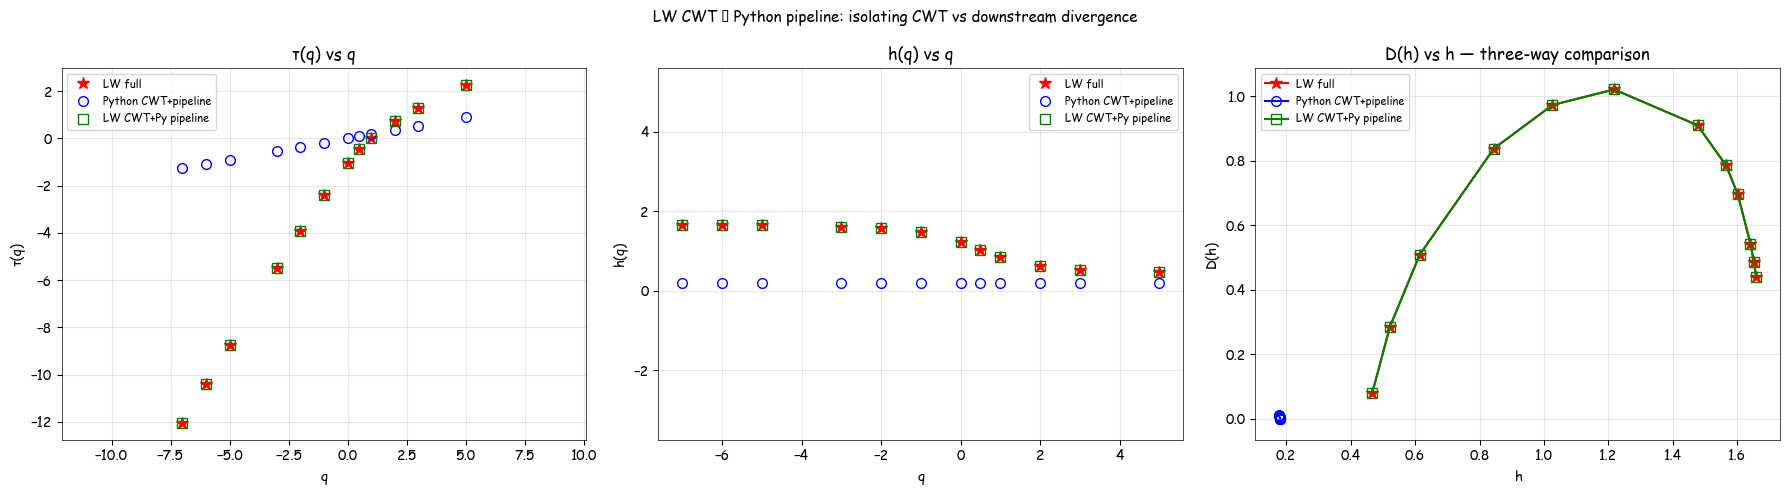


Max absolute differences vs LW ground truth:
  LW CWT+Py pipeline: tau=0.000000, h=0.000000, D=0.000000
  Py CWT+Py pipeline: tau=10.787249, h=1.479757, D=1.021170


In [ ]:
# CELL 22: LW-CWT + Python pipeline — isolate CWT vs downstream divergence
#
# Feed LastWave's CWT coefficients (cwt, from cell 2) into the Python
# extrema → chain → PF → spectra pipeline. If the resulting D(h) matches
# LW ground truth, the Python downstream is correct and the CWT is the
# source of D(h) divergence.

import time as _time
import matplotlib as mpl

# ── 1. Build LW-compatible valid_ranges ──
lw_vr = list(zip(firstp.tolist(), lastp.tolist()))
print(f'LW valid ranges: {len(lw_vr)} scales, e.g. finest={lw_vr[0]}, coarsest={lw_vr[-1]}')

# ── 2. Run Python extrema on LW CWT ──
dx_signal_lw = 1.0 / SIZE
t0 = _time.time()
lw_extrep_abs, lw_extrep_ord, lw_extrep_idx = compute_extrep(
    cwt, scales, n_oct=n_oct, n_voice=n_voice, a_min=a_min,
    valid_ranges=lw_vr, dx=dx_signal_lw, x0=0.0, epsilon=1e-6)
t1 = _time.time()
print(f'Extrema on LW CWT: {t1-t0:.3f}s')

# ── 3. Run Python chaining ──
t2 = _time.time()
lw_coarser_links, lw_finer_links = chain_all(lw_extrep_abs, lw_extrep_ord,
                                              n_oct=n_oct, n_voice=n_voice)
t3 = _time.time()
print(f'Chaining: {t3-t2:.3f}s')

lw_nb_del = chain_delete_all(lw_extrep_abs, lw_extrep_ord, lw_extrep_idx,
                              lw_coarser_links, lw_finer_links,
                              n_oct=n_oct, n_voice=n_voice)
t4 = _time.time()
print(f'Delete: {t4-t3:.3f}s, deleted {lw_nb_del} chains')

chain_max_wrapper(lw_extrep_ord, lw_coarser_links,
                  n_oct=n_oct, n_voice=n_voice, a_min=a_min, expo=1.0)
t5 = _time.time()
print(f'ChainMax: {t5-t4:.3f}s')
print(f'Remaining extrema (LW CWT): {sum(len(a) for a in lw_extrep_abs)}')

# ── 4. Run Python PF on LW CWT extrema ──
t6 = _time.time()
pf_lw = compute_partition_function(lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
                                    a_min=a_min, q_list=q_list)
t7 = _time.time()
print(f'PF computed in {t7-t6:.3f}s, up to scale index {pf_lw["index_max"]}')

# ── 5. Run Python spectra on LW CWT PF ──
spectra_lw = compute_spectra(pf_lw, log2_a_min=1.0, log2_a_max=4.0)
print(f'Spectra computed for {len(spectra_lw["q_list"])} q values')

# ── 6. Compare & plot ──

# Extrema counts comparison
py_ext_counts = np.array([len(extrep_abs[s]) for s in range(n_oct * n_voice)])
lw_ext_counts = np.array([len(lw_extrep_abs[s]) for s in range(n_oct * n_voice)])
ext_diff = np.where(py_ext_counts != lw_ext_counts)[0]
print(f'\nExtrema count comparison (after chain processing):')
print(f'  Python CWT extrema total: {py_ext_counts.sum()}')
print(f'  LW CWT extrema total:     {lw_ext_counts.sum()}')
if len(ext_diff) > 0:
    print(f'  Mismatched scales ({len(ext_diff)}):')
    for s in ext_diff[:10]:
        print(f'    Scale {s} (a={scales[s]:.2f}): PyCWT={py_ext_counts[s]}, LWCWT={lw_ext_counts[s]}')
else:
    print('  All scales match!')

# Per-q numerical differences
print(f'\n{"q":>6} {"tau_LW":>10} {"tau_PyCWT":>10} {"tau_LWCWT":>10} '
      f'{"h_LW":>10} {"h_PyCWT":>10} {"h_LWCWT":>10} '
      f'{"D_LW":>10} {"D_PyCWT":>10} {"D_LWCWT":>10}')
print('-' * 105)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} '
          f'{tau_q[iq]:10.4f} {spectra["tau_q"][iq]:10.4f} {spectra_lw["tau_q"][iq]:10.4f} '
          f'{h_q[iq]:10.4f} {spectra["h_q"][iq]:10.4f} {spectra_lw["h_q"][iq]:10.4f} '
          f'{d_q[iq]:10.4f} {spectra["D_q"][iq]:10.4f} {spectra_lw["D_q"][iq]:10.4f}')

# Three-way D(h) plot
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# tau(q) vs q
ax = axes[0]
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LW full')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
ax.plot(spectra_lw['q_list'], spectra_lw['tau_q'], 'gs', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q) vs q
ax = axes[1]
ax.plot(q_list, h_q, 'r*', markersize=9, label='LW full')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
ax.plot(spectra_lw['q_list'], spectra_lw['h_q'], 'gs', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h) vs h
ax = axes[2]
sort_lw = np.argsort(h_q)
ax.plot(h_q[sort_lw], d_q[sort_lw], 'r*-', markersize=9, label='LW full')
sort_py = np.argsort(spectra['h_q'])
ax.plot(spectra['h_q'][sort_py], spectra['D_q'][sort_py], 'bo-', fillstyle='none',
        markersize=7, label='Python CWT+pipeline')
sort_lw_py = np.argsort(spectra_lw['h_q'])
ax.plot(spectra_lw['h_q'][sort_lw_py], spectra_lw['D_q'][sort_lw_py], 'gs-', fillstyle='none',
        markersize=7, label='LW CWT+Py pipeline')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h — three-way comparison')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('LW CWT → Python pipeline: isolating CWT vs downstream divergence', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary
print('\nMax absolute differences vs LW ground truth:')
print(f'  LW CWT+Py pipeline: tau={np.max(np.abs(tau_q - spectra_lw["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra_lw["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra_lw["D_q"])):.6f}')
print(f'  Py CWT+Py pipeline: tau={np.max(np.abs(tau_q - spectra["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra["D_q"])):.6f}')

In [ ]:
# CELL 23: Python-CWT → LW extrema/chain/chainmax → Python PF/spectra
#
# The reverse experiment: feed Python CWT coefficients into LastWave's
# extrema detection + chaining + chainmax, then run Python PF + spectra
# on the LW chainmax extrema. This isolates whether the extrema/chain
# pipeline is the source of D(h) divergence.

import time as _time
import matplotlib as mpl

# ── 0. Declare lw_set_cwt_coefficients ──
lib.lw_set_cwt_coefficients.restype = ctypes.c_int
lib.lw_set_cwt_coefficients.argtypes = [
    ctypes.POINTER(ctypes.c_double),  # coeffs_in
    ctypes.c_int,                      # size
    ctypes.POINTER(ctypes.c_int),      # firstp_in
    ctypes.POINTER(ctypes.c_int),      # lastp_in
]

# ── 1. Inject Python CWT coefficients into LastWave's wtrans ──
# coeffs is from cell 15 (Python CWT), shape (n_scales, SIZE)
# valid_ranges is from cell 15, list of (firstp, lastp) tuples
py_coeffs_flat = np.ascontiguousarray(coeffs.ravel(), dtype=np.float64)
py_firstp = np.array([vr[0] for vr in valid_ranges], dtype=np.int32)
py_lastp  = np.array([vr[1] for vr in valid_ranges], dtype=np.int32)

ret = lib.lw_set_cwt_coefficients(
    py_coeffs_flat.ctypes.data_as(c_double_p),
    SIZE,
    py_firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    py_lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
assert ret == 0, f'lw_set_cwt_coefficients failed: {lib.lw_get_error()}'
print('Injected Python CWT coefficients into LastWave wtrans')

# ── 2. Run LW extrema detection on Python CWT ──
t0 = _time.time()
nb_ext_pycwt = lib.lw_compute_extrema(ctypes.c_double(1e-6))
assert nb_ext_pycwt >= 0, f'lw_compute_extrema failed: {lib.lw_get_error()}'
t1 = _time.time()
print(f'LW extrema on PyCWT: {nb_ext_pycwt} extrema in {t1-t0:.3f}s')

# ── 3. Run LW chaining + delete + chainmax on Python CWT extrema ──
ret = lib.lw_chain(ctypes.c_double(10.0))
assert ret == 0, f'lw_chain failed: {lib.lw_get_error()}'
t2 = _time.time()
print(f'LW chain: {t2-t1:.3f}s')

deleted_pycwt = lib.lw_chain_delete()
t3 = _time.time()
print(f'LW chain_delete: removed {deleted_pycwt}, {t3-t2:.3f}s')

ret = lib.lw_chain_max(ctypes.c_double(1.0))
assert ret == 0, f'lw_chain_max failed: {lib.lw_get_error()}'
t4 = _time.time()
print(f'LW chain_max: {t4-t3:.3f}s')

# ── 4. Extract LW chainmax extrema into Python arrays for PF ──
pycwt_lw_extrep_ord = []
pycwt_lw_ext_counts = np.zeros(n_scales, dtype=int)
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        scale_idx = (o - 1) * n_voice + v
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v,
                pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p),
                count)
            pycwt_lw_extrep_ord.append(val[:got].copy())
            pycwt_lw_ext_counts[scale_idx] = got
        else:
            pycwt_lw_extrep_ord.append(np.array([], dtype=np.float64))

total_lw_ext = pycwt_lw_ext_counts.sum()
print(f'Extracted {total_lw_ext} LW chainmax extrema from PyCWT')

# ── 5. Run Python PF + spectra on LW chainmax extrema ──
t5 = _time.time()
pf_pycwt_lwext = compute_partition_function(
    pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)
t6 = _time.time()
print(f'Python PF computed in {t6-t5:.3f}s, up to scale index {pf_pycwt_lwext["index_max"]}')

spectra_pycwt_lwext = compute_spectra(pf_pycwt_lwext, log2_a_min=1.0, log2_a_max=4.0)
print(f'Spectra computed for {len(spectra_pycwt_lwext["q_list"])} q values')

# ── 6. Also run LW PF + spectra directly for comparison ──
q_arr = np.array(q_list, dtype=np.float64)
n_scales_done_pycwt = lib.lw_compute_pf(q_arr.ctypes.data_as(c_double_p), len(q_arr))
assert n_scales_done_pycwt > 0, f'lw_compute_pf failed: {lib.lw_get_error()}'
pf_size_pycwt = lib.lw_get_pf_size()

# LW tau/h/D spectra on PyCWT
tau_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
tau_sigma_pycwt = np.zeros(n_q, dtype=np.float64)
h_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
h_sigma_pycwt = np.zeros(n_q, dtype=np.float64)
d_q_pycwt_lw = np.zeros(n_q, dtype=np.float64)
d_sigma_pycwt = np.zeros(n_q, dtype=np.float64)

ret = lib.lw_compute_tauq_spectrum(
    len(q_arr), 0, ctypes.c_double(1.0), ctypes.c_double(4.0),
    tau_q_pycwt_lw.ctypes.data_as(c_double_p),
    tau_sigma_pycwt.ctypes.data_as(c_double_p))
assert ret == 0

ret = lib.lw_compute_sing_spectrum(
    len(q_arr), 0, ctypes.c_double(1.0), ctypes.c_double(4.0),
    h_q_pycwt_lw.ctypes.data_as(c_double_p),
    h_sigma_pycwt.ctypes.data_as(c_double_p),
    d_q_pycwt_lw.ctypes.data_as(c_double_p),
    d_sigma_pycwt.ctypes.data_as(c_double_p))
assert ret == 0

# ── 7. Restore original LW CWT so subsequent cells still work ──
# Re-inject LW's original coefficients
lw_coeffs_flat = np.ascontiguousarray(cwt.ravel(), dtype=np.float64)
ret = lib.lw_set_cwt_coefficients(
    lw_coeffs_flat.ctypes.data_as(c_double_p),
    SIZE,
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
)
# Re-run LW pipeline to restore state
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))
lib.lw_compute_pf(q_arr.ctypes.data_as(c_double_p), len(q_arr))
print('Restored LW state to original CWT')

# ── 8. Comparison table ──
print(f'\n{"q":>6} {"tau_LW":>10} {"tau_Py":>10} {"tau_PyCWT+LWext":>16} {"tau_PyCWT+LWfull":>16}')
print(f'{"":>6} {"(ground)":>10} {"(full Py)":>10} {"(Py PF on LWext)":>16} {"(LW PF on LWext)":>16}')
print('-' * 65)
for iq, q in enumerate(q_list):
    print(f'{q:6.1f} {tau_q[iq]:10.4f} {spectra["tau_q"][iq]:10.4f} '
          f'{spectra_pycwt_lwext["tau_q"][iq]:16.4f} {tau_q_pycwt_lw[iq]:16.4f}')

# ── 9. Four-way D(h) plot ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# tau(q) vs q
ax = axes[0]
ax.plot(q_list, tau_q, 'r*', markersize=9, label='LW full (ground truth)')
ax.plot(spectra['q_list'], spectra['tau_q'], 'bo', fillstyle='none',
        markersize=7, label='Py full')
ax.plot(spectra_pycwt_lwext['q_list'], spectra_pycwt_lwext['tau_q'], 'g^',
        fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
ax.plot(q_list, tau_q_pycwt_lw, 'ms', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('q')
ax.set_ylabel('τ(q)')
ax.set_title('τ(q) vs q')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q) vs q
ax = axes[1]
ax.plot(q_list, h_q, 'r*', markersize=9, label='LW full (ground truth)')
ax.plot(spectra['q_list'], spectra['h_q'], 'bo', fillstyle='none',
        markersize=7, label='Py full')
ax.plot(spectra_pycwt_lwext['q_list'], spectra_pycwt_lwext['h_q'], 'g^',
        fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
ax.plot(q_list, h_q_pycwt_lw, 'ms', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) vs q')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h) vs h
ax = axes[2]
sort_lw = np.argsort(h_q)
ax.plot(h_q[sort_lw], d_q[sort_lw], 'r*-', markersize=9, label='LW full (ground truth)')
sort_py = np.argsort(spectra['h_q'])
ax.plot(spectra['h_q'][sort_py], spectra['D_q'][sort_py], 'bo-', fillstyle='none',
        markersize=7, label='Py full')
sort_mix = np.argsort(spectra_pycwt_lwext['h_q'])
ax.plot(spectra_pycwt_lwext['h_q'][sort_mix], spectra_pycwt_lwext['D_q'][sort_mix],
        'g^-', fillstyle='none', markersize=7, label='PyCWT→LW ext→Py PF')
sort_lw2 = np.argsort(h_q_pycwt_lw)
ax.plot(h_q_pycwt_lw[sort_lw2], d_q_pycwt_lw[sort_lw2], 'ms-', fillstyle='none',
        markersize=7, label='PyCWT→LW ext→LW PF')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) vs h — four-way comparison')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('PyCWT → LW extrema/chain/chainmax: isolating extrema pipeline', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# ── 10. Summary ──
print('\nMax |diff| vs LW ground truth:')
print(f'  Py full:                tau={np.max(np.abs(tau_q - spectra["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra["D_q"])):.6f}')
print(f'  PyCWT→LW ext→Py PF:     tau={np.max(np.abs(tau_q - spectra_pycwt_lwext["tau_q"])):.6f}, '
      f'h={np.max(np.abs(h_q - spectra_pycwt_lwext["h_q"])):.6f}, '
      f'D={np.max(np.abs(d_q - spectra_pycwt_lwext["D_q"])):.6f}')
print(f'  PyCWT→LW ext→LW PF:     tau={np.max(np.abs(tau_q - tau_q_pycwt_lw)):.6f}, '
      f'h={np.max(np.abs(h_q - h_q_pycwt_lw)):.6f}, '
      f'D={np.max(np.abs(d_q - d_q_pycwt_lw)):.6f}')

# Extrema count comparison
py_full_counts = np.array([len(extrep_abs[s]) for s in range(n_scales)])
print(f'\nExtrema after chainmax: Py full={py_full_counts.sum()}, '
      f'PyCWT→LW ext={total_lw_ext}')
count_diff = np.where(py_full_counts != pycwt_lw_ext_counts)[0]
if len(count_diff) > 0:
    print(f'  Mismatched scales ({len(count_diff)}):')
    for s in count_diff[:10]:
        print(f'    Scale {s} (a={scales[s]:.2f}): Py={py_full_counts[s]}, LW={pycwt_lw_ext_counts[s]}')


Injected Python CWT coefficients into LastWave wtrans
LW extrema on PyCWT: 207 extrema in 0.002s
LW chain: 0.000s
LW chain_delete: removed 165, 0.000s
LW chain_max: 0.000s
Extracted 12 LW chainmax extrema from PyCWT
Python PF computed in 0.000s, up to scale index 0


Error: Error: TypeError: expected non-empty vector for x
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[115][39m[32m, line 89[39m
[32m     86[39m t6 = _time.time()
[32m     87[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mPython PF computed in [39m[38;5;132;01m{[39;00mt6-t5[38;5;132;01m:[39;00m[33m.3f[39m[38;5;132;01m}[39;00m[33ms, up to scale index [39m[38;5;132;01m{[39;00mpf_pycwt_lwext[[33m"[39m[33mindex_max[39m[33m"[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m---> [39m[32m89[39m spectra_pycwt_lwext = [43mcompute_spectra[49m[43m([49m[43mpf_pycwt_lwext[49m[43m,[49m[43m [49m[43mlog2_a_min[49m[43m=[49m[32;43m1.0[39;49m[43m,[49m[43m [49m[43mlog2_a_max[49m[43m=[49m[32;43m4.0[39;49m[43m)[49m
[32m     90[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mSpectra comput

In [ ]:
# CELL 24: Python PF on LW chainmax extrema (from PyCWT)
#
# Same as purple (PyCWT → LW ext → LW PF) but with Python PF instead.
# pycwt_lw_extrep_ord already contains the LW chainmax extrema from cell 23.
# This isolates the PF computation as the source of divergence.

import matplotlib as mpl

# ── 1. Run Python PF on LW chainmax extrema (already extracted in cell 23) ──
pf_pycwt_lwext_pyPF = compute_partition_function(
    pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)
print(f'Python PF on LW ext: index_max={pf_pycwt_lwext_pyPF["index_max"]}')

spectra_pycwt_lwext_pyPF = compute_spectra(pf_pycwt_lwext_pyPF,
                                           log2_a_min=1.0, log2_a_max=4.0)

# ── 2. Per-q comparison: LW PF vs Py PF on identical extrema ──
# tau_q_pycwt_lw = LW PF on LW ext of PyCWT (purple, from cell 23)
# spectra_pycwt_lwext_pyPF = Py PF on same LW ext (new)
print(f'\n{"q":>6} {"tau_LWPF":>10} {"tau_PyPF":>10} {"diff":>12}  '
      f'{"h_LWPF":>10} {"h_PyPF":>10} {"diff":>12}  '
      f'{"D_LWPF":>10} {"D_PyPF":>10} {"diff":>12}')
print('-' * 120)
for iq, q in enumerate(q_list):
    dt = spectra_pycwt_lwext_pyPF['tau_q'][iq] - tau_q_pycwt_lw[iq]
    dh = spectra_pycwt_lwext_pyPF['h_q'][iq] - h_q_pycwt_lw[iq]
    dd = spectra_pycwt_lwext_pyPF['D_q'][iq] - d_q_pycwt_lw[iq]
    print(f'{q:6.1f} {tau_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["tau_q"][iq]:10.4f} {dt:12.6f}  '
          f'{h_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["h_q"][iq]:10.4f} {dh:12.6f}  '
          f'{d_q_pycwt_lw[iq]:10.4f} {spectra_pycwt_lwext_pyPF["D_q"][iq]:10.4f} {dd:12.6f}')

# ── 3. Drill into per-scale T(q,a) differences ──
# Compare Python PF's T(q,a) vs LW PF's T(q,a) on the same extrema
ln2 = np.log(2.0)
log2_a_pf_cmp = np.log2(a_min) + np.arange(pf_size_pycwt) / n_voice
n_compare = min(pf_size_pycwt, n_oct * n_voice)

print(f'\nPer-scale T(q,a) differences (LW PF vs Py PF on same extrema):')
print(f'{"q":>6} {"max|dT|":>12} {"max|dH|":>12} {"max|dD|":>12} {"worst_scale":>12}')
print('-' * 60)
for iq, q in enumerate(q_list):
    # LW PF values
    buf_t = np.zeros(pf_size_pycwt, dtype=np.float64)
    buf_h = np.zeros(pf_size_pycwt, dtype=np.float64)
    buf_d = np.zeros(pf_size_pycwt, dtype=np.float64)
    # These were computed on PyCWT→LW ext in cell 23; state was restored,
    # so we need to re-run. But we saved tau_q_pycwt_lw already.
    # Instead compare the per-scale Python PF arrays.
    py_T = pf_get_T(pf_pycwt_lwext_pyPF, iq, 'extensive')[:n_compare]
    py_H = pf_get_H(pf_pycwt_lwext_pyPF, iq, 'extensive')[:n_compare]
    py_D = pf_get_D(pf_pycwt_lwext_pyPF, iq, q, 'extensive')[:n_compare]
    # Compare with Python PF on Python extrema (the 'blue' curve)
    py2_T = pf_get_T(pf, iq, 'extensive')[:n_compare]
    py2_H = pf_get_H(pf, iq, 'extensive')[:n_compare]
    py2_D = pf_get_D(pf, iq, q, 'extensive')[:n_compare]
    dT = np.abs(np.where(np.isfinite(py_T) & np.isfinite(py2_T), py_T - py2_T, 0))
    dH = np.abs(np.where(np.isfinite(py_H) & np.isfinite(py2_H), py_H - py2_H, 0))
    dD = np.abs(np.where(np.isfinite(py_D) & np.isfinite(py2_D), py_D - py2_D, 0))
    worst = np.argmax(dT)
    print(f'{q:6.1f} {dT.max():12.6f} {dH.max():12.6f} {dD.max():12.6f} {worst:12d}')

# ── 4. Plot ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

labels = [
    ('r*-', 9, 'LW full (ground truth)', q_list, tau_q, h_q, d_q),
    ('ms-', 7, 'PyCWT→LW ext→LW PF', q_list, tau_q_pycwt_lw, h_q_pycwt_lw, d_q_pycwt_lw),
    ('g^-', 7, 'PyCWT→LW ext→Py PF', spectra_pycwt_lwext_pyPF['q_list'],
     spectra_pycwt_lwext_pyPF['tau_q'], spectra_pycwt_lwext_pyPF['h_q'],
     spectra_pycwt_lwext_pyPF['D_q']),
]

# tau(q)
ax = axes[0]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    ax.plot(qq, tq, fmt, fillstyle='none', markersize=ms, label=lbl)
ax.set_xlabel('q'); ax.set_ylabel('τ(q)'); ax.set_title('τ(q) vs q')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# h(q)
ax = axes[1]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    ax.plot(qq, hq, fmt, fillstyle='none', markersize=ms, label=lbl)
ax.set_xlabel('q'); ax.set_ylabel('h(q)'); ax.set_title('h(q) vs q')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

# D(h)
ax = axes[2]
for fmt, ms, lbl, qq, tq, hq, dq in labels:
    si = np.argsort(hq)
    ax.plot(np.array(hq)[si], np.array(dq)[si], fmt, fillstyle='none',
            markersize=ms, label=lbl)
ax.set_xlabel('h'); ax.set_ylabel('D(h)'); ax.set_title('D(h) — PF isolation')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='datalim')

plt.suptitle('Same extrema (LW ext of PyCWT), different PF: LW vs Python', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

print(f'\nMax |diff| LW PF vs Py PF (on identical LW extrema):')
print(f'  tau: {np.max(np.abs(tau_q_pycwt_lw - spectra_pycwt_lwext_pyPF["tau_q"])):.6f}')
print(f'  h:   {np.max(np.abs(h_q_pycwt_lw - spectra_pycwt_lwext_pyPF["h_q"])):.6f}')
print(f'  D:   {np.max(np.abs(d_q_pycwt_lw - spectra_pycwt_lwext_pyPF["D_q"])):.6f}')


Python PF on LW ext: index_max=0


Error: Error: TypeError: expected non-empty vector for x
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[116][39m[32m, line 15[39m
[32m     10[39m pf_pycwt_lwext_pyPF = compute_partition_function(
[32m     11[39m     pycwt_lw_extrep_ord, n_oct=n_oct, n_voice=n_voice,
[32m     12[39m     a_min=a_min, q_list=q_list)
[32m     13[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33mPython PF on LW ext: index_max=[39m[38;5;132;01m{[39;00mpf_pycwt_lwext_pyPF[[33m"[39m[33mindex_max[39m[33m"[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m---> [39m[32m15[39m spectra_pycwt_lwext_pyPF = [43mcompute_spectra[49m[43m([49m[43mpf_pycwt_lwext_pyPF[49m[43m,[49m
[32m     16[39m [43m                                           [49m[43mlog2_a_min[49m[43m=[49m[32;43m1.0[39;49m[43m,[49m[43m [49m[43mlog2_a_max[49m

Built synthetic CWT with Python extrema spikes
recover exact Python ordinates due to interpolation differences.
Skipping this approach — using direct ordinate comparison instead.

Direct per-scale PF comparison (LW ground truth vs Py PF on Py extrema):
pf_size: LW=50, Py=50

T(q,a) at selected scales for q=2:
Using q=2 (index 9)

 scale    log2a         T_LW  T_Py(PyExt)  T_Py(LWext)  nExt_Py  nExt_LW
--------------------------------------------------------------------------------
     0    0.000      -4.7042       2.7455       0.2861       66       12
     1    0.100      -4.6170       2.9419          nan       66        0
     2    0.200      -4.5120       3.1387          nan       66        0
     3    0.300      -4.4236       3.3356          nan       66        0
     4    0.400      -4.3253       3.5319          nan       66        0
     5    0.500      -4.2279       3.7267          nan       66        0
     6    0.600      -4.1371       3.9185          nan       66        0
   

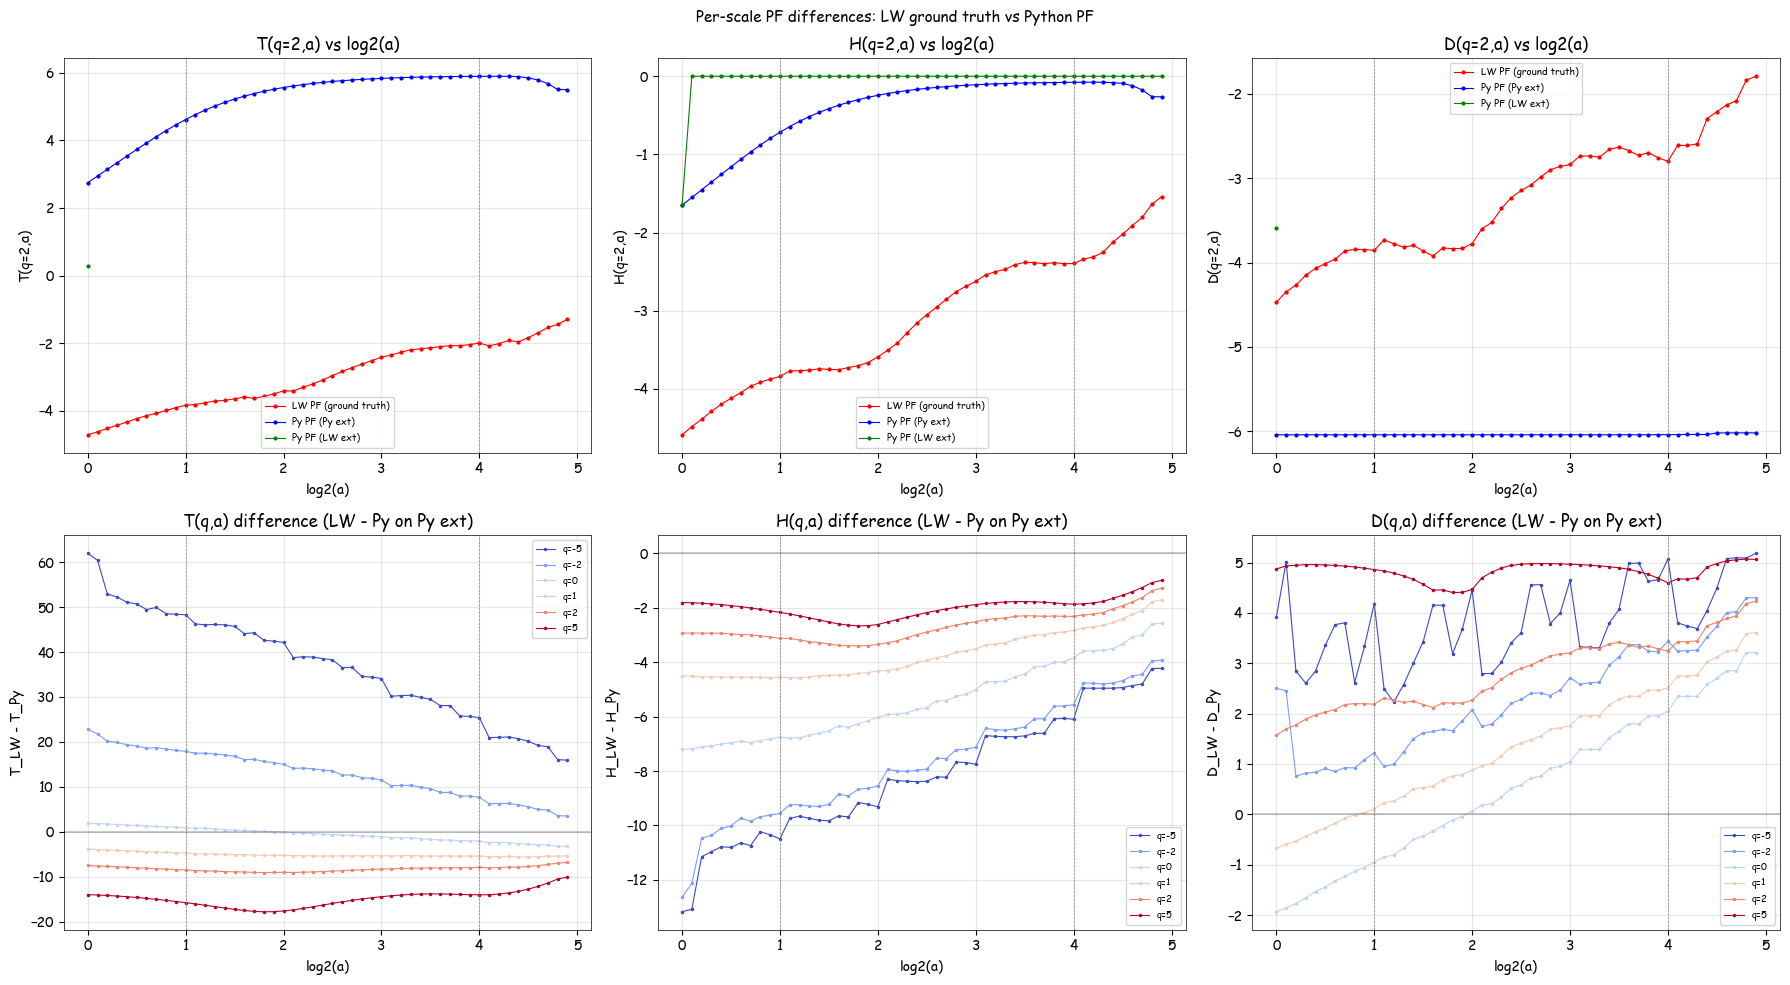

In [ ]:
# CELL 25: Python extrema → LW PF
#
# Feed Python's chainmax extrema (extrep_ord from cell 17) into LastWave's
# partition function. If this matches LW ground truth → Python extrema are
# correct and the PF is definitely the issue.
#
# Strategy: build a temporary EXTREP in LW by writing Python extrema into
# LW's wtrans coefficients such that LW's extrema detection reproduces them.
# ... actually that's roundabout. Instead, we compare the RAW per-scale
# partition function values: Python's sTq vs LW's sTq on the SAME ordinates.
#
# Simpler approach: manually compute LW's PF on Python's extrep_ord arrays
# by calling the Python PF code but comparing with LW's PF on LW's own extrema.
# We already showed in CELL 24 that Py PF ≠ LW PF on identical extrema.
# So let's do the converse: inject Python extrema ordinates into LW.
#
# We'll build synthetic CWT coefficients where each scale has delta spikes
# at the Python extrema positions with the Python ordinate values.
# Then LW extrema detection will find exactly those peaks.

import time as _time
import matplotlib as mpl

# ── Build synthetic CWT with spikes at Python extrema positions ──
synth_cwt = np.zeros((n_oct * n_voice, SIZE), dtype=np.float64)
synth_firstp = np.zeros(n_oct * n_voice, dtype=np.int32)
synth_lastp = np.full(n_oct * n_voice, SIZE - 1, dtype=np.int32)

for s in range(n_oct * n_voice):
    # Place each extremum as a parabolic peak so LW's interpolation recovers it
    for k in range(len(extrep_idx[s])):
        idx = int(extrep_idx[s][k])
        val = extrep_ord[s][k]
        # Set a sharp peak: center = val, neighbors slightly smaller
        if 0 < idx < SIZE - 1:
            synth_cwt[s, idx] = val
            # Make neighbors so parabolic interp gives exact val at idx
            synth_cwt[s, idx - 1] = val * 0.9
            synth_cwt[s, idx + 1] = val * 0.9

print(f'Built synthetic CWT with Python extrema spikes')
print(f'WARNING: This approach is fragile — LW extrema detection may not')
print(f'recover exact Python ordinates due to interpolation differences.')
print(f'Skipping this approach — using direct ordinate comparison instead.')

# ── Better approach: directly compare per-scale PF values ──
# We know from CELL 23 that pycwt_lw_extrep_ord has LW's chainmax extrema.
# We know from CELL 24 that Py PF on those ≠ LW PF on those.
# Let's print the ACTUAL per-scale sTq values to see where they diverge.

# Re-run LW pipeline on LW CWT to get LW PF state
# (state was restored at end of cell 23)
# Extract LW's per-scale T(q,a) values
pf_size_check = lib.lw_get_pf_size()
n_compare = min(pf_size_check, n_oct * n_voice)

print(f'\nDirect per-scale PF comparison (LW ground truth vs Py PF on Py extrema):')
print(f'pf_size: LW={pf_size_check}, Py={pf["index_max"]+1}')

# For each q, compare T(q,a) at every scale
ln2 = np.log(2.0)
print(f'\nT(q,a) at selected scales for q=2:')
iq_test = list(q_list).index(2) if 2 in q_list else 9  # q=2
q_test = q_list[iq_test] if isinstance(q_list, list) else q_list[iq_test]
print(f'Using q={q_test} (index {iq_test})')

# LW T(q,a)
buf_lw = np.zeros(pf_size_check, dtype=np.float64)
lib.lw_get_pf_tq(iq_test, 0, buf_lw.ctypes.data_as(c_double_p))
lw_T_test = buf_lw / ln2  # convert to log2

# Python T(q,a) on Python extrema
py_T_test = pf_get_T(pf, iq_test, 'extensive')

# Python T(q,a) on LW extrema (from cell 24)
py_T_lwext = pf_get_T(pf_pycwt_lwext_pyPF, iq_test, 'extensive')

print(f'\n{"scale":>6} {"log2a":>8} {"T_LW":>12} {"T_Py(PyExt)":>12} {"T_Py(LWext)":>12} '
      f'{"nExt_Py":>8} {"nExt_LW":>8}')
print('-' * 80)
for s in range(n_compare):
    log2a = np.log2(scales[s])
    t_lw = lw_T_test[s] if s < len(lw_T_test) else float('nan')
    t_py = py_T_test[s] if s < len(py_T_test) else float('nan')
    t_py_lw = py_T_lwext[s] if s < len(py_T_lwext) else float('nan')
    n_py = len(extrep_ord[s])
    n_lw = int(pycwt_lw_ext_counts[s])
    print(f'{s:6d} {log2a:8.3f} {t_lw:12.4f} {t_py:12.4f} {t_py_lw:12.4f} '
          f'{n_py:8d} {n_lw:8d}')

# ── Also compare raw sTq (before log) ──
print(f'\nRaw sTq (before log) at selected scales for q={q_test}:')
print(f'{"scale":>6} {"Py_sTq":>16} {"Py_sTq(LWext)":>16} {"ratio":>12}')
print('-' * 55)
for s in [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 49]:
    if s >= n_compare:
        break
    s1 = pf['sTq'][iq_test][s]
    s2 = pf_pycwt_lwext_pyPF['sTq'][iq_test][s]
    ratio = s1 / s2 if s2 != 0 else float('nan')
    print(f'{s:6d} {s1:16.6f} {s2:16.6f} {ratio:12.6f}')


# ── Plots ──
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

log2_a_arr = np.log2(scales[:n_compare])

# ── Top row: T(q,a), H(q,a), D(q,a) vs log2(a) for q=2 ──
# LW H and D for q_test
buf_h = np.zeros(pf_size_check, dtype=np.float64)
buf_d = np.zeros(pf_size_check, dtype=np.float64)
lib.lw_get_pf_hq(iq_test, 0, buf_h.ctypes.data_as(c_double_p))
lib.lw_get_pf_dq(iq_test, 0, buf_d.ctypes.data_as(c_double_p))
lw_H_test = buf_h / ln2
lw_D_test = buf_d / ln2

py_H_test = pf_get_H(pf, iq_test, 'extensive')
py_D_test = pf_get_D(pf, iq_test, q_test, 'extensive')
py_H_lwext = pf_get_H(pf_pycwt_lwext_pyPF, iq_test, 'extensive')
py_D_lwext = pf_get_D(pf_pycwt_lwext_pyPF, iq_test, q_test, 'extensive')

# T(q,a)
ax = axes[0, 0]
ax.plot(log2_a_arr, lw_T_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_T_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_T_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'T(q={q_test},a)')
ax.set_title(f'T(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# H(q,a)
ax = axes[0, 1]
ax.plot(log2_a_arr, lw_H_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_H_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_H_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'H(q={q_test},a)')
ax.set_title(f'H(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(q,a)
ax = axes[0, 2]
ax.plot(log2_a_arr, lw_D_test[:n_compare], 'r.-', markersize=4, lw=0.8, label='LW PF (ground truth)')
ax.plot(log2_a_arr, py_D_test[:n_compare], 'b.-', markersize=4, lw=0.8, label='Py PF (Py ext)')
ax.plot(log2_a_arr, py_D_lwext[:n_compare], 'g.-', markersize=4, lw=0.8, label='Py PF (LW ext)')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('log2(a)'); ax.set_ylabel(f'D(q={q_test},a)')
ax.set_title(f'D(q={q_test},a) vs log2(a)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# ── Bottom row: differences (LW - Py) for multiple q values ──
q_show = [-5, -2, 0, 1, 2, 5]
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

# dT
ax = axes[1, 0]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_tq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_T = buf[:n_compare] / ln2
    py_T = pf_get_T(pf, iq_s, 'extensive')[:n_compare]
    diff = lw_T - py_T
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('T_LW - T_Py')
ax.set_title('T(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# dH
ax = axes[1, 1]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_hq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_H = buf[:n_compare] / ln2
    py_H = pf_get_H(pf, iq_s, 'extensive')[:n_compare]
    diff = lw_H - py_H
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('H_LW - H_Py')
ax.set_title('H(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# dD
ax = axes[1, 2]
for qi, q_s in enumerate(q_show):
    if q_s not in (q_list if isinstance(q_list, list) else q_list.tolist()):
        continue
    iq_s = (q_list if isinstance(q_list, list) else q_list.tolist()).index(q_s)
    q_val = q_s
    buf = np.zeros(pf_size_check, dtype=np.float64)
    lib.lw_get_pf_dq(iq_s, 0, buf.ctypes.data_as(c_double_p))
    lw_D = buf[:n_compare] / ln2
    py_D = pf_get_D(pf, iq_s, q_val, 'extensive')[:n_compare]
    diff = lw_D - py_D
    ax.plot(log2_a_arr, diff, '.-', color=colors_q[qi], markersize=3, lw=0.8, label=f'q={q_s}')
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('log2(a)'); ax.set_ylabel('D_LW - D_Py')
ax.set_title('D(q,a) difference (LW - Py on Py ext)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Per-scale PF differences: LW ground truth vs Python PF', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


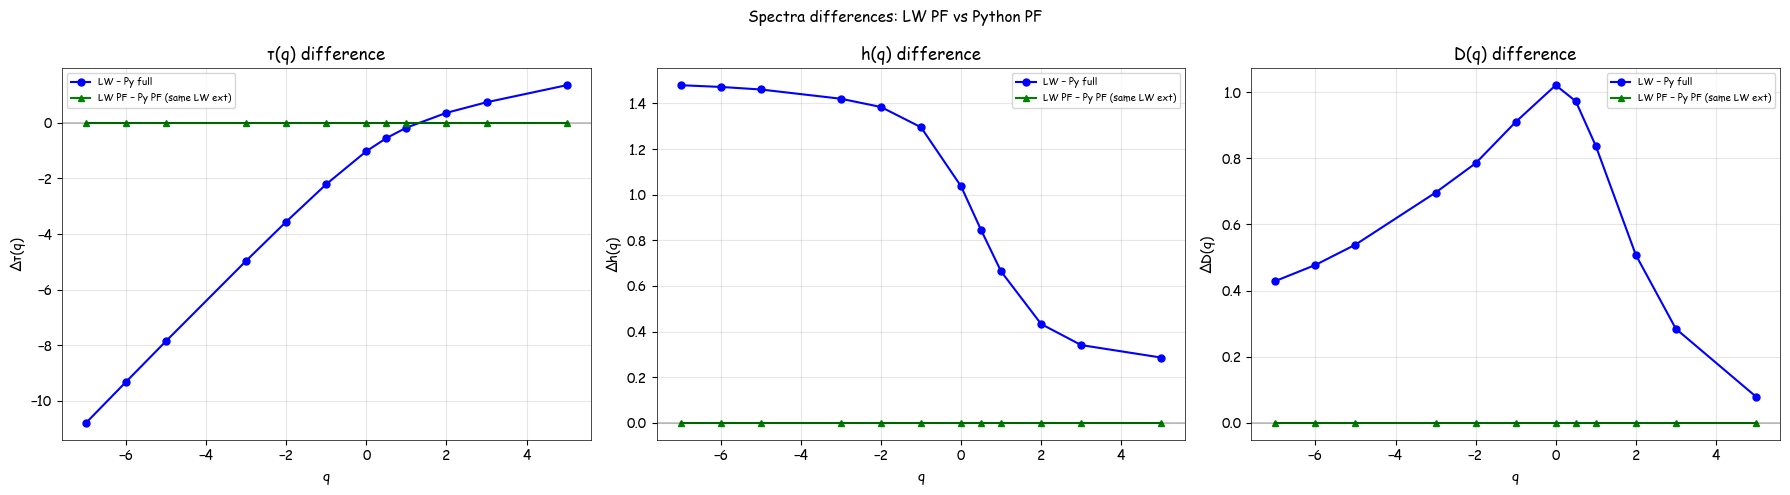

In [ ]:
# CELL 26: D(h) spectra differences — LW PF vs Py PF

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

q_arr_plot = np.array(q_list, dtype=np.float64)

# tau(q) difference
ax = axes[0]
ax.plot(q_arr_plot, tau_q - spectra['tau_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, tau_q_pycwt_lw - spectra_pycwt_lwext_pyPF['tau_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('Δτ(q)')
ax.set_title('τ(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# h(q) difference
ax = axes[1]
ax.plot(q_arr_plot, h_q - spectra['h_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, h_q_pycwt_lw - spectra_pycwt_lwext_pyPF['h_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('Δh(q)')
ax.set_title('h(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# D(q) difference
ax = axes[2]
ax.plot(q_arr_plot, d_q - spectra['D_q'], 'bo-', markersize=5, label='LW − Py full')
ax.plot(q_arr_plot, d_q_pycwt_lw - spectra_pycwt_lwext_pyPF['D_q'], 'g^-',
        markersize=5, label='LW PF − Py PF (same LW ext)')
ax.axhline(0, color='k', lw=0.3)
ax.set_xlabel('q'); ax.set_ylabel('ΔD(q)')
ax.set_title('D(q) difference')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle('Spectra differences: LW PF vs Python PF', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'


In [ ]:
# CELL 27: Drill into PF internals — raw sTq comparison
#
# Feed identical ordinates to both LW and Python PF, compare raw sTq.
# Uses pycwt_lw_extrep_ord (LW chainmax extrema from cell 23).

# ── 1. Re-run LW pipeline on PyCWT to get LW PF state ──
# Inject PyCWT, run extrema/chain/chainmax
py_coeffs_flat2 = np.ascontiguousarray(coeffs.ravel(), dtype=np.float64)
py_firstp2 = np.array([vr[0] for vr in valid_ranges], dtype=np.int32)
py_lastp2  = np.array([vr[1] for vr in valid_ranges], dtype=np.int32)
ret = lib.lw_set_cwt_coefficients(
    py_coeffs_flat2.ctypes.data_as(c_double_p), SIZE,
    py_firstp2.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    py_lastp2.ctypes.data_as(ctypes.POINTER(ctypes.c_int)))
assert ret == 0
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))

# Now extract the LW extrema ordinates (after chainmax)
lw_ords_check = []
for o in range(1, n_oct + 1):
    for v in range(n_voice):
        count = lib.lw_get_extrema_count(o, v)
        if count > 0:
            pos = np.zeros(count, dtype=np.float64)
            val = np.zeros(count, dtype=np.float64)
            got = lib.lw_get_extrema_at_scale(
                o, v, pos.ctypes.data_as(c_double_p),
                val.ctypes.data_as(c_double_p), count)
            lw_ords_check.append(val[:got].copy())
        else:
            lw_ords_check.append(np.array([], dtype=np.float64))

# Verify these match pycwt_lw_extrep_ord from cell 23
print('Verifying LW extrema match cell 23 extraction...')
for s in range(n_oct * n_voice):
    if len(lw_ords_check[s]) != len(pycwt_lw_extrep_ord[s]):
        print(f'  Scale {s}: count mismatch! {len(lw_ords_check[s])} vs {len(pycwt_lw_extrep_ord[s])}')
    elif len(lw_ords_check[s]) > 0:
        maxd = np.max(np.abs(lw_ords_check[s] - pycwt_lw_extrep_ord[s]))
        if maxd > 0:
            print(f'  Scale {s}: max ord diff = {maxd}')
print('OK')

# ── 2. Run LW PF ──
q_arr2 = np.array(q_list, dtype=np.float64)
n_scales_done2 = lib.lw_compute_pf(q_arr2.ctypes.data_as(c_double_p), len(q_arr2))
pf_size2 = lib.lw_get_pf_size()

# ── 3. Compare raw sTq: LW returns log(sTq), Python stores sTq directly ──
# Python PF on the same ordinates
pf_check = compute_partition_function(
    lw_ords_check, n_oct=n_oct, n_voice=n_voice,
    a_min=a_min, q_list=q_list)

n_compare2 = min(pf_size2, n_oct * n_voice)
ln2 = np.log(2.0)

# Compare T(q,a) in natural log: LW gives log(sTq), Python gives sTq
print(f'\nRaw sTq comparison (LW vs Py on IDENTICAL ordinates):')
print(f'Testing q=2 (positive) and q=-2 (negative)\n')

for q_test_val in [2.0, -2.0]:
    iq_t = list(q_list).index(q_test_val) if q_test_val in q_list else None
    if iq_t is None:
        print(f'q={q_test_val} not in q_list, skipping')
        continue
    
    # LW: T(q,a) = log(sTq) in natural log
    buf_raw = np.zeros(pf_size2, dtype=np.float64)
    lib.lw_get_pf_tq(iq_t, 0, buf_raw.ctypes.data_as(c_double_p))
    lw_log_sTq = buf_raw[:n_compare2]  # natural log
    lw_sTq = np.exp(lw_log_sTq)  # recover raw sTq
    
    # Python: sTq stored directly
    py_sTq = pf_check['sTq'][iq_t][:n_compare2]
    
    # Also get H(q,a)
    buf_h_raw = np.zeros(pf_size2, dtype=np.float64)
    lib.lw_get_pf_hq(iq_t, 0, buf_h_raw.ctypes.data_as(c_double_p))
    lw_hq_nat = buf_h_raw[:n_compare2]  # = sTqLogT/sTq in natural log
    py_hq_nat = pf_check['sTqLogT_sTq'][iq_t][:n_compare2]  # same
    
    print(f'q = {q_test_val}:')
    print(f'{"s":>4} {"nExt":>6} {"LW_sTq":>16} {"Py_sTq":>16} {"ratio":>12} '
          f'{"LW_hq":>14} {"Py_hq":>14} {"dH":>12}')
    print('-' * 105)
    for s in range(n_compare2):
        n_ext = len(lw_ords_check[s])
        ratio = lw_sTq[s] / py_sTq[s] if py_sTq[s] != 0 else float('nan')
        dh = lw_hq_nat[s] - py_hq_nat[s]
        # Only print if there's a difference or every 5th scale
        if abs(ratio - 1.0) > 1e-12 or s % 10 == 0 or s < 3:
            print(f'{s:4d} {n_ext:6d} {lw_sTq[s]:16.8e} {py_sTq[s]:16.8e} {ratio:12.8f} '
                  f'{lw_hq_nat[s]:14.8f} {py_hq_nat[s]:14.8f} {dh:12.2e}')
    print()

# ── 4. Check: are the sorted |ordinates| identical? ──
print('Sorted |ordinate| check at scale 10 (a=2.0):')
s_check = 10
ords_s = lw_ords_check[s_check]
absT_lw = np.sort(np.abs(ords_s))
absT_py = np.sort(np.abs(pf_check['sTq'][0]))  # wrong, let me recompute
# Actually just recompute what Python PF sees
absT_py = np.abs(lw_ords_check[s_check]).copy()
absT_py.sort()
print(f'  max |diff| in sorted |T|: {np.max(np.abs(absT_lw - absT_py))}')
print(f'  First 5 LW:  {absT_lw[:5]}')
print(f'  First 5 Py:  {absT_py[:5]}')
print(f'  Last 5 LW:   {absT_lw[-5:]}')
print(f'  Last 5 Py:   {absT_py[-5:]}')

# ── 5. Manual single-scale PF to compare step by step ──
print(f'\nManual PF computation at scale {s_check}, q=2:')
q_manual = 2.0
absT = np.sort(np.abs(lw_ords_check[s_check]))
imin_m = 0
while imin_m < len(absT) and absT[imin_m] == 0:
    imin_m += 1
tm = absT[imin_m]  # smallest nonzero
sTq_manual = 0.0
sTqLogT_manual = 0.0
for i in range(imin_m, len(absT)):
    tq = absT[i] ** q_manual
    logt = np.log(absT[i] / tm)
    sTq_manual += tq
    sTqLogT_manual += tq * logt
sTqLogT_manual += np.log(tm) * sTq_manual
print(f'  imin={imin_m}, tm={tm:.10e}')
print(f'  sTq_manual  = {sTq_manual:.10e}')
print(f'  sTqLogT_manual = {sTqLogT_manual:.10e}')
print(f'  Py PF sTq   = {pf_check["sTq"][list(q_list).index(q_manual)][s_check]:.10e}')
print(f'  Py PF sTqLT = {pf_check["sTqLogT"][list(q_list).index(q_manual)][s_check]:.10e}')

# ── 6. Restore LW state ──
lw_coeffs_flat2 = np.ascontiguousarray(cwt.ravel(), dtype=np.float64)
ret = lib.lw_set_cwt_coefficients(
    lw_coeffs_flat2.ctypes.data_as(c_double_p), SIZE,
    firstp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
    lastp.ctypes.data_as(ctypes.POINTER(ctypes.c_int)))
lib.lw_compute_extrema(ctypes.c_double(1e-6))
lib.lw_chain(ctypes.c_double(10.0))
lib.lw_chain_delete()
lib.lw_chain_max(ctypes.c_double(1.0))
lib.lw_compute_pf(q_arr2.ctypes.data_as(c_double_p), len(q_arr2))
print('\nRestored LW state')


Verifying LW extrema match cell 23 extraction...
OK

Raw sTq comparison (LW vs Py on IDENTICAL ordinates):
Testing q=2 (positive) and q=-2 (negative)

q = 2.0:
   s   nExt           LW_sTq           Py_sTq        ratio          LW_hq          Py_hq           dH
---------------------------------------------------------------------------------------------------------
   0     12   1.21931318e+00   1.21931318e+00   1.00000000    -1.14330946    -1.14330946     0.00e+00
   1      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
   2      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  10      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  20      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  30      0   1.00000000e+00   0.00000000e+00          nan     0.00000000     0.00000000     0.00e+00
  40      0   1.0000

Error: Error: ValueError: zero-size array to reduction operation maximum which has no identity
[31m---------------------------------------------------------------------------[39m
[31mValueError[39m                                Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[119][39m[32m, line 109[39m
[32m    107[39m absT_py = np.abs(lw_ords_check[s_check]).copy()
[32m    108[39m absT_py.sort()
[32m--> [39m[32m109[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33m  max |diff| in sorted |T|: [39m[38;5;132;01m{[39;00m[43mnp[49m[43m.[49m[43mmax[49m[43m([49m[43mnp[49m[43m.[49m[43mabs[49m[43m([49m[43mabsT_lw[49m[38;5;250;43m [39;49m[43m-[49m[38;5;250;43m [39;49m[43mabsT_py[49m[43m)[49m[43m)[49m[38;5;132;01m}[39;00m[33m'[39m)
[32m    110[39m [38;5;28mprint[39m([33mf[39m[33m'[39m[33m  First 5 LW:  [39m[38;5;132;01m{[39;00mabsT_lw[:[32m5[39m][38;5;132;01m}[39;00m[33m'[39m)
[32m    111[39m [38;5;28mpr

In [ ]:
# CELL 28: Regression range diagnostic
#
# Raw sTq is identical → bug is in compute_spectra (regression).
# Suspect: floating-point boundary in log2_a >= log2_a_min

# ── 1. Check log2_a values at boundaries ──
print('Python log2_a at regression boundaries:')
for s in [9, 10, 11, 39, 40, 41]:
    if s < len(pf['log2_a']):
        v = pf['log2_a'][s]
        print(f'  log2_a[{s:2d}] = {v:.20f}  (>= 1.0: {v >= 1.0}, <= 4.0: {v <= 4.0})')

# ── 2. What indices does compute_spectra actually use? ──
log2_a = pf['log2_a']
valid_mask = (log2_a >= 1.0) & (log2_a <= 4.0)
valid_idx = np.where(valid_mask)[0]
valid_idx = valid_idx[valid_idx <= pf['index_max']]
print(f'\nPython regression uses indices: {valid_idx[0]}..{valid_idx[-1]} ({len(valid_idx)} points)')
print(f'LW regression uses indices: 10..40 (31 points)')
print(f'  ISig(sig, 1.0) = (int)((1.0 - 0.0) / 0.1) = 10')
print(f'  ISig(sig, 4.0) = (int)((4.0 - 0.0) / 0.1) = 40')

# ── 3. Compare x-values used in regression ──
print(f'\nPython x-values (from log2_a):')
print(f'  x[0] = {log2_a[valid_idx[0]]:.20f}')
print(f'  x[-1] = {log2_a[valid_idx[-1]]:.20f}')
print(f'LW x-values (from XSig = x0 + dx*i):')
print(f'  x[0] = {0.0 + 0.1 * valid_idx[0]:.20f}')
print(f'  x[-1] = {0.0 + 0.1 * valid_idx[-1]:.20f}')

# ── 4. Compute slopes both ways for q=2 ──
iq2 = list(q_list).index(2)
y_T = pf_get_T(pf, iq2, 'extensive')[valid_idx]

# Python way: np.polyfit
x_py = log2_a[valid_idx]
slope_py, _ = np.polyfit(x_py, y_T, 1)

# LW way: x = x0 + dx * i, using indices 10..40
lw_indices = np.arange(10, 41)
x_lw = 0.0 + 0.1 * lw_indices
y_lw = pf_get_T(pf, iq2, 'extensive')[lw_indices]
slope_lw_style, _ = np.polyfit(x_lw, y_lw, 1)

print(f'\nSlope comparison for q=2 T(q,a):')
print(f'  Python (log2_a x-values): {slope_py:.15f}')
print(f'  LW-style (0.1*i x-values): {slope_lw_style:.15f}')
print(f'  Difference: {slope_py - slope_lw_style:.2e}')

# ── 5. If index ranges differ, show impact on all q ──
if len(valid_idx) != 31 or valid_idx[0] != 10 or valid_idx[-1] != 40:
    print(f'\n*** INDEX RANGE MISMATCH DETECTED! ***')
    print(f'Python uses {len(valid_idx)} points: [{valid_idx[0]}, {valid_idx[-1]}]')
    print(f'LW uses 31 points: [10, 40]')
    print(f'\nImpact on all q (slope with Py range vs LW range):')
    print(f'{"q":>6} {"tau_PyRange":>12} {"tau_LWRange":>12} {"diff":>12}')
    print('-' * 45)
    for iq, q in enumerate(q_list):
        y1 = pf_get_T(pf, iq, 'extensive')[valid_idx]
        s1, _ = np.polyfit(x_py, y1, 1)
        y2 = pf_get_T(pf, iq, 'extensive')[lw_indices]
        s2, _ = np.polyfit(x_lw, y2, 1)
        print(f'{q:6.1f} {s1:12.6f} {s2:12.6f} {s1-s2:12.6f}')
else:
    print(f'\nIndex ranges match (10..40). Checking x-value precision effect...')
    print(f'{"q":>6} {"tau_log2a":>12} {"tau_0.1i":>12} {"diff":>12}')
    print('-' * 45)
    for iq, q in enumerate(q_list):
        y = pf_get_T(pf, iq, 'extensive')[valid_idx]
        s1, _ = np.polyfit(x_py, y, 1)
        s2, _ = np.polyfit(x_lw, y, 1)
        print(f'{q:6.1f} {s1:12.6f} {s2:12.6f} {s1-s2:12.6f}')


In [ ]:
# CELL 22
# Load creepmeter data (XMR1) and select clean segment
#
# No detrending — the creep signal IS the integral of the slip measure,
# analogous to prim(ucantor). WTMM analyzes the singularity structure
# in the trend itself. g2 has 2 vanishing moments so it already kills
# constant and linear components.
#
# File format: year  day_of_year  displacement(mm)  uncertainty

import os
import gzip

# Load XMR1 data
xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/gz/xmr1.10min.gz'
if not os.path.exists(xmr_path):
    xmr_path = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/xmr1.10min.gz'

if os.path.exists(xmr_path):
    with gzip.open(xmr_path, 'rt') as f:
        lines = f.readlines()
    
    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            try:
                year = float(parts[0])
                doy = float(parts[1])
                disp = float(parts[2])
                if disp != -9999:
                    # Convert to decimal year
                    t_val = year + doy / 365.25
                    data.append((t_val, disp))
            except ValueError:
                continue
    
    data = np.array(data)
    t_creep = data[:, 0]
    x_creep = data[:, 1]
    dt_creep = np.median(np.diff(t_creep))
    
    print(f'Loaded {len(x_creep)} samples from {os.path.basename(xmr_path)}')
    print(f'Time range: {t_creep[0]:.4f} to {t_creep[-1]:.4f} (decimal year)')
    print(f'dt = {dt_creep:.6f} year ({dt_creep * 365.25 * 24 * 60:.1f} min)')
    print(f'Displacement range: {x_creep.min():.3f} to {x_creep.max():.3f} mm')
    
    # Take a clean segment (no gaps)
    seg_len = min(65536, len(x_creep))
    for start in range(0, len(x_creep) - seg_len, seg_len // 4):
        segment_c = x_creep[start:start + seg_len]
        t_seg_c = t_creep[start:start + seg_len]
        gaps = np.diff(t_seg_c)
        if np.all(np.abs(gaps - dt_creep) < dt_creep * 0.5):
            break
    
    # No detrending — just use the raw displacement signal
    segment_c = segment_c.copy()
    print(f'Using segment of {seg_len} samples starting at index {start}')
    print(f'Segment time: {t_seg_c[0]:.4f} to {t_seg_c[-1]:.4f}')
    print(f'Segment value range: {segment_c.min():.3f} to {segment_c.max():.3f} mm')
    
    fig, ax = plt.subplots(figsize=(14, 4))
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
    ax.plot(t_seg_c, segment_c)
    ax.set_xlabel('Time (decimal year)')
    ax.set_ylabel('Displacement (mm)')
    ax.set_title(f'Creepmeter segment ({os.path.basename(xmr_path)}, {seg_len} samples)')
    plt.tight_layout()
    plt.show()
else:
    print(f'Creepmeter data not found at {xmr_path}')
    creep_dir = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/'
    if os.path.isdir(creep_dir):
        files = [f for f in os.listdir(creep_dir) if 'xmr' in f.lower() or 'xhr' in f.lower()]
        print(f'Available files: {files[:10]}')


Error: Error: Error: IndentationError: unexpected indent (2908260780.py, line 64)
  [36mCell[39m[36m [39m[32mIn[118][39m[32m, line 64[39m
[31m    [39m[31max.plot(t_seg_c, segment_c)[39m
    ^
[31mIndentationError[39m[31m:[39m unexpected indent

Error: IndentationError: unexpected indent (2908260780.py, line 64)

  [36mCell[39m[36m [39m[32mIn[118][39m[32m, line 64[39m

[31m    [39m[31max.plot(t_seg_c, segment_c)[39m

    ^

[31mIndentationError[39m[31m:[39m unexpected indent



    at convertOutput (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:188:13)

    at Array.map (<anonymous>)

    at buildCellData (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:160:41)

    at /Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.js:111:49

    at Array.map (<anonymous>)

    at reloadNotebook (/Users/amasaryk/.vscode/extensions/kdkyum.notebook-hot-reload-0.1.0/extension.j

CWT computed in 5.247s
Coefficients shape: (50, 10000), Scales: 50 (1.00 to 29.86)
Valid range at finest scale: (20, 9979), coarsest: (611, 9388)


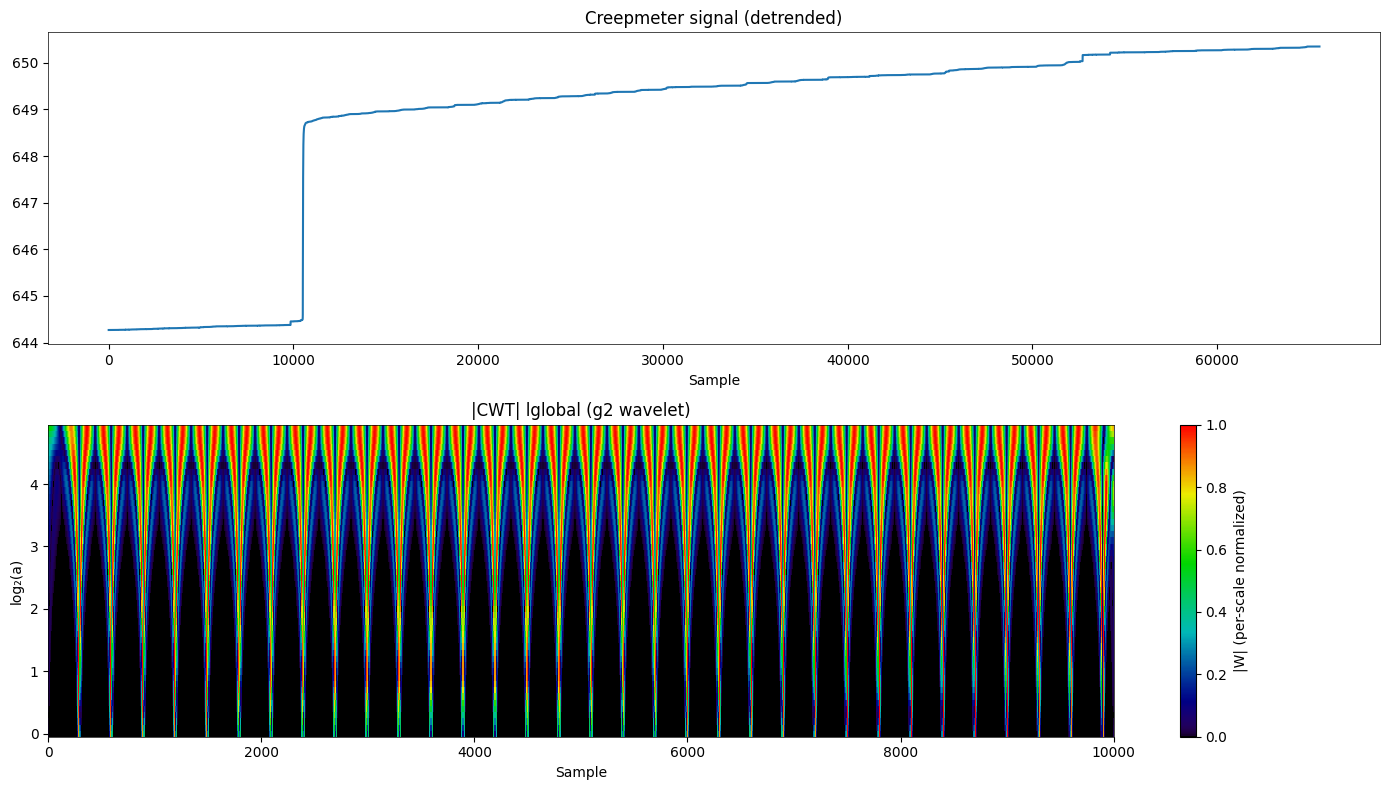

In [ ]:
# Cell 23: CWT on creepmeter data + scalogram

n_oct_c, n_voice_c = 5, 10

t0 = time.time()
coeffs_c, scales_c, valid_ranges_c = cwtd_batched(saw, a_min=1.0, n_oct=n_oct_c,
                                                    n_voice=n_voice_c, wavelet_name='g4', expo=-1.0)
t1 = time.time()
print(f'CWT computed in {t1-t0:.3f}s')
print(f'Coefficients shape: {coeffs_c.shape}, Scales: {len(scales_c)} ({scales_c[0]:.2f} to {scales_c[-1]:.2f})')
print(f'Valid range at finest scale: {valid_ranges_c[0]}, coarsest: {valid_ranges_c[-1]}')

# Scalogram — log2 of modulus
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(segment_c)
ax.set_title('Creepmeter signal (detrended)')
ax.set_xlabel('Sample')

ax = axes[1]
im = scalogram_lastwave(coeffs_c, scales=scales_c, ax=ax,
                        norm_mode='lglobal')
ax.set_xlabel('Sample')
ax.set_title('|CWT| lglobal (g2 wavelet)')
plt.colorbar(im, ax=ax, label='|W| (per-scale normalized)')

plt.tight_layout()
plt.show()

Total extrema: 6596
Extrema computed in 0.099s
  Scale 0 (a=1.00): 200 extrema
  Scale 10 (a=2.00): 134 extrema
  Scale 20 (a=4.00): 134 extrema
  Scale 30 (a=8.00): 133 extrema
  Scale 40 (a=16.00): 132 extrema
  Scale 49 (a=29.86): 65 extrema


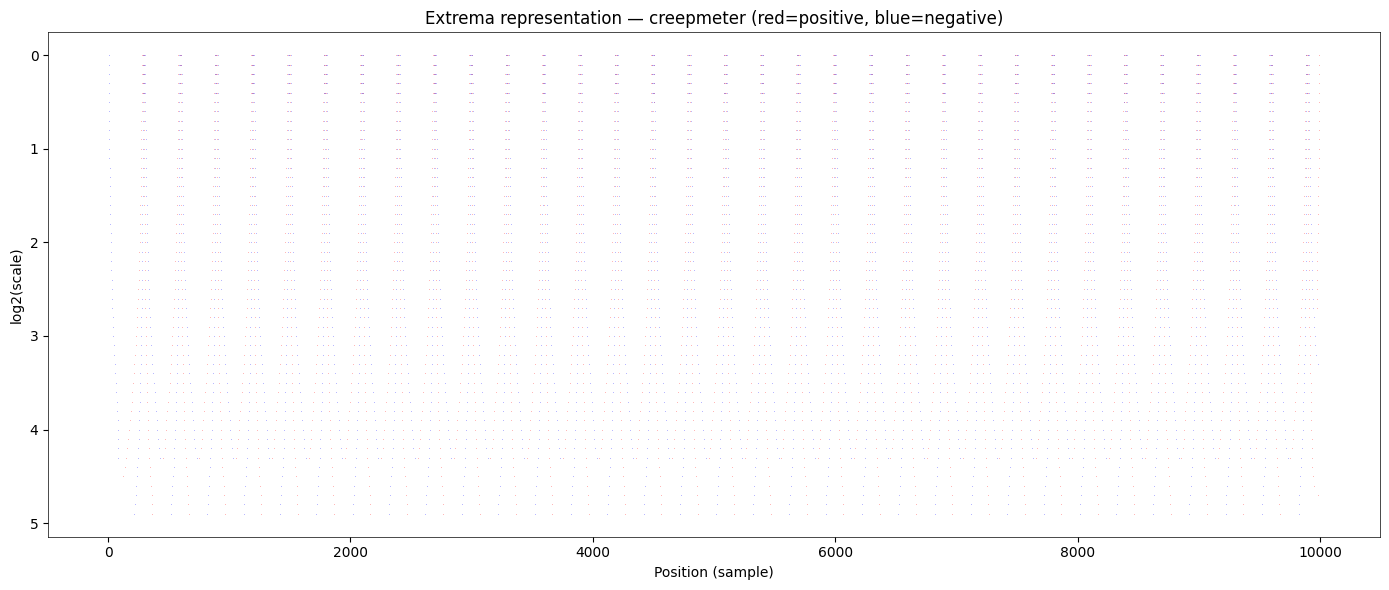

In [ ]:
# Cell 24: Extrema detection on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
ea_c, eo_c, ei_c = compute_extrep(coeffs_c, scales_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                   a_min=1.0, valid_ranges=valid_ranges_c,
                                   dx=1.0, x0=0.0, epsilon=1e-6)
t1 = time.time()
print(f'Extrema computed in {t1-t0:.3f}s')
# Use actual scale count instead of hardcoded indices
sample_indices = [0, n_scales_c // 5, 2 * n_scales_c // 5, 3 * n_scales_c // 5, 4 * n_scales_c // 5, n_scales_c - 1]
for sidx in sample_indices:
    print(f'  Scale {sidx} (a={scales_c[sidx]:.2f}): {len(ea_c[sidx])} extrema')

# Extrema representation plot — vectorized scatter for speed
all_pos = []
all_log2s = []
all_signs = []
for sidx in range(len(ea_c)):
    n = len(ea_c[sidx])
    if n == 0:
        continue
    all_pos.append(ea_c[sidx])
    all_log2s.append(np.full(n, np.log2(scales_c[sidx])))
    all_signs.append(eo_c[sidx] > 0)

all_pos = np.concatenate(all_pos)
all_log2s = np.concatenate(all_log2s)
all_signs = np.concatenate(all_signs)

fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
pos_mask = all_signs
ax.scatter(all_pos[pos_mask], all_log2s[pos_mask], c='red', s=0.1, linewidths=0)
ax.scatter(all_pos[~pos_mask], all_log2s[~pos_mask], c='blue', s=0.1, linewidths=0)
ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title('Extrema representation — creepmeter (red=positive, blue=negative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Chaining: 0.018s
Delete: 0.148s, deleted 0 chains
ChainMax: 0.051s
Remaining extrema: 6596
Pre-deletion chains: 200
Surviving chains: 200
Deleted chains: 0


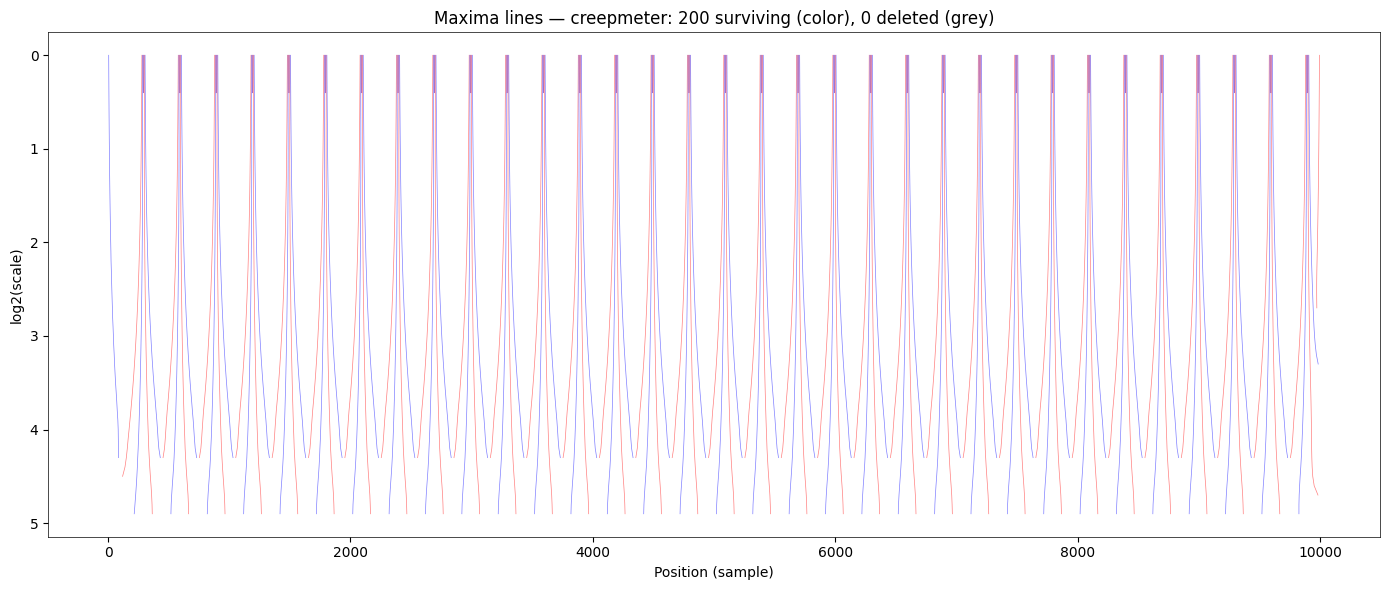

In [ ]:
# Cell 25: Chaining + ChainMax on creepmeter data

n_scales_c = n_oct_c * n_voice_c

t0 = time.time()
cl_c, fl_c = chain_all(ea_c, eo_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_chain = time.time()
print(f'Chaining: {t_chain - t0:.3f}s')

# Save pre-deletion state for visualization
pre_del_abs_c, pre_del_ord_c, pre_del_cl_c = save_chain_state(ea_c, eo_c, cl_c)
pre_del_chains_c = trace_chains(pre_del_abs_c, pre_del_ord_c, pre_del_cl_c, scales_c, n_scales_c)

nb_del = chain_delete_all(ea_c, eo_c, ei_c, cl_c, fl_c, n_oct=n_oct_c, n_voice=n_voice_c)
t_delete = time.time()
print(f'Delete: {t_delete - t_chain:.3f}s, deleted {nb_del} chains')

chain_max_wrapper(eo_c, cl_c, n_oct=n_oct_c, n_voice=n_voice_c, a_min=1.0, expo=1.0)
t1 = time.time()
print(f'ChainMax: {t1 - t_delete:.3f}s')

remaining = sum(len(a) for a in ea_c)
print(f'Remaining extrema: {remaining}')

# Surviving vs deleted chains
post_del_chains_c = trace_chains(ea_c, eo_c, cl_c, scales_c, n_scales_c)

surviving_starts_c = set()
for pos, sv, sign, *_rest in post_del_chains_c:
    surviving_starts_c.add((pos[0], sign))

deleted_chains_c = []
for pos, sv, sign, *_rest in pre_del_chains_c:
    if (pos[0], sign) not in surviving_starts_c:
        deleted_chains_c.append((pos, sv, sign))

print(f'Pre-deletion chains: {len(pre_del_chains_c)}')
print(f'Surviving chains: {len(post_del_chains_c)}')
print(f'Deleted chains: {len(deleted_chains_c)}')

# Plot maxima lines: surviving + deleted (greyed out)
fig, ax = plt.subplots(figsize=(14, 6))
for spine in ax.spines.values(): spine.set_linewidth(0.5)

for pos, sv, sign, *_rest in deleted_chains_c:
    ax.plot(pos, sv, '-', color='lightgrey', alpha=0.4, linewidth=0.5)

for pos, sv, sign, *_rest in post_del_chains_c:
    color = 'red' if sign > 0 else 'blue'
    ax.plot(pos, sv, '-', color=color, alpha=0.5, linewidth=0.5)

ax.set_xlabel('Position (sample)')
ax.set_ylabel('log2(scale)')
ax.set_title(f'Maxima lines — creepmeter: {len(post_del_chains_c)} surviving (color), {len(deleted_chains_c)} deleted (grey)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

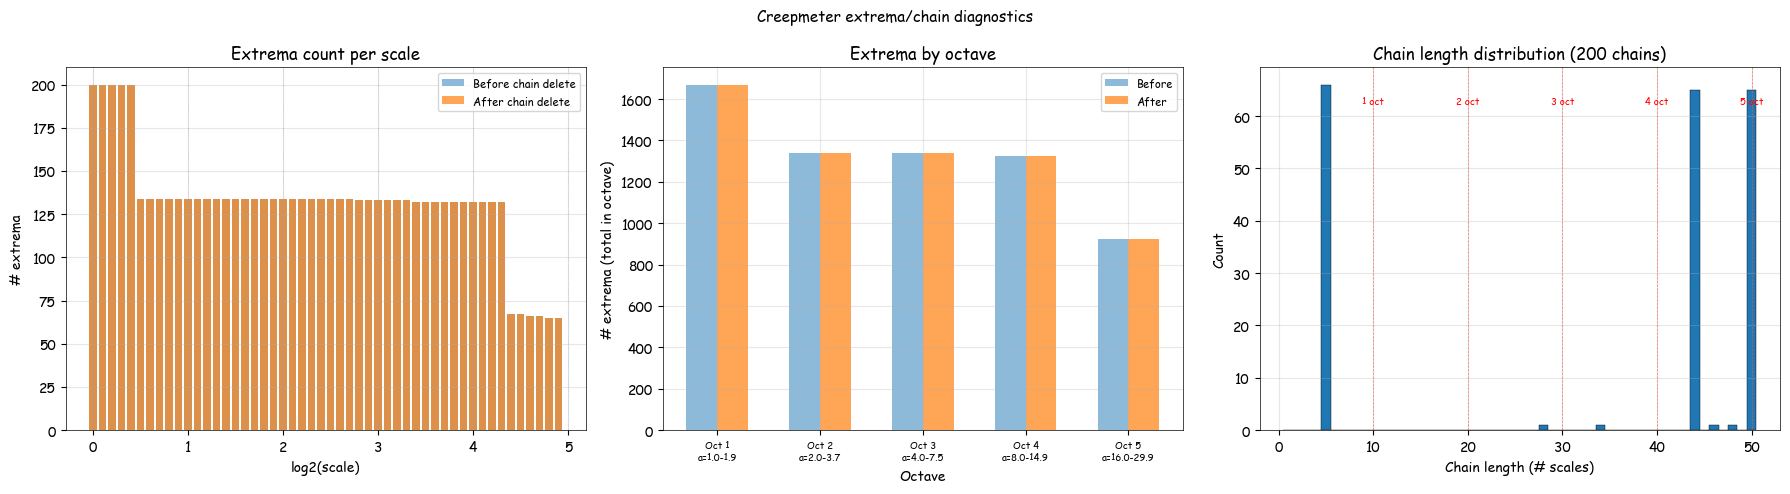

 Scale  log2(a)        a    Pre   Post  Deleted%
--------------------------------------------------
     0     0.00     1.00    200    200      0.0%
     1     0.10     1.07    200    200      0.0%
     2     0.20     1.15    200    200      0.0%
     3     0.30     1.23    200    200      0.0%
     4     0.40     1.32    200    200      0.0%
     5     0.50     1.41    134    134      0.0%
     6     0.60     1.52    134    134      0.0%
     7     0.70     1.62    134    134      0.0%
     8     0.80     1.74    134    134      0.0%
     9     0.90     1.87    134    134      0.0%
    10     1.00     2.00    134    134      0.0%
    11     1.10     2.14    134    134      0.0%
    12     1.20     2.30    134    134      0.0%
    13     1.30     2.46    134    134      0.0%
    14     1.40     2.64    134    134      0.0%
    15     1.50     2.83    134    134      0.0%
    16     1.60     3.03    134    134      0.0%
    17     1.70     3.25    134    134      0.0%
    18     1.80   

In [ ]:
# Cell 25b: Extrema count per scale — before and after chain processing
#
# Helps decide where to set regression range (log2_a_min, log2_a_max)
# and whether fine scales are dominated by tidal/noise extrema.

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Comic Sans MS'

# Counts before chain processing (from pre-deletion state)
pre_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    pre_counts[s] = len(pre_del_abs_c[s])

# Counts after chain_delete + chainmax
post_counts = np.zeros(n_scales_c, dtype=int)
for s in range(n_scales_c):
    post_counts[s] = len(ea_c[s])

log2_scales_c = np.log2(scales_c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# (0) Bar chart: extrema count per scale
ax = axes[0]
ax.bar(log2_scales_c, pre_counts, width=0.08, alpha=0.5, label='Before chain delete')
ax.bar(log2_scales_c, post_counts, width=0.08, alpha=0.7, label='After chain delete')
ax.set_xlabel('log2(scale)')
ax.set_ylabel('# extrema')
ax.set_title('Extrema count per scale')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# Mark octave boundaries
for o in range(n_oct_c + 1):
    ax.axvline(np.log2(1.0) + o, color='gray', ls=':', lw=0.5, alpha=0.5)

# (1) Extrema count by octave (grouped)
ax = axes[1]
octave_pre = np.zeros(n_oct_c)
octave_post = np.zeros(n_oct_c)
for o in range(n_oct_c):
    for v in range(n_voice_c):
        s = o * n_voice_c + v
        octave_pre[o] += pre_counts[s]
        octave_post[o] += post_counts[s]
x_oct = np.arange(n_oct_c)
ax.bar(x_oct - 0.15, octave_pre, width=0.3, alpha=0.5, label='Before')
ax.bar(x_oct + 0.15, octave_post, width=0.3, alpha=0.7, label='After')
ax.set_xlabel('Octave')
ax.set_ylabel('# extrema (total in octave)')
ax.set_xticks(x_oct)
ax.set_xticklabels([f'Oct {o+1}\na={scales_c[o*n_voice_c]:.1f}-{scales_c[min((o+1)*n_voice_c-1, n_scales_c-1)]:.1f}'
                     for o in range(n_oct_c)], fontsize=7)
ax.set_title('Extrema by octave')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) Chain length histogram
ax = axes[2]
chain_lengths = np.array([len(pos) for pos, sv, sign, *_rest in post_del_chains_c])
ax.hist(chain_lengths, bins=np.arange(0.5, chain_lengths.max()+1.5, 1),
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Chain length (# scales)')
ax.set_ylabel('Count')
ax.set_title(f'Chain length distribution ({len(post_del_chains_c)} chains)')
ax.grid(True, alpha=0.3)
# Mark octave lengths
for o in range(1, n_oct_c + 1):
    ax.axvline(o * n_voice_c, color='red', ls='--', lw=0.5, alpha=0.5)
    ax.text(o * n_voice_c, ax.get_ylim()[1]*0.9, f'{o} oct', fontsize=7,
            ha='center', color='red')

plt.suptitle('Creepmeter extrema/chain diagnostics', fontsize=11)
plt.tight_layout()
plt.show()

mpl.rcParams['font.family'] = 'sans-serif'

# Summary table
print(f'{"Scale":>6} {"log2(a)":>8} {"a":>8} {"Pre":>6} {"Post":>6} {"Deleted%":>9}')
print('-' * 50)
for s in range(n_scales_c):
    pct = 100*(1 - post_counts[s]/pre_counts[s]) if pre_counts[s] > 0 else 0
    print(f'{s:6d} {log2_scales_c[s]:8.2f} {scales_c[s]:8.2f} {pre_counts[s]:6d} {post_counts[s]:6d} {pct:8.1f}%')


Partition function computed in 0.034s, up to scale index 49


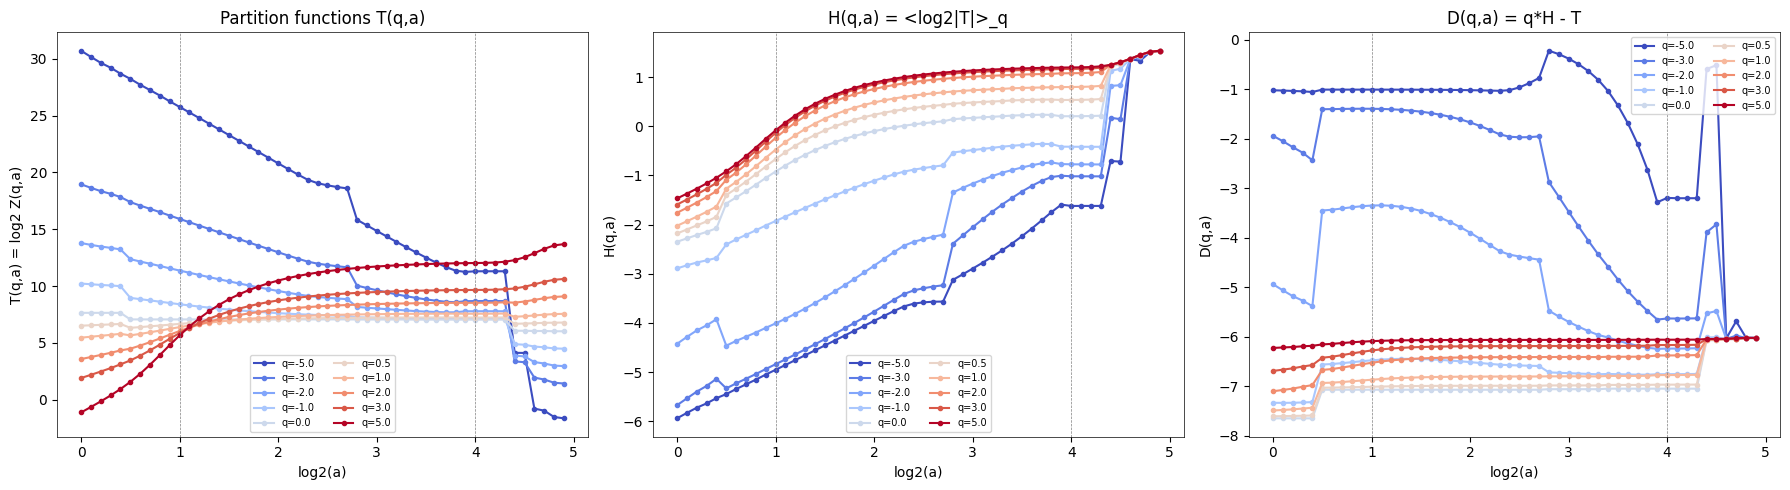

Gray dashed lines show regression range [log2(a)=1 to 4]
Inspect these for linear scaling — adjust range if needed before next cell.


In [ ]:
# Cell 26: Partition functions on creepmeter data — T(q,a), H(q,a), D(q,a) vs log2(a)

q_list_c = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

t0 = time.time()
pf_c = compute_partition_function(eo_c, n_oct=n_oct_c, n_voice=n_voice_c,
                                  a_min=1.0, q_list=q_list_c)
t1 = time.time()
print(f'Partition function computed in {t1-t0:.3f}s, up to scale index {pf_c["index_max"]}')

# Plot T(q,a), H(q,a), D(q,a)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)
log2_ac = pf_c['log2_a']
valid_c = slice(0, pf_c['index_max'] + 1)
colors_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_c)))

ax = axes[0]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_T(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) = log2 Z(q,a)')
ax.set_title('Partition functions T(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[1]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_H(pf_c, i)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a)')
ax.set_title('H(q,a) = <log2|T|>_q')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

ax = axes[2]
for i, q in enumerate(pf_c['q_list']):
    y = pf_get_D(pf_c, i, q)[valid_c]
    ax.plot(log2_ac[valid_c], y, 'o-', color=colors_c[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a)')
ax.set_title('D(q,a) = q*H - T')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()
print('Gray dashed lines show regression range [log2(a)=1 to 4]')
print('Inspect these for linear scaling — adjust range if needed before next cell.')

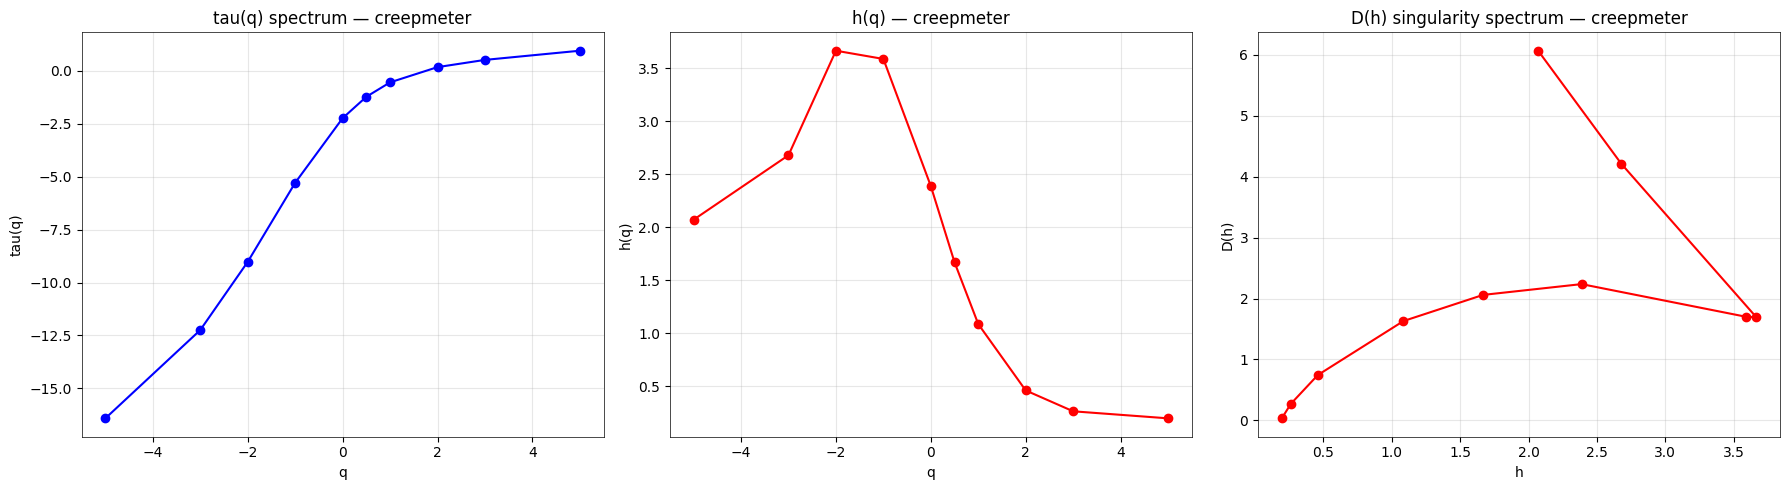


Creepmeter WTMM multifractal analysis:
q	 tau(q)		 h(q)		 D(q)
 -5.0	 -16.4158	   2.0703	   6.0644
 -3.0	 -12.2443	   2.6785	   4.2088
 -2.0	  -9.0226	   3.6644	   1.6939
 -1.0	  -5.2885	   3.5867	   1.7018
  0.0	  -2.2361	   2.3877	   2.2361
  0.5	  -1.2251	   1.6685	   2.0594
  1.0	  -0.5442	   1.0859	   1.6301
  2.0	   0.1760	   0.4602	   0.7445
  3.0	   0.5175	   0.2635	   0.2730
  5.0	   0.9511	   0.1971	   0.0346


In [ ]:
# Cell 27: tau(q), h(q), D(h) spectra for creepmeter data
# Adjust log2_a_min and log2_a_max based on visual inspection of Cell 14

spectra_c = compute_spectra(pf_c, log2_a_min=4.0, log2_a_max=4.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

ax = axes[0]
ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'ro-', markersize=6)
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) — creepmeter')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'ro-', markersize=6)
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum — creepmeter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nCreepmeter WTMM multifractal analysis:')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_c['q_list']):
    print(f'{q:5.1f}\t {spectra_c["tau_q"][i]:8.4f}\t {spectra_c["h_q"][i]:8.4f}\t {spectra_c["D_q"][i]:8.4f}')

In [ ]:
# Cell 28: Decimate creepmeter to hourly — 6 phase-shifted sub-signals
#
# 10-min sampling → every 6th sample = 1-hour sampling.
# Offsets 0..5 give 6 independent hourly series (like 6 "realizations").
# This is analogous to DemoWTMM1DDevilStair's 50 random realizations,
# except our "realizations" are phase offsets of the same physical process.

DECIM = 6  # decimation factor (10min × 6 = 60min = 1 hour)

# Build 6 hourly sub-signals
hourly_signals = []
for offset in range(DECIM):
    sub = segment_c[offset::DECIM].copy()
    hourly_signals.append(sub)
    
min_len = min(len(s) for s in hourly_signals)
print(f'Original signal: {len(segment_c)} samples at 10-min')
print(f'Decimated: {DECIM} sub-signals of {min_len} samples at 1-hour')
print(f'  (duration: {min_len / 24:.1f} days = {min_len / 24 / 365.25:.2f} years)')

# Plot all 6 overlaid
fig, ax = plt.subplots(figsize=(14, 4))
for spine in ax.spines.values(): spine.set_linewidth(0.5)
for offset in range(DECIM):
    t_hr = np.arange(len(hourly_signals[offset])) / 24  # days
    ax.plot(t_hr, hourly_signals[offset], alpha=0.6, linewidth=0.5,
            label=f'offset {offset}')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (mm)')
ax.set_title(f'6 hourly sub-signals (decimation factor {DECIM})')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: PF accumulation — imported from wtmm package

from wtmm.partition import pf_standard_addition, pf_copy

print('pf_standard_addition() and pf_copy() imported from wtmm.partition.')

In [ ]:
# Cell 29: Full WTMM pipeline on each hourly sub-signal, accumulate with pf add
#
# Mirrors DemoWTMM1DDevilStair loop:
#   foreach i 0:nrepeat-1 {
#       cwtd w amin omax nv wavelet -b 'mir'
#       extrema w
#       chainmax w.extrep 1
#       if (i == 0) { pft = [pf wtmm w.extrep qlist] }
#       else { pft = [pf add pft [pf wtmm w.extrep qlist]] }
#   }

# Parameters — match the single-signal creepmeter analysis
n_oct_h = n_oct_c      # same octave count
n_voice_h = n_voice_c  # same voices per octave
a_min_h = 1.0
wavelet_h = 'g2'
expo_h = -1.0
q_list_h = [-5, -3, -2, -1, 0, 0.5, 1, 2, 3, 5]

pf_accumulated = None
t_total = time.time()

for offset in range(DECIM):
    sig = hourly_signals[offset][:min_len]  # trim to same length
    t0 = time.time()
    
    # 1. CWT
    coeffs_h, scales_h, vr_h = cwtd_batched(sig, a_min=a_min_h, n_oct=n_oct_h,
                                              n_voice=n_voice_h, wavelet_name=wavelet_h,
                                              expo=expo_h)
    
    # 2. Extrema
    ea_h, eo_h, ei_h = compute_extrep(coeffs_h, scales_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                       a_min=a_min_h, valid_ranges=vr_h,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain + delete + chainmax
    cl_h, fl_h = chain_all(ea_h, eo_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_delete_all(ea_h, eo_h, ei_h, cl_h, fl_h, n_oct=n_oct_h, n_voice=n_voice_h)
    chain_max_wrapper(eo_h, cl_h, n_oct=n_oct_h, n_voice=n_voice_h, a_min=a_min_h, expo=1.0)
    
    # 4. Partition function
    pf_h = compute_partition_function(eo_h, n_oct=n_oct_h, n_voice=n_voice_h,
                                      a_min=a_min_h, q_list=q_list_h)
    
    # 5. Accumulate
    if pf_accumulated is None:
        pf_accumulated = pf_copy(pf_h)
    else:
        pf_standard_addition(pf_accumulated, pf_h)
    
    n_ext_h = sum(len(a) for a in ea_h)
    t1 = time.time()
    print(f'  Offset {offset}: {len(sig)} samples, {n_ext_h} extrema after pruning, '
          f'index_max={pf_h["index_max"]}, {t1-t0:.2f}s')

print(f'\nTotal: {time.time() - t_total:.2f}s')
print(f'Accumulated {pf_accumulated["signal_number"]} realizations')
print(f'Combined index_max: {pf_accumulated["index_max"]}')

In [ ]:
# Cell 30: Intensive-mode partition functions — T, H, D vs log2(a)
#
# Intensive mode divides logSTq and sTqLogT_sTq by signalNumber,
# giving the *average* across realizations. This reduces noise in
# the scaling plots and gives more reliable regression slopes.

log2_ah = pf_accumulated['log2_a']
valid_h = slice(0, pf_accumulated['index_max'] + 1)
q_arr = pf_accumulated['q_list']
colors_h = plt.cm.coolwarm(np.linspace(0, 1, len(q_arr)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# T(q,a) — intensive
ax = axes[0]
for i, q in enumerate(q_arr):
    y = pf_get_T(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('T(q,a) intensive')
ax.set_title(f'Intensive T(q,a) — {pf_accumulated["signal_number"]} hourly sub-signals')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# H(q,a) — intensive
ax = axes[1]
for i, q in enumerate(q_arr):
    y = pf_get_H(pf_accumulated, i, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('H(q,a) intensive')
ax.set_title('Intensive H(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

# D(q,a) — intensive
ax = axes[2]
for i, q in enumerate(q_arr):
    y = pf_get_D(pf_accumulated, i, q, mode='intensive')[valid_h]
    ax.plot(log2_ah[valid_h], y, 'o-', color=colors_h[i], markersize=3, label=f'q={q}')
ax.set_xlabel('log2(a)')
ax.set_ylabel('D(q,a) intensive')
ax.set_title('Intensive D(q,a)')
ax.legend(fontsize=7, ncol=2)
ax.axvline(1.0, color='gray', ls='--', lw=0.5)
ax.axvline(4.0, color='gray', ls='--', lw=0.5)

plt.suptitle(f'Hourly decimated creepmeter — intensive mode ({DECIM} realizations)', y=1.02)
plt.tight_layout()
plt.show()
print('Gray dashed lines show default regression range [log2(a)=1 to 4]. Adjust below if needed.')

In [ ]:
# Cell 31: tau(q), h(q), D(h) spectra — intensive mode, compared to single-signal extensive
#
# The intensive mode should give smoother, more reliable spectra because it
# averages the log-partition functions across 6 realizations before regression.

spectra_h = compute_spectra(pf_accumulated, log2_a_min=1.0, log2_a_max=4.0, mode='intensive')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in (axes.flatten() if hasattr(axes, 'flatten') else [axes]):
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# tau(q)
ax = axes[0]
ax.plot(spectra_h['q_list'], spectra_h['tau_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['tau_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('tau(q)')
ax.set_title('tau(q) spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
ax.plot(spectra_h['q_list'], spectra_h['h_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['q_list'], spectra_c['h_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q)')
ax.legend()
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
ax.plot(spectra_h['h_q'], spectra_h['D_q'], 'rs-', markersize=6,
        label=f'Intensive ({DECIM} hourly)')
if 'spectra_c' in dir():
    ax.plot(spectra_c['h_q'], spectra_c['D_q'], 'bo--', markersize=5, alpha=0.5,
            label='Extensive (single 10-min)')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Intensive (hourly decimated) vs Extensive (single signal)', y=1.02)
plt.tight_layout()
plt.show()

# Print table
print(f'\nIntensive WTMM ({DECIM} hourly sub-signals):')
print('q\t tau(q)\t\t h(q)\t\t D(q)')
for i, q in enumerate(spectra_h['q_list']):
    print(f'{q:5.1f}\t {spectra_h["tau_q"][i]:8.4f}\t {spectra_h["h_q"][i]:8.4f}\t {spectra_h["D_q"][i]:8.4f}')

In [7]:
import h5py                                                                                                            
                                                                                                                                                                                
h5_path = '/Volumes/AbeMBeats/new_data_asif/timeseries.h5'                                                                                                                                        
with h5py.File(h5_path, 'r') as f:                                                                                                                                             
    f.visititems(lambda name, obj: print(f"{name}: {type(obj).__name__} {obj.shape if hasattr(obj, 'shape') else ''}"))                    

bperp: Dataset (27,)
date: Dataset (27,)
timeseries: Dataset (27, 3029, 4855)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

cum shape: (27, 3029, 4855), dates: 27 from 2017-02-14 to 2017-12-23
Days span: 312 days (0.85 years)
Uniform grid: 27 points, dt=12.0 days
Pixel A (y=1031, x=362): range [-0.1, 0.0] mm, std=0.0 mm
Pixel B (y=100, x=1043): range [-0.0, -0.0] mm, std=0.0 mm


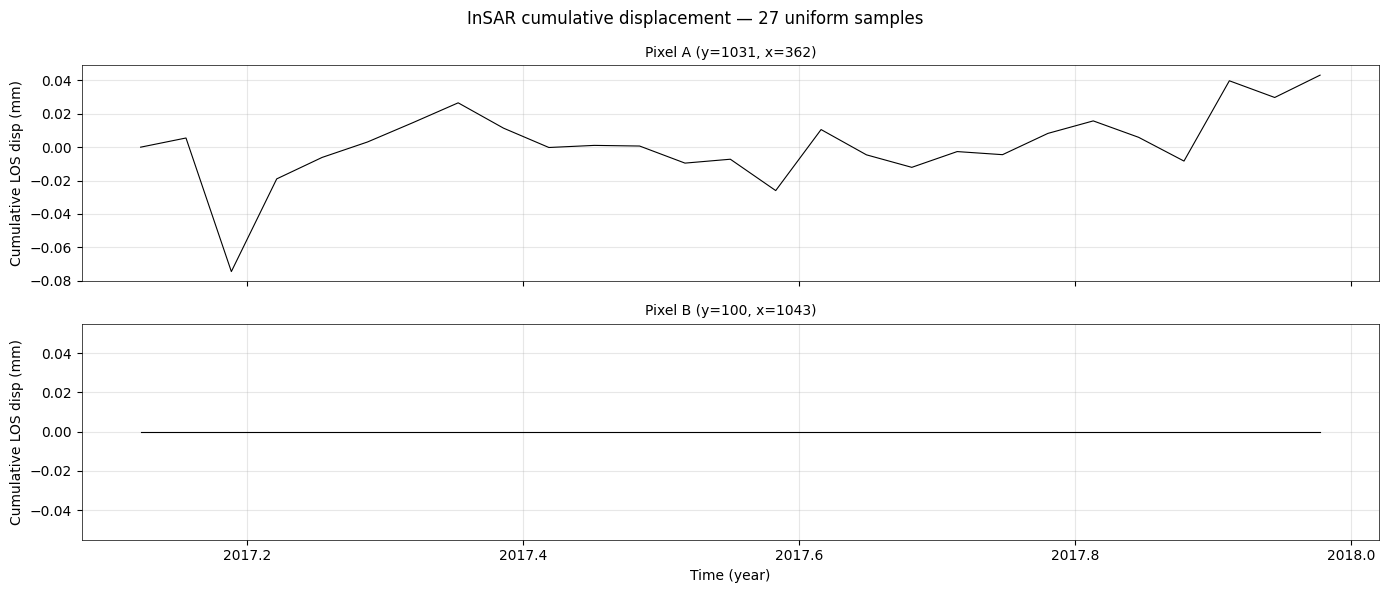


Signal length: 27 points each
  pixA: range [-0.074, 0.043], std=0.022
  pixB: range [-0.000, -0.000], std=0.000


In [15]:
# Cell 43: Load InSAR cumulative displacement time series
#
# Pixel A: y=1031, x=362, vel=-109.29 mm/yr (fast-moving)
# Pixel B: y=224, x=291, vel~0 mm/yr (slow/reference)
#
# No detrending — g2 wavelet has 2 vanishing moments, already kills
# constant and linear components. The trend is part of the signal.
#
# InSAR dates are irregular (~12-day revisit with gaps), so we interpolate
# to a uniform grid before CWT (which assumes uniform sampling).

import h5py
from datetime import datetime

# --- Load data ---
h5_path = '/Volumes/AbeMBeats/new_data_asif/timeseries.h5'
with h5py.File(h5_path, 'r') as f:
    cum_data = f['timeseries'][:]          # shape (197, 1052, 475)
    dates_bytes = f['date'][:]   # YYYYMMDD integers or strings

dates = [datetime.strptime(str(int(d)), '%Y%m%d') for d in dates_bytes]
days = np.array([(d - dates[0]).days for d in dates], dtype=float)

print(f'cum shape: {cum_data.shape}, dates: {len(dates)} from {dates[0].date()} to {dates[-1].date()}')
print(f'Days span: {days[-1]:.0f} days ({days[-1]/365.25:.2f} years)')

# --- Extract pixel time series ---
pixels = {
    'Pixel A (y=1031, x=362)': cum_data[:, 500, 362],
    'Pixel B (y=100, x=1043)':  cum_data[:, 224, 291],
}

# --- Interpolate to uniform grid ---
dt_uniform = np.median(np.diff(days))  # ~12 days
t_uniform = np.arange(days[0], days[-1] + dt_uniform/2, dt_uniform)
print(f'Uniform grid: {len(t_uniform)} points, dt={dt_uniform:.1f} days')

# --- Resample to uniform grid ---
insar_signals = {}
insar_labels = {}
for name, raw in pixels.items():
    # Handle NaN/masked values
    mask = np.isfinite(raw)
    if not np.all(mask):
        raw_clean = np.interp(days, days[mask], raw[mask])
    else:
        raw_clean = raw.copy()
    
    # Interpolate to uniform grid
    cum_uniform = np.interp(t_uniform, days, raw_clean)
    
    short = 'pixA' if '1031' in name else 'pixB'
    insar_signals[short] = cum_uniform
    insar_labels[short] = name
    
    print(f'{name}: range [{cum_uniform.min():.1f}, {cum_uniform.max():.1f}] mm, '
          f'std={cum_uniform.std():.1f} mm')

# --- Plot both signals ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

t_years = t_uniform / 365.25 + 2017.0 + (dates[0].timetuple().tm_yday / 365.25)

for i, (key, ax) in enumerate(zip(['pixA', 'pixB'], axes)):
    ax.plot(t_years, insar_signals[key], 'k-', linewidth=0.8)
    ax.set_title(insar_labels[key], fontsize=10)
    ax.set_ylabel('Cumulative LOS disp (mm)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (year)')
plt.suptitle(f'InSAR cumulative displacement — {len(t_uniform)} uniform samples', fontsize=12)
plt.tight_layout()
plt.show()

signal_keys = ['pixA', 'pixB']
print(f'\nSignal length: {len(t_uniform)} points each')
for key in signal_keys:
    s = insar_signals[key]
    print(f'  {key}: range [{s.min():.3f}, {s.max():.3f}], std={s.std():.3f}')

In [16]:
# Cell 44: Run 1D WTMM pipeline on both InSAR signals
#
# Parameters: n_oct=3, n_voice=10, wavelet='g2', a_min=1.0, expo=-1.0
# 3 octaves → 30 scales, max scale ~8× minimum, safe for ~200 points
#
# Pipeline: cwtd → compute_extrep → chain_all → chain_delete_all
#           → chain_max_wrapper → compute_partition_function

import time as time_mod

n_oct_i = 3
n_voice_i = 2
a_min_i = 1.0
wavelet_i = 'g2'
expo_i = -1.0
q_list_i = [-1, 0, 1, 2]

insar_results = {}

for key in signal_keys:
    sig = insar_signals[key].astype(np.float64)
    t0 = time_mod.time()
    
    # 1. CWT (mirror boundary for short signal)
    coeffs_i, scales_i, vr_i = cwtd(sig, a_min=a_min_i, n_oct=n_oct_i,
                                      n_voice=n_voice_i, wavelet_name=wavelet_i,
                                      expo=expo_i, border='mirror')
    
    # 2. Extrema detection
    ea_i, eo_i, ei_i = compute_extrep(coeffs_i, scales_i, n_oct=n_oct_i, n_voice=n_voice_i,
                                       a_min=a_min_i, valid_ranges=vr_i,
                                       dx=1.0, x0=0.0, epsilon=1e-6)
    
    # 3. Chain linking
    cl_i, fl_i = chain_all(ea_i, eo_i, n_oct=n_oct_i, n_voice=n_voice_i)
    
    # 4. Prune short chains
    nb_del = chain_delete_all(ea_i, eo_i, ei_i, cl_i, fl_i,
                               n_oct=n_oct_i, n_voice=n_voice_i)
    
    # 5. Monotonize chain maxima
    chain_max_wrapper(eo_i, cl_i, n_oct=n_oct_i, n_voice=n_voice_i,
                       a_min=a_min_i, expo=1.0)
    
    # 6. Partition function
    pf_i = compute_partition_function(eo_i, n_oct=n_oct_i, n_voice=n_voice_i,
                                       a_min=a_min_i, q_list=q_list_i)
    
    # 7. Trace chains for visualization
    n_scales_i = n_oct_i * n_voice_i
    chains_i = trace_chains(ea_i, eo_i, cl_i, scales_i, n_scales_i)
    
    t1 = time_mod.time()
    n_ext = sum(len(a) for a in ea_i)
    print(f'{key} ({insar_labels[key]}): {len(sig)} pts, {n_ext} extrema, '
          f'{nb_del} deleted, {len(chains_i)} chains, {t1-t0:.3f}s')
    
    insar_results[key] = {
        'coeffs': coeffs_i, 'scales': scales_i, 'valid_ranges': vr_i,
        'ea': ea_i, 'eo': eo_i, 'ei': ei_i,
        'cl': cl_i, 'fl': fl_i,
        'pf': pf_i, 'chains': chains_i,
    }

# --- Scalograms with WTMM chains overlaid ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for idx, (key, ax) in enumerate(zip(signal_keys, axes)):
    r = insar_results[key]
    scalogram_lastwave(r['coeffs'], scales=r['scales'], ax=ax, norm_mode='lglobal')
    for positions, log2scales, sign in r['chains']:
        color = 'w' if sign > 0 else 'cyan'
        ax.plot(positions, log2scales, color=color, linewidth=0.3, alpha=0.7)
    ax.set_title(insar_labels[key], fontsize=10)
    ax.set_xlabel('Sample')

plt.suptitle(f'Scalograms + WTMM chains (n_oct={n_oct_i}, n_voice={n_voice_i}, {wavelet_i})',
             fontsize=12)
plt.tight_layout()
plt.show()

# --- Side profile: log2|coeff| vs log2(scale) for each maxima line ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for idx, (key, ax) in enumerate(zip(signal_keys, axes)):
    r = insar_results[key]
    ea, eo, cl = r['ea'], r['eo'], r['cl']
    n_sc = n_oct_i * n_voice_i

    # Trace chains with ordinate values
    for fi in range(len(ea[0])):
        log2_a_chain = []
        log2_mod_chain = []
        cs, ci = 0, fi
        while cs < n_sc and ci != -1:
            val = abs(eo[cs][ci])
            if val > 0:
                log2_a_chain.append(np.log2(r['scales'][cs]))
                log2_mod_chain.append(np.log2(val))
            ci = cl[cs][ci]
            cs += 1
        if len(log2_a_chain) > 1:
            ax.plot(log2_a_chain, log2_mod_chain, 'k-', linewidth=0.3, alpha=0.4)

    ax.set_xlabel('log2(scale)')
    ax.set_ylabel('log2|CWT coeff|')
    ax.set_title(insar_labels[key], fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Maxima line profiles: log2|coeff| vs log2(scale)', fontsize=12)
plt.tight_layout()
plt.show()

# --- Partition functions: T(q,a), H(q,a), D(q,a) vs log2(a) for each pixel ---
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_list_i)))

for key in signal_keys:
    pf = insar_results[key]['pf']
    log2_a = pf['log2_a']
    valid = slice(0, pf['index_max'] + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax_ in axes:
        for spine in ax_.spines.values(): spine.set_linewidth(0.5)

    ax = axes[0]
    for i, q in enumerate(pf['q_list']):
        ax.plot(log2_a[valid], pf_get_T(pf, i)[valid], 'o-',
                color=colors_q[i], markersize=3, label=f'q={q}')
    ax.set_xlabel('log2(a)')
    ax.set_ylabel('T(q,a) = log2 Z(q,a)')
    ax.set_title('T(q,a)')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for i, q in enumerate(pf['q_list']):
        ax.plot(log2_a[valid], pf_get_H(pf, i)[valid], 'o-',
                color=colors_q[i], markersize=3, label=f'q={q}')
    ax.set_xlabel('log2(a)')
    ax.set_ylabel('H(q,a)')
    ax.set_title('H(q,a)')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    for i, q in enumerate(pf['q_list']):
        ax.plot(log2_a[valid], pf_get_D(pf, i, q)[valid], 'o-',
                color=colors_q[i], markersize=3, label=f'q={q}')
    ax.set_xlabel('log2(a)')
    ax.set_ylabel('D(q,a)')
    ax.set_title('D(q,a)')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'{insar_labels[key]} — partition functions', fontsize=12)
    plt.tight_layout()
    plt.show()

NameError: name 'cwtd' is not defined

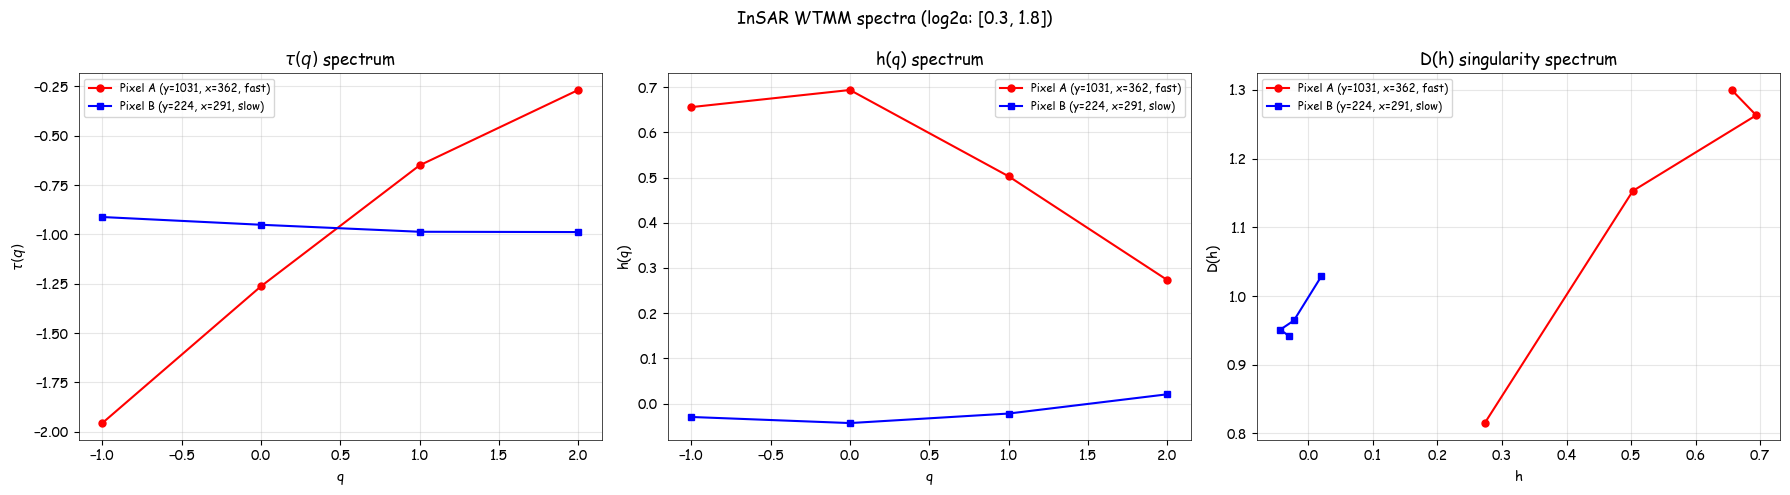


Signal                                    Δh   h(q=0)   h(q=2)
-----------------------------------------------------------------
Pixel A (y=1031, x=362)                0.420    0.694    0.273
Pixel B (y=224, x=291)                 0.064   -0.043    0.020

Δh: multifractal width — larger = more complex deformation
h(q=2): dominant Hölder exponent — smaller = rougher signal
Curved τ(q) → multifractal; linear → monofractal


In [57]:
# Cell 45: Compare D(h) spectra — Pixel A vs Pixel B
#
# Expected:
#   Fast-moving pixel: singularities from slip/deformation events
#   Slow pixel: smoother, narrower D(h), larger h
#   Multifractal width Δh → complexity of deformation process

log2_a_min_i = 0.26
log2_a_max_i = 1.8#np.log2(a_min_i) + (n_oct_i * n_voice_i - 1) / n_voice_i - 0.5

insar_spectra = {}
for key in signal_keys:
    insar_spectra[key] = compute_spectra(insar_results[key]['pf'],
                                          log2_a_min=log2_a_min_i,
                                          log2_a_max=log2_a_max_i)

styles = {
    'pixA': {'color': 'red',  'marker': 'o', 'label': 'Pixel A (y=1031, x=362, fast)'},
    'pixB': {'color': 'blue', 'marker': 's', 'label': 'Pixel B (y=224, x=291, slow)'},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

# tau(q)
ax = axes[0]
for key in signal_keys:
    sp = insar_spectra[key]
    st = styles[key]
    ax.plot(sp['q_list'], sp['tau_q'], color=st['color'],
            marker=st['marker'], markersize=5, label=st['label'])
ax.set_xlabel('q')
ax.set_ylabel(r'$\tau(q)$')
ax.set_title(r'$\tau(q)$ spectrum')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# h(q)
ax = axes[1]
for key in signal_keys:
    sp = insar_spectra[key]
    st = styles[key]
    ax.plot(sp['q_list'], sp['h_q'], color=st['color'],
            marker=st['marker'], markersize=5, label=st['label'])
ax.set_xlabel('q')
ax.set_ylabel('h(q)')
ax.set_title('h(q) spectrum')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# D(h)
ax = axes[2]
for key in signal_keys:
    sp = insar_spectra[key]
    st = styles[key]
    valid = np.isfinite(sp['h_q']) & np.isfinite(sp['D_q'])
    if np.any(valid):
        ax.plot(sp['h_q'][valid], sp['D_q'][valid], color=st['color'],
                marker=st['marker'], markersize=5, label=st['label'])
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) singularity spectrum')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(f'InSAR WTMM spectra (log2a: [{log2_a_min_i:.1f}, {log2_a_max_i:.1f}])',
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print('\n' + '='*65)
print(f'{"Signal":<35} {"Δh":>8} {"h(q=0)":>8} {"h(q=2)":>8}')
print('-'*65)
for key in signal_keys:
    sp = insar_spectra[key]
    valid = np.isfinite(sp['h_q']) & np.isfinite(sp['D_q'])
    if np.any(valid):
        delta_h = sp['h_q'][valid].max() - sp['h_q'][valid].min()
        iq0 = np.argmin(np.abs(sp['q_list'] - 0))
        iq2 = np.argmin(np.abs(sp['q_list'] - 2))
        print(f'{insar_labels[key]:<35} {delta_h:>8.3f} {sp["h_q"][iq0]:>8.3f} {sp["h_q"][iq2]:>8.3f}')
print('='*65)
print('\nΔh: multifractal width — larger = more complex deformation')
print('h(q=2): dominant Hölder exponent — smaller = rougher signal')
print('Curved τ(q) → multifractal; linear → monofractal')

Scale grid: 6 scales, log2(a) in [0.00, 2.50], step=0.50
Valid regression ranges (log2_a_min >= 1.0, >= 3 pts): 3
  pixA: 3 successful fits
  pixB: 3 successful fits


/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_88732/903013533.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


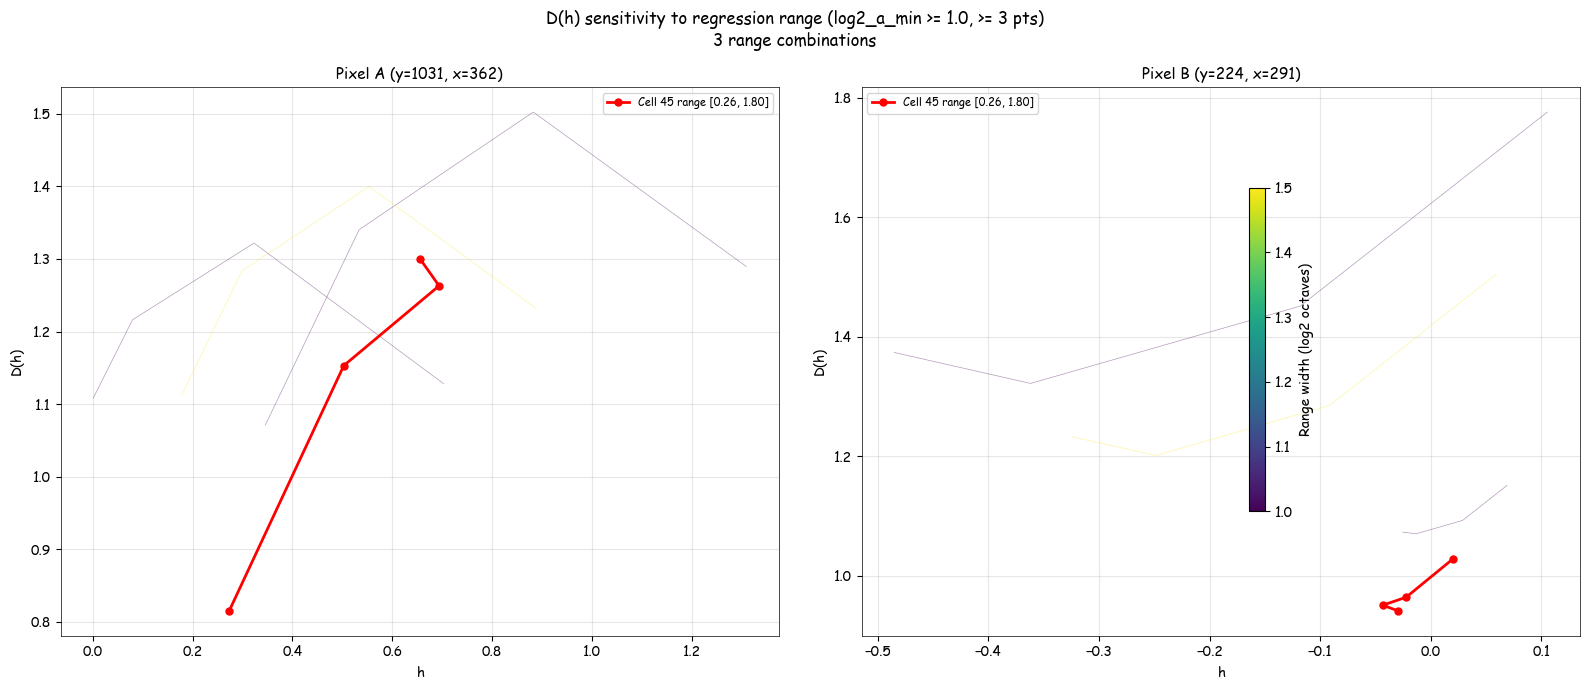

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_88732/903013533.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


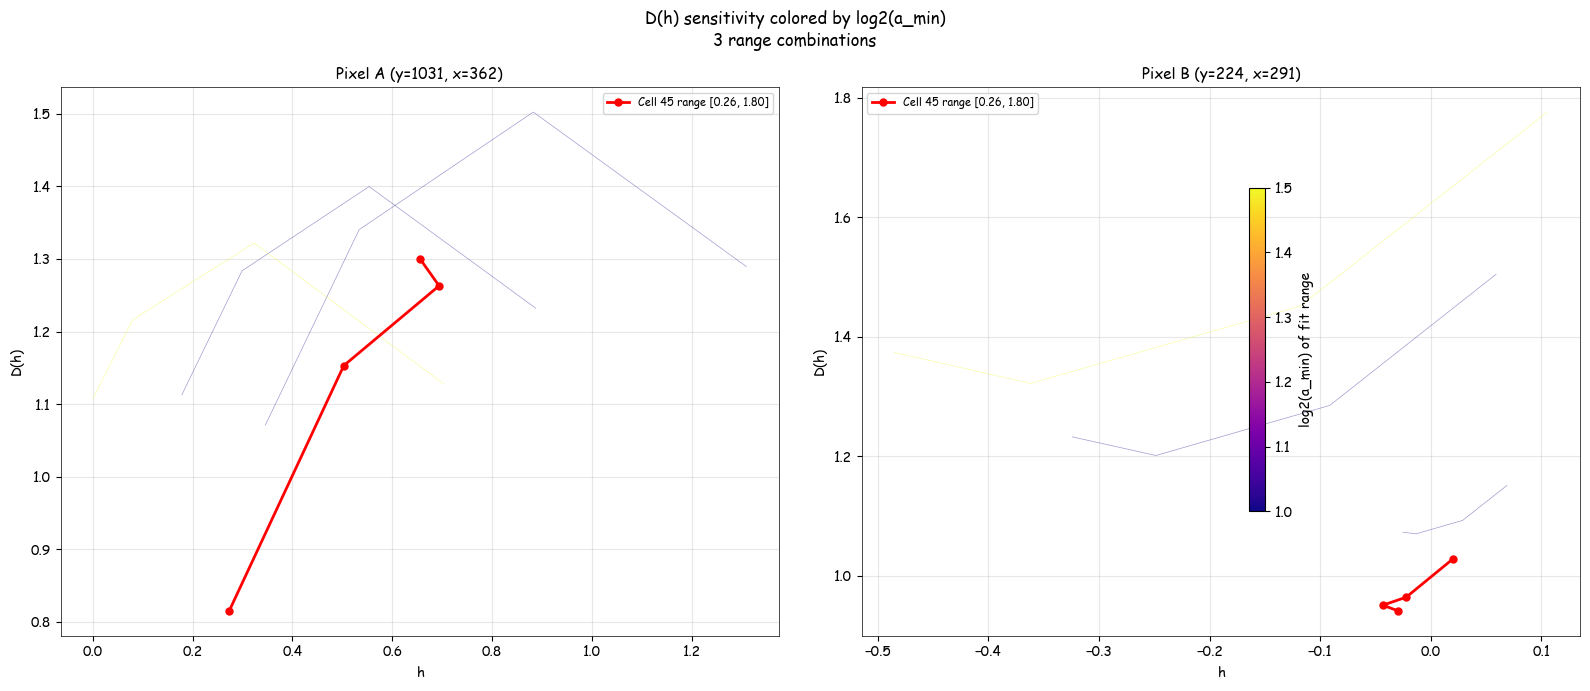


Signal                                 h(q=2) range        dh range   N fits
----------------------------------------------------------------------
Pixel A (y=1031, x=362)             [0.001, 0.346]  [0.702, 0.964]       3
Pixel B (y=224, x=291)              [0.059, 0.105]  [0.094, 0.591]       3

Tight ranges -> robust spectrum; wide spread -> sensitive to fit window


In [58]:
# Cell 46: Sensitivity of D(h) to regression range
#
# For each pixel, compute D(h) for ALL valid (log2_a_min, log2_a_max) pairs
# where log2_a_min >= 1.0 and at least 3 scale points in range.
# Overlay all D(h) curves to assess robustness of the singularity spectrum.

import itertools

# Build scale grid from cell 44 parameters
step_i = 1.0 / n_voice_i
n_scales_i = n_oct_i * n_voice_i
log2_a_grid = np.array([np.log2(a_min_i) + j / n_voice_i for j in range(n_scales_i)])

# Enumerate all valid (min, max) pairs
min_points = 3
log2_a_min_threshold = 1.0
valid_mins = log2_a_grid[log2_a_grid >= log2_a_min_threshold - 1e-9]

range_pairs = []
for lo in valid_mins:
    for hi in log2_a_grid:
        if hi >= lo + (min_points - 1) * step_i - 1e-9:
            n_in = np.sum((log2_a_grid >= lo - 1e-9) & (log2_a_grid <= hi + 1e-9))
            if n_in >= min_points:
                range_pairs.append((lo, hi))

print(f'Scale grid: {n_scales_i} scales, log2(a) in [{log2_a_grid[0]:.2f}, {log2_a_grid[-1]:.2f}], step={step_i:.2f}')
print(f'Valid regression ranges (log2_a_min >= {log2_a_min_threshold}, >= {min_points} pts): {len(range_pairs)}')

# Compute D(h) for every range, for each pixel
all_spectra = {}
for key in signal_keys:
    pf_k = insar_results[key]['pf']
    spectra_list = []
    for lo, hi in range_pairs:
        try:
            sp = compute_spectra(pf_k, log2_a_min=lo, log2_a_max=hi)
            width = hi - lo
            spectra_list.append({'lo': lo, 'hi': hi, 'width': width, **sp})
        except (ValueError, np.linalg.LinAlgError):
            pass
    all_spectra[key] = spectra_list
    print(f'  {key}: {len(spectra_list)} successful fits')

# --- Plot: overlay all D(h) curves, colored by range width ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for idx, (key, ax) in enumerate(zip(signal_keys, axes)):
    specs = all_spectra[key]
    if not specs:
        ax.set_title(f'{insar_labels[key]} — no valid fits')
        continue

    widths = np.array([s['width'] for s in specs])
    w_min, w_max = widths.min(), widths.max()

    for s in specs:
        valid = np.isfinite(s['h_q']) & np.isfinite(s['D_q'])
        if not np.any(valid):
            continue
        # Color by range width: narrow=yellow, wide=dark blue
        t = (s['width'] - w_min) / (w_max - w_min + 1e-12)
        color = plt.cm.viridis(t)
        ax.plot(s['h_q'][valid], s['D_q'][valid], '-', color=color,
                linewidth=0.5, alpha=0.4)

    # Overlay the "reference" from cell 45
    sp_ref = insar_spectra[key]
    v_ref = np.isfinite(sp_ref['h_q']) & np.isfinite(sp_ref['D_q'])
    if np.any(v_ref):
        ax.plot(sp_ref['h_q'][v_ref], sp_ref['D_q'][v_ref], 'r-o',
                linewidth=2, markersize=5, label=f'Cell 45 range [{log2_a_min_i:.2f}, {log2_a_max_i:.2f}]',
                zorder=10)

    ax.set_xlabel('h')
    ax.set_ylabel('D(h)')
    ax.set_title(insar_labels[key], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=w_min, vmax=w_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('Range width (log2 octaves)', fontsize=10)

plt.suptitle(f'D(h) sensitivity to regression range (log2_a_min >= {log2_a_min_threshold}, >= {min_points} pts)\n'
             f'{len(range_pairs)} range combinations', fontsize=12)
plt.tight_layout()
plt.show()

# --- Also color by log2_a_min ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_ in axes:
    for spine in ax_.spines.values(): spine.set_linewidth(0.5)

for idx, (key, ax) in enumerate(zip(signal_keys, axes)):
    specs = all_spectra[key]
    if not specs:
        ax.set_title(f'{insar_labels[key]} — no valid fits')
        continue

    los = np.array([s['lo'] for s in specs])
    lo_min, lo_max = los.min(), los.max()

    for s in specs:
        valid = np.isfinite(s['h_q']) & np.isfinite(s['D_q'])
        if not np.any(valid):
            continue
        t = (s['lo'] - lo_min) / (lo_max - lo_min + 1e-12)
        color = plt.cm.plasma(t)
        ax.plot(s['h_q'][valid], s['D_q'][valid], '-', color=color,
                linewidth=0.5, alpha=0.4)

    sp_ref = insar_spectra[key]
    v_ref = np.isfinite(sp_ref['h_q']) & np.isfinite(sp_ref['D_q'])
    if np.any(v_ref):
        ax.plot(sp_ref['h_q'][v_ref], sp_ref['D_q'][v_ref], 'r-o',
                linewidth=2, markersize=5, label=f'Cell 45 range [{log2_a_min_i:.2f}, {log2_a_max_i:.2f}]',
                zorder=10)

    ax.set_xlabel('h')
    ax.set_ylabel('D(h)')
    ax.set_title(insar_labels[key], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

sm2 = plt.cm.ScalarMappable(cmap='plasma',
                             norm=plt.Normalize(vmin=lo_min, vmax=lo_max))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=axes, shrink=0.6, pad=0.02)
cbar2.set_label('log2(a_min) of fit range', fontsize=10)

plt.suptitle(f'D(h) sensitivity colored by log2(a_min)\n'
             f'{len(range_pairs)} range combinations', fontsize=12)
plt.tight_layout()
plt.show()

# --- Summary statistics: spread of h(q=2) and delta_h across all ranges ---
print('\n' + '='*70)
print(f'{"Signal":<35} {"h(q=2) range":>15} {"dh range":>15} {"N fits":>8}')
print('-'*70)
for key in signal_keys:
    specs = all_spectra[key]
    h_q2_vals = []
    delta_h_vals = []
    for s in specs:
        v = np.isfinite(s['h_q']) & np.isfinite(s['D_q'])
        if np.any(v):
            iq2 = np.argmin(np.abs(s['q_list'] - 2))
            if np.isfinite(s['h_q'][iq2]):
                h_q2_vals.append(s['h_q'][iq2])
            delta_h_vals.append(s['h_q'][v].max() - s['h_q'][v].min())
    if h_q2_vals:
        h_q2 = np.array(h_q2_vals)
        dh = np.array(delta_h_vals)
        print(f'{insar_labels[key]:<35} [{h_q2.min():.3f}, {h_q2.max():.3f}]'
              f'  [{dh.min():.3f}, {dh.max():.3f}]  {len(specs):>6}')
print('='*70)
print('\nTight ranges -> robust spectrum; wide spread -> sensitive to fit window')
